In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# !pip install pennylane torch torch-geometric gensim pytdc deepchem quimb pennylane-catalyst

In [3]:
# !pip install pennylane-lightning-kokkos
# !pip install git+https://github.com/PennyLaneAI/pennylane.git@master
# !pip install easydict
# !pip install tensorflow

In [4]:
# !pip uninstall deepchem -y
# !pip install --pre deepchem
# !pip install --pre deepchem[tensorflow]
# !pip install --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

In [5]:
# # 1. Remove everything related to JAX
# !pip uninstall jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt -y

# # 2. Clear the pip cache (CRITICAL: this prevents pip from reusing the CPU wheel)
# !pip cache purge

# # 3. Install JAX and the EXPLICIT CUDA 12 plugin
# !pip install -U jax jaxlib
# !pip install jax-cuda12-plugin

In [6]:
# # !pip install --upgrade pip
# # !pip install --upgrade jax jaxlib==0.1.57+cuda129 -f https://storage.googleapis.com/jax-releases/jax_releases.html
# !pip install -U "jax[cuda12]"
# !pip install --upgrade "jax[cuda12-local]"

# !pip install "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --no-cache-dir

# !pip install -U "jax[cuda12]"

In [7]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Jan__6_16:45:21_PST_2023
Cuda compilation tools, release 12.0, V12.0.140
Build cuda_12.0.r12.0/compiler.32267302_0


In [8]:
import os
import itertools

In [9]:
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['TORCH_USE_CUDA_DSA'] = "1"

In [10]:
# import jax
# from jax.lib import xla_bridge
# print(xla_bridge.get_backend().platform) 
# # If this says 'cpu', run the next line to see why:
# jax.devices()

In [11]:
import jax
from jax import jit
import jax.numpy as jnp
import optax
from jax import vmap, jit, vjp
from jax.extend import backend  # New 2026 replacement for xla_bridge
from jax.dlpack import from_dlpack as d2j, to_dlpack as j2d

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.dlpack import from_dlpack as f2d, to_dlpack as t2d

import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml

import yaml
import easydict

import os
import sys

import logging
import random

import tdc

import logging
import pickle
import time
import easydict
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import yaml
from gensim.models import Word2Vec
from tdc.multi_pred import bi_pred_dataset

from torch_geometric.data import InMemoryDataset, Batch, Data
from torch_geometric.loader import DataLoader
from torch_geometric.data.in_memory_dataset import nested_iter

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import OneHotEncoder
from gensim.models import Word2Vec
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm
import os,logging,pickle,random,torch,gc,deepchem,gc

# from deepchem.models.graph_models import GraphConvModel
# # from deepchem.models import GraphConvModel

import deepchem.models
from deepchem.models.keras_model import KerasModel
deepchem.models.KerasModel = KerasModel
from deepchem.models.graph_models import GraphConvModel

from deepchem.feat import graph_features
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.feature_extraction.text import CountVectorizer

from itertools import repeat, product
from collections import Counter

import pennylane as qml

from sklearn import metrics as skmetrics

import tensorcircuit as tc

from jax.flatten_util import ravel_pytree

# from catalyst import qjit
# from jax import numpy as jnp

/tmp/ipykernel_3352731/4089768687.py:7: DeprecationWarning: jax.dlpack.to_dlpack was deprecated in JAX v0.6.0 and will be removed in JAX v0.7.0. Please use the newer DLPack API based on __dlpack__ and __dlpack_device__ instead. Typically, you can pass a JAX array directly to the `from_dlpack` function of another framework without using `to_dlpack`.
  from jax.dlpack import from_dlpack as d2j, to_dlpack as j2d
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading some PyTorch models, missing a dependency. No module named 'dgl'
No module named 'dgl'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'haiku'


In [12]:
import os
# This stops JAX from trying to grab 90% of your GPU memory. 
# Without this, JAX sees Torch using memory, thinks the GPU is full, and falls back to CPU.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

# Verify with the new 2026 JAX backend check
import jax
from jax.extend import backend
try:
    print(f"Active Backend: {backend.get_backend().platform}")
    print(f"Devices: {jax.devices()}")
except Exception as e:
    print(f"Error: {e}")

K = tc.set_backend("jax")
print("K:", K)

Active Backend: gpu
Devices: [CudaDevice(id=0)]
K: jax_backend


In [13]:
# import deepchem as dc
# print(dc.__version__)

In [14]:
def lgb_MaF(preds, dtrain):
    Y = np.array(dtrain.get_label(), dtype=np.int32)
    preds = preds.reshape(-1,len(Y))
    Y_pre = np.argmax( preds, axis=0 )
    return 'macro_f1', float(F1(preds.shape[0], Y_pre, Y, 'macro')), True

def lgb_precision(preds, dtrain):
    Y = dtrain.get_label()
    preds = preds.reshape(-1,len(Y))
    Y_pre = np.argmax( preds, axis=0 )
    return 'precision', float(Counter(Y==Y_pre)[True]/len(Y)), True

id2lab = [[-1,-1]]*20
for a in range(1,11):
    for s in [1,2]:
        id2lab[a-1+(s-1)*10] = [a,s]

def ACC(Y_pre, Y, threshold=0.5):
    # dist = np.mean(1.0 - np.abs(Y_pre), axis=-1)
    # predictions = (dist >= threshold).astype(float)
    # accuracy = np.mean(predictions == Y)
    
    # return accuracy
    return (Y_pre==Y).sum() / len(Y)

def AUC(Y_prob_pre, Y):
    return skmetrics.roc_auc_score(Y, Y_prob_pre)

def Precision(Y_pre, Y):
    return skmetrics.precision_score(Y, Y_pre)

def Recall(Y_pre, Y):
    return skmetrics.recall_score(Y, Y_pre)

def F1(Y_pre, Y):
    return skmetrics.f1_score(Y, Y_pre)

def LOSS(Y_prob_pre, Y, margin=0.8, out=None):
    # labels = Y.reshape(-1).astype(np.float32)
    # wire_distances = 1.0 - np.abs(Y_prob_pre)
    # dist = np.mean(wire_distances, axis=-1)
    # loss_bind = labels * np.power(dist, 2)
    # loss_no_bind = (1.0 - labels) * np.power(
    #     np.maximum(margin - dist, 0.0), 2
    # )

    # if out:
    #     addLoss = 0.0
    #     if 'loss' in out: addLoss += out['loss']
    #     if 'quantum_plus_loss' in out: addLoss += out['quantum_plus_loss']
    #     if 'quantum_minus_loss' in out: addLoss -= out['quantum_minus_loss']
        
    #     # 4. Total Loss
    #     total_loss = np.mean(loss_bind + loss_no_bind) + addLoss
    #     return total_loss
    
    # return np.mean(loss_bind + loss_no_bind)
    
    Y_prob_pre,Y = Y_prob_pre.reshape(-1),Y.reshape(-1)
    Y_prob_pre[Y_prob_pre>0.99] -= 1e-3
    Y_prob_pre[Y_prob_pre<0.01] += 1e-3
    return -np.mean(Y*np.log(Y_prob_pre) + (1-Y)*np.log(1-Y_prob_pre))

In [15]:
# def analyze_barren_plateau(model):
#     """
#     Mathematically evaluates if the circuit is in a Barren Plateau 
#     by checking gradient variance and magnitudes.
#     """
#     # Access the internal TorchLayer parameters
#     # PennyLane stores these in the 'qnode_weights' dictionary
#     # vqc_params = model.state_dict()['qlayer.vqc_weights']
#     vqc_params = model.qlayer.qnode_weights['vqc_weights']
    
#     if vqc_params.grad is not None:
#         grads = vqc_params.grad.detach().cpu().numpy().flatten()
        
#         # Calculate key metrics for Barren Plateau analysis
#         grad_var = np.var(grads)
#         grad_mean = np.mean(np.abs(grads))
#         grad_max = np.max(np.abs(grads))
        
#         print(f"--- Gradient Analysis (vqc_weights) ---")
#         print(f"Variance: {grad_var:.2e}")  # If < 1e-10, likely Barren Plateau
#         print(f"Mean Abs: {grad_mean:.2e}")
#         print(f"Max Abs:  {grad_max:.2e}")
        
#         return grad_var
#     else:
#         print("No gradients found. Ensure loss.backward() was called.")
#         return None

# def analyze_barren_plateau(module):
#     """
#     Mathematically evaluates if the circuit is in a Barren Plateau 
#     by checking gradient variance and magnitudes.
#     """
#     # In your new QuantumMLP, the weights are stored in self.vqc_weights
#     if hasattr(module, 'vqc_weights'):
#         vqc_params = module.vqc_weights
#     else:
#         print(f"Module {module.name} does not have vqc_weights.")
#         return None

#     if vqc_params.grad is not None:
#         # Move to CPU for analysis
#         grads = vqc_params.grad.detach().cpu().numpy().flatten()
        
#         variance = np.var(grads)
#         mean_grad = np.mean(np.abs(grads))
        
#         print(f"--- {module.name} Gradient Analysis ---")
#         print(f"Mean Abs Grad: {mean_grad:.4e}")
#         print(f"Grad Variance: {variance:.4e}")
        
#         return variance
#     else:
#         print(f"No gradients found for {module.name}. (Check if p=True in _train_step)")
#         return None

def analyze_barren_plateau(module):
    # 1. Locate the weights within the TensorCircuit Layer
    if hasattr(module, 'qlayer') and hasattr(module.qlayer, 'q_weights'):
        vqc_params_list = module.qlayer.q_weights # This is the ParameterList
    elif hasattr(module, 'vqc_weights'):
        # Fallback for PennyLane (single Parameter)
        vqc_params_list = [module.vqc_weights] 
    else:
        print(f"Module {getattr(module, 'name', 'Unknown')} weights not found.")
        return None

    # 2. Collect all gradients from the list
    all_grads = []
    for param in vqc_params_list:
        if param.grad is not None:
            all_grads.append(param.grad.detach().cpu().numpy().flatten())
    
    if len(all_grads) > 0:
        # Concatenate all gradients into one array for global analysis
        grads = np.concatenate(all_grads)
        
        variance = np.var(grads)
        mean_grad = np.mean(np.abs(grads))
        
        print(f"--- {getattr(module, 'name', 'QuantumMLP')} Gradient Analysis ---")
        print(f"Mean Abs Grad: {mean_grad:.4e}")
        print(f"Grad Variance: {variance:.4e}")
        
        return variance
    else:
        print(f"No gradients found for {getattr(module, 'name', 'QuantumMLP')}.")
        return None

In [16]:
def monitor_single_parameter_grad(model, layer_idx=0, qubit_idx=0, rot_idx=0):
    """
    Extracts the gradient for a single specific gate in the VQC.
    Mathematically useful for verifying local gradient flow.
    """
    for name, param in model.named_parameters():
        if 'vqc_weights' in name:
            if param.grad is not None:
                # vqc_weights shape is (L, n, 3)
                single_grad = param.grad[layer_idx, qubit_idx, rot_idx].item()
                single_val = param[layer_idx, qubit_idx, rot_idx].item()
                
                print(f"--- Single Parameter Monitor [{layer_idx}, {qubit_idx}, {rot_idx}] ---")
                print(f"Value: {single_val:.4f}")
                print(f"Gradient: {single_grad:.2e}")
                return single_grad
    return None

In [17]:
def trace_gradients(model):
    print("Checking gradient connectivity:")
    # 1. Check the qlayer overall
    for name, param in model.named_parameters():
        if param.requires_grad:
            status = "Has Grad" if param.grad is not None else "NO GRAD"
            print(f"  {name}: {status}")

# Call this immediately after loss.backward()

In [18]:
def read_data(filename):
    df = pd.read_csv('data/' + filename)
    drugs, prots, Y = list(df['compound_iso_smiles']), list(df['target_sequence']), list(df['affinity'])
    return drugs, prots, Y


def str2int(input_str, input_dict, max_len):
    x = np.zeros(max_len)
    for i, ch in enumerate(input_str[: max_len]):
        x[i] = input_dict[ch]
    return x


def one_of_k_encoding(x, allowable_set):
    if x not in allowable_set:
        raise Exception("the_input {0} not in allowable set{1}:".format(x, allowable_set))
    return list(map(lambda s: x == s, allowable_set))


def one_of_k_encoding_unk(x, allowable_set):
    """Maps inputs not in the allowable set to the last element."""
    if x not in allowable_set:
        x = allowable_set[-1]
    return list(map(lambda s: x == s, allowable_set))


def normalize_smile(smile):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smile), isomericSmiles=True)


def dic_normalize(dic):
    max_value = dic[max(dic, key=dic.get)]
    min_value = dic[min(dic, key=dic.get)]
    interval = float(max_value) - float(min_value)
    for key in dic.keys():
        dic[key] = (dic[key] - min_value) / interval
    dic['X'] = (max_value + min_value) / 2.0
    return dic


def encoding_unk(x, allowable_set):
    enlist = [False for i in range(len(allowable_set))]
    i = 0
    for atom in x:
        if atom in allowable_set:
            enlist[allowable_set.index(atom)] = True
            i += 1
    if i != len(x):
        enlist[-1] = True
    return enlist

def get_padding(input, max_len):
    vec = np.zeros(max_len)
    mask = np.zeros(max_len)
    for i in range(len(input)):
        if i < max_len:
            vec[i] = input[i]
            mask[i] = 1
    return vec, mask

def padding_dim1(input, max_len):

    pad_row = max_len - len(input)
    mask = np.ones(max_len)
    mask[max_len-pad_row:] = 0.0
    x_padding = np.pad(input, ((0, pad_row), (0, 0)), 
                mode='constant', constant_values=0)
    return x_padding, mask
    
def padding_dim2(input, max_len):

    pad_len = max_len - len(input)
    return np.pad(input, ((0, pad_len), (0, pad_len)), mode='constant', constant_values=0)

def seq_to_kmers(seq, ngram):
    """ Divide a string into a list of kmers strings.

    Parameters:
        seq (string)
    Returns:
        List containing a list of kmers.
    """
    N = len(seq)
    return [seq[i: i+ngram] for i in range(N - ngram + 1)]


def pad_or_truncate(input, max_len, pad_2d=False, return_mask=False):
    mask = None

    if input.ndim == 1:
        # Handle 1D array
        if len(input) > max_len:
            # Truncate the input
            input = input[:max_len]
            if return_mask:
                mask = np.ones(max_len)
        else:
            # Pad the input
            pad_len = max_len - len(input)
            if return_mask:
                mask = np.ones(max_len)
                mask[-pad_len:] = 0
            input = np.pad(input, (0, pad_len), mode='constant', constant_values=0)
    elif input.ndim == 2:
        # Handle 2D array
        if input.shape[0] > max_len:
            if pad_2d is False:
                input = input[:max_len, :]
                if return_mask:
                    mask = np.ones(max_len)
            else:
                if max_len < input.shape[1]:
                    input = input[: max_len, :max_len]
                else:
                    input = np.pad(input[: max_len, :], ((0, 0), (0, max_len-input.shape[1])), mode='constant', constant_values=0)
                if return_mask:
                    mask = np.ones((max_len, max_len))
                    if max_len > input.shape[1]:
                        mask[:, input.shape[1]-max_len] = 0
        else:
            # Pad in the first dimension
            pad_len_row = max_len - input.shape[0]
            if pad_2d is False:
                pad_width = ((0, pad_len_row), (0, 0))
                input = np.pad(input, pad_width, mode='constant', constant_values=0)
                if return_mask:
                    mask = np.ones(max_len)
                    mask[-pad_len_row:] = 0
            else:
                pad_len_col = max_len - input.shape[1]

                pad_width = ((0, pad_len_row), (0, pad_len_col)) if pad_len_col >= 0 else ((0, pad_len_row), (0, 0))
                
                input = np.pad(input, pad_width, mode='constant', constant_values=0)
                if pad_len_col < 0:
                    input = input[:, max_len]
                if return_mask:
                    mask = np.ones((max_len, max_len))
                    mask[-pad_len_row:, :] = 0
                    if pad_len_col > 0:
                        mask[:, -pad_len_col:] = 0

    else:
        raise ValueError("Input must be either 1D or 2D array.")

    return (input, mask) if return_mask else input

In [19]:
class Metrictor:
    def __init__(self):
        self._reporter_ = {"ACC":self.ACC, "AUC":self.AUC, "Precision":self.Precision, "Recall":self.Recall, "F1":self.F1, "LOSS":self.LOSS}
    def __call__(self, report, end='\n'):
        res = {}
        for mtc in report:
            v = self._reporter_[mtc]()
            print(f" {mtc}={v:6.3f}", end=';')
            res[mtc] = v
        print(end=end)
        return res
    def set_data(self, Y_prob_pre, Y, threshold=0.5):
        self.Y = Y.astype('int')
        if len(Y_prob_pre.shape)>1:
            self.Y_prob_pre = Y_prob_pre[:,1]
            self.Y_pre = Y_prob_pre.argmax(axis=-1)
        else:
            self.Y_prob_pre = Y_prob_pre
            # self.Y_pre = Y_prob_pre
            self.Y_pre = (Y_prob_pre>threshold).astype('int')
    @staticmethod
    def table_show(resList, report, rowName='CV'):
        lineLen = len(report)*8 + 6
        print("="*(lineLen//2-6) + "FINAL RESULT" + "="*(lineLen//2-6))
        print(f"{'-':^6}" + "".join([f"{i:>8}" for i in report]))
        for i,res in enumerate(resList):
            print(f"{rowName+'_'+str(i+1):^6}" + "".join([f"{res[j]:>8.3f}" for j in report]))
        print(f"{'MEAN':^6}" + "".join([f"{np.mean([res[i] for res in resList]):>8.3f}" for i in report]))
        print("======" + "========"*len(report))
    def each_class_indictor_show(self, id2lab):
        print('Waiting for finishing...')

    def ACC(self):
        return ACC(self.Y_pre, self.Y)
    def AUC(self):
        return AUC(self.Y_prob_pre,self.Y)
    def Precision(self):
        return Precision(self.Y_pre, self.Y)
    def Recall(self):
        return Recall(self.Y_pre, self.Y)
    def F1(self):
        return F1(self.Y_pre, self.Y)
    def LOSS(self):
        return LOSS(self.Y_prob_pre,self.Y)

# BridgeDTI Reqs

In [20]:
class TextSPP(nn.Module):
    def __init__(self, size=128, name='textSpp'):
        super(TextSPP, self).__init__()
        self.name = name
        self.spp = nn.AdaptiveAvgPool1d(size)

    def forward(self, x):
        return self.spp(x)

In [21]:
class TextSPP2(nn.Module):
    def __init__(self, size=128, name='textSpp2'):
        super(TextSPP2, self).__init__()
        self.name = name
        self.spp1 = nn.AdaptiveMaxPool1d(size)
        self.spp2 = nn.AdaptiveAvgPool1d(size)

    def forward(self, x):
        x1 = self.spp1(x).unsqueeze(dim=3)  # => batchSize × feaSize × size × 1
        x2 = self.spp2(x).unsqueeze(dim=3)  # => batchSize × feaSize × size × 1
        x3 = -self.spp1(-x).unsqueeze(dim=3)  # => batchSize × feaSize × size × 1
        return torch.cat([x1, x2, x3], dim=3)  # => batchSize × feaSize × size × 3

In [22]:
class TextEmbedding(nn.Module):
    def __init__(self, embedding, dropout=0.3, freeze=False, name='textEmbedding'):
        super(TextEmbedding, self).__init__()
        self.name = name
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding, dtype=torch.float32), freeze=freeze)
        self.dropout1 = nn.Dropout(p=dropout / 2)
        self.dropout2 = nn.Dropout(p=dropout / 2)
        self.p = dropout

    def forward(self, x):
        # x: batchSize × seqLen
        if self.p > 0:
            x = self.dropout2(self.dropout1(self.embedding(x)))
        else:
            x = self.embedding(x)
        return x

In [23]:
class ResDilaCNNBlock(nn.Module):
    def __init__(self, dilaSize, filterSize=64, dropout=0.15, name='ResDilaCNNBlock'):
        super(ResDilaCNNBlock, self).__init__()
        self.layers = nn.Sequential(
            nn.ELU(),
            nn.Conv1d(filterSize, filterSize, kernel_size=3, padding=dilaSize, dilation=dilaSize),
            nn.InstanceNorm1d(filterSize),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Conv1d(filterSize, filterSize, kernel_size=3, padding=dilaSize, dilation=dilaSize),
            nn.InstanceNorm1d(filterSize),
        )
        self.name = name

    def forward(self, x):
        # x: batchSize × filterSize × seqLen
        return x + self.layers(x)

In [24]:
class ResDilaCNNBlocks(nn.Module):
    def __init__(self, feaSize, filterSize, blockNum=10, dilaSizeList=[1, 2, 4, 8, 16], dropout=0.15,
                 name='ResDilaCNNBlocks'):
        super(ResDilaCNNBlocks, self).__init__()
        self.blockLayers = nn.Sequential()
        self.linear = nn.Linear(feaSize, filterSize)
        for i in range(blockNum):
            self.blockLayers.add_module(f"ResDilaCNNBlock{i}",
                                        ResDilaCNNBlock(dilaSizeList[i % len(dilaSizeList)], filterSize,
                                                        dropout=dropout))
        self.name = name

    def forward(self, x):
        # x: batchSize × seqLen × feaSize
        x = self.linear(x)  # => batchSize × seqLen × filterSize
        x = self.blockLayers(x.transpose(1, 2)).transpose(1, 2)  # => batchSize × seqLen × filterSize
        return F.elu(x)  # => batchSize × seqLen × filterSize

In [25]:
class BatchNorm1d(nn.Module):
    def __init__(self, inSize, name='batchNorm1d'):
        super(BatchNorm1d, self).__init__()
        self.bn = nn.BatchNorm1d(inSize)
        self.name = name

    def forward(self, x):
        return self.bn(x)

In [26]:
class TextCNN(nn.Module):
    def __init__(self, featureSize, filterSize, contextSizeList, reduction='pool', actFunc=nn.ReLU, bn=False, ln=False,
                 name='textCNN'):
        super(TextCNN, self).__init__()
        moduleList = []
        bns, lns = [], []
        for i in range(len(contextSizeList)):
            moduleList.append(
                nn.Conv1d(in_channels=featureSize, out_channels=filterSize, kernel_size=contextSizeList[i],
                          padding=contextSizeList[i] // 2),
            )
            bns.append(nn.BatchNorm1d(filterSize))
            lns.append(nn.LayerNorm(filterSize))
        if bn:
            self.bns = nn.ModuleList(bns)
        if ln:
            self.lns = nn.ModuleList(lns)
        self.actFunc = actFunc()
        self.conv1dList = nn.ModuleList(moduleList)
        self.reduction = reduction
        self.batcnNorm = nn.BatchNorm1d(filterSize)
        self.bn = bn
        self.ln = ln
        self.name = name

    def forward(self, x):
        # x: batchSize × seqLen × feaSize
        x = x.transpose(1, 2)  # => batchSize × feaSize × seqLen
        x = [conv(x).transpose(1, 2) for conv in self.conv1dList]  # => scaleNum * (batchSize × seqLen × filterSize)

        if self.bn:
            x = [b(i.transpose(1, 2)).transpose(1, 2) for b, i in zip(self.bns, x)]
        elif self.ln:
            x = [l(i) for l, i in zip(self.lns, x)]
        x = [self.actFunc(i) for i in x]

        if self.reduction == 'pool':
            x = [F.adaptive_max_pool1d(i.transpose(1, 2), 1).squeeze(dim=2) for i in x]
            return torch.cat(x, dim=1)  # => batchSize × scaleNum*filterSize
        elif self.reduction == 'None':
            return x  # => scaleNum * (batchSize × seqLen × filterSize)

In [27]:
class MLP(nn.Module):
    def __init__(self, inSize, outSize, hiddenList=[], dropout=0.0, bnEveryLayer=False, dpEveryLayer=False, outBn=False,
                 outAct=False, outDp=False, name='MLP', actFunc=nn.ReLU):
        super(MLP, self).__init__()
        self.name = name
        hiddens, bns = [], []
        for i, os in enumerate(hiddenList):
            hiddens.append(nn.Sequential(
                nn.Linear(inSize, os),
            ))
            bns.append(nn.BatchNorm1d(os))
            inSize = os
        bns.append(nn.BatchNorm1d(outSize))
        self.actFunc = actFunc()
        self.dropout = nn.Dropout(p=dropout)
        self.hiddens = nn.ModuleList(hiddens)
        self.bns = nn.ModuleList(bns)
        self.out = nn.Linear(inSize, outSize)
        self.bnEveryLayer = bnEveryLayer
        self.dpEveryLayer = dpEveryLayer
        self.outBn = outBn
        self.outAct = outAct
        self.outDp = outDp

    def forward(self, x):
        for h, bn in zip(self.hiddens, self.bns):
            x = h(x)
            if self.bnEveryLayer:
                x = bn(x) if len(x.shape) == 2 else bn(x.transpose(-1, -2)).transpose(-1, -2)
            x = self.actFunc(x)
            if self.dpEveryLayer:
                x = self.dropout(x)
        x = self.out(x)
        if self.outBn: x = self.bns[-1](x) if len(x.shape) == 2 else self.bns[-1](x.transpose(-1, -2)).transpose(-1, -2)
        if self.outAct: x = self.actFunc(x)
        if self.outDp: x = self.dropout(x)
        return x

In [28]:
class TextLSTM(nn.Module):
    def __init__(self, feaSize, hiddenSize, num_layers=1, dropout=0.0, bidirectional=True, name='textBiLSTM'):
        super(TextLSTM, self).__init__()
        self.name = name
        self.biLSTM = nn.LSTM(feaSize, hiddenSize, bidirectional=bidirectional, batch_first=True, num_layers=num_layers, dropout=dropout)

    def forward(self, x, xlen=None):
        # x: batchSizeh × seqLen × feaSize
        if xlen is not None:
            xlen, indices = torch.sort(xlen, descending=True)
            _, desortedIndices = torch.sort(indices, descending=False)

            x = nn.utils.rnn.pack_padded_sequence(x[indices], xlen, batch_first=True)
        output, hn = self.biLSTM(x) # output: batchSize × seqLen × hiddenSize*2; hn: numLayers*2 × batchSize × hiddenSize
        if xlen is not None:
            output, _ = nn.utils.rnn.pad_packed_sequence(output, batch_first=True)
            return output[desortedIndices]
        return output # output: batchSize × seqLen × hiddenSize*2
    def orthogonalize_gate(self):
        nn.init.orthogonal_(self.biLSTM.weight_ih_l0)
        nn.init.orthogonal_(self.biLSTM.weight_hh_l0)
        nn.init.ones_(self.biLSTM.bias_ih_l0)
        nn.init.ones_(self.biLSTM.bias_hh_l0)

In [29]:
# class JAXQuantumFunction(torch.autograd.Function):
#     @staticmethod
#     def forward(ctx, inputs, weights):
#         jax_in = d2j(j2d(inputs))
#         jax_w = d2j(j2d(weights))
        
#         # Run JIT + VMAP circuit
#         # Use jax.value_and_grad to get gradients for the backward pass
#         val, grad_fn = jax.vjp(lambda w: vmap_circuit(jax_in, w), jax_w)
        
#         ctx.save_for_backward(inputs, weights)
#         ctx.grad_fn = grad_fn
        
#         # Convert JAX -> Torch (Zero Copy)
#         return f2d(j2d(val))

#     @staticmethod
#     def backward(ctx, grad_output):
#         # Convert grad_output to JAX
#         jax_grad_out = d2j(j2d(grad_output))
        
#         # Compute gradients using the function saved in forward
#         _, jax_grads = ctx.grad_fn(jax_grad_out)
        
#         # Return Torch tensors
#         return None, f2d(j2d(jax_grads))

# class JAXQuantumFunction(torch.autograd.Function):
#     @staticmethod
#     def forward(ctx, inputs, weights):
#         # inputs: [batch, 128], weights: [n_blocks, layers, wires, params]
#         jax_in = d2j(t2d(inputs.detach()))
#         jax_w = d2j(t2d(weights.detach()))
        
#         # We need the VJP (Vector-Jacobian Product) for BOTH inputs and weights
#         # to ensure the Encoders (CNN/GCN) also get trained.
#         val, jax_vjp_fn = jax.vjp(vmap_circuit, jax_in, jax_w)
        
#         ctx.jax_vjp_fn = jax_vjp_fn
#         return f2d(j2d(val))

#     @staticmethod
#     def backward(ctx, grad_output):
#         # Convert the 'incoming' gradient from the Loss function to JAX
#         jax_grad_out = d2j(t2d(grad_output.detach()))
        
#         # JAX computes grads for ALL arguments passed to jax.vjp
#         # grad_inputs: used to update your Torch Encoders
#         # grad_weights: used to update your Quantum Weights
#         grad_inputs, grad_weights = ctx.jax_vjp_fn(jax_grad_out)
        
#         # Return as Torch Tensors
#         return f2d(j2d(grad_inputs)), f2d(j2d(grad_weights))

# class JAXQuantumFunction(torch.autograd.Function):
#     @staticmethod
#     def forward(ctx, inputs, weights):
#         jax_gpu = jax.devices("gpu")[0]
        
#         jax_in = jax.device_put(d2j(t2d(inputs.detach())), jax_gpu)
#         jax_w = jax.device_put(d2j(t2d(weights.detach())), jax_gpu)
        
#         def vmap_wrapper(w):
#             return vmap_circuit(jax_in, w)
        
#         val, jax_vjp_fn = jax.vjp(vmap_wrapper, jax_w)
        
#         ctx.jax_vjp_fn = jax_vjp_fn
#         return f2d(j2d(val))

#     @staticmethod
#     def backward(ctx, grad_output):
#         jax_gpu = jax.devices("gpu")[0]
#         jax_grad_out = jax.device_put(d2j(t2d(grad_output.detach())), jax_gpu)
#         grad_inputs, grad_weights = ctx.jax_vjp_fn(jax_grad_out)
        
#         return f2d(j2d(grad_inputs)), f2d(j2d(grad_weights))

class JAXQuantumFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inputs, weights):
        jax_gpu = jax.devices("gpu")[0]
        jax_in = jax.device_put(d2j(t2d(inputs.detach())), jax_gpu)
        jax_w = jax.device_put(d2j(t2d(weights.detach())), jax_gpu)
        # jax_mixing_weights = jax.device_put(d2j(t2d(mixing_weights.detach())), jax_gpu)
        
        # 1. Define a wrapper that ensures the output is ALWAYS a JAX array
        # This allows JAX to 'trace' the stacking logic
        def consolidated_model(i, w):
            out = vmap_circuit(i, w)
            if isinstance(out, (list, tuple)):
                return jnp.stack(out, axis=-1)
            return out

        # 2. Compute VJP on the consolidated model
        val, jax_vjp_fn = jax.vjp(consolidated_model, jax_in, jax_w)
        
        ctx.jax_vjp_fn = jax_vjp_fn
        # Return to Torch
        return f2d(j2d(val))

    @staticmethod
    def backward(ctx, grad_output):
        # 1. Detect device from the incoming gradient
        current_device = grad_output.device
        jax_gpu = jax.devices("gpu")[0]
        
        # 2. Convert to JAX for calculation
        jax_grad_out = jax.device_put(d2j(t2d(grad_output.detach())), jax_gpu)
        
        # 3. JAX backward pass
        # grad_inputs, grad_weights, grad_mixing = ctx.jax_vjp_fn(jax_grad_out)
        grad_inputs, grad_weights = ctx.jax_vjp_fn(jax_grad_out)
        
        # 4. Convert back to Torch and FORCE the device metadata
        # We use .to(current_device) to ensure it matches exactly
        return (
            f2d(j2d(grad_inputs)).to(current_device), 
            f2d(j2d(grad_weights)).to(current_device)
            # f2d(j2d(grad_mixing)).to(current_device)
        )

In [30]:
# class QuantumMLP(nn.Module):
#     def __init__(self, circuit_def, circuit_weights, name='QuantumMLP', post_op=torch.sigmoid):
#         super(QuantumMLP, self).__init__()
#         self.name = name
#         self.post_op = post_op

#         # self.quantum_weights = {"theta_RY_switch": (3, 3),
#         #                         "vqc_weights": (n_blocks, 2, 8, 3)}
#         # self.qlayer = qml.qnn.TorchLayer(qml.transforms.broadcast_expand(circuit__1), self.quantum_weights)
#         self.qlayer = qml.qnn.TorchLayer(circuit_def, circuit_weights)

#     def forward(self, Xam, Xat):
#         Xam = F.normalize(Xam, p=2, dim=1) / np.sqrt(2)
#         Xat = F.normalize(Xat, p=2, dim=1) / np.sqrt(2)

#         Xin = torch.cat((Xam, Xat), dim=1)
        
#         overlap = self.qlayer(Xin)
#         return {"y_logit": overlap}

class QuantumMLP(nn.Module):
    def __init__(self, weights_shape, name='QuantumMLP'):
        super().__init__()
        self.name = name
        # # Define weights as PyTorch parameters so Adam can optimize them
        # self.vqc_weights = nn.Parameter(torch.randn(weights_shape).to(torch.device('cuda')))
        # # self.vqc_weights = nn.Parameter(torch.zeros(weights_shape).to(torch.device('cuda')))
        
        # self.mixing_weights = nn.Parameter(torch.randn(mixing_weights).to(torch.device('cuda')))

        self.qlayer = tc.TorchLayer(
            circuit_tc, 
            weights_shape=weights_shape,
            use_vmap=True,
            vectorized_argnums=[0]
            # initializers=[
            #     lambda shape: tc.backend.randn(shape), # Zero-init VQC weights
            # ]
        ).to(torch.device('cuda'))

    def forward(self, Xam, Xat):
        # 1. Classical Normalization (Torch)
        Xam = F.normalize(Xam, p=2, dim=1) / np.sqrt(2)  # (256, 128)
        Xat = F.normalize(Xat, p=2, dim=1) / np.sqrt(2)  # (256, 128)

        # Xam = torch.unsqueeze(Xam, -1)
        # Xat = torch.unsqueeze(Xat, -1)
        Xin = torch.cat((Xam, Xat), dim=-1)  # (256, 128, 2)
        
        # overlap = JAXQuantumFunction.apply(Xin, self.vqc_weights, self.mixing_weights)
        # overlap = JAXQuantumFunction.apply(Xin, self.vqc_weights)
        overlap = self.qlayer(Xin)

        if torch.isnan(overlap).any():
            print("Warning: Quantum layer returned NaN!")
        # print(f"Overlap range: min={overlap.min().item()}, max={overlap.max().item()}")

        # X_padded = F.pad(Xin.permute(0, 2, 1), (0, 0), mode='constant', value=0).permute(0, 2, 1)
        
        # # Unfold creates the sliding window patches
        # # Resulting shape: (batch, 128, 2, 8) -> permute to (batch, 128, 8, 2)
        # patches = X_padded.unfold(1, 8, 1).permute(0, 1, 3, 2) 
        
        # # 4. Flatten for JAX (Treat 128 patches as a secondary batch dimension)
        # # New shape: (Batch * 128, 8, 2)
        # batch_size = Xin.shape[0]
        # Xin_convolved = patches.reshape(-1, 8, 2)
        
        # # 5. Call the JAX function
        # # JAX handles the (256 * 128) inputs using vmap internally
        # overlap = JAXQuantumFunction.apply(Xin_convolved, self.vqc_weights)
        # print("overlap shape:", overlap.shape)
        
        # # 6. Reshape output to (256, 128)
        # output = overlap.view(batch_size, 128)
        # print("output shape:", output.shape)
        
        # return {"y_logit": output}
        
        return {"y_logit": overlap}

In [31]:
class GCN(nn.Module):
    def __init__(self, inSize, outSize, hiddenSizeList=[], dropout=0.0, bnEveryLayer=False, dpEveryLayer=False,
                 outBn=False, outAct=False, outDp=False, resnet=False, name='GCN', actFunc=nn.ReLU):
        super(GCN, self).__init__()
        self.name = name
        hiddens, bns = [], []
        for i, os in enumerate(hiddenSizeList):
            hiddens.append(nn.Sequential(
                nn.Linear(inSize, os),
            ))
            bns.append(nn.BatchNorm1d(os))
            inSize = os
        bns.append(nn.BatchNorm1d(outSize))
        self.actFunc = actFunc()
        self.dropout = nn.Dropout(p=dropout)
        self.hiddens = nn.ModuleList(hiddens)
        self.bns = nn.ModuleList(bns)
        self.out = nn.Linear(inSize, outSize)
        self.bnEveryLayer = bnEveryLayer
        self.dpEveryLayer = dpEveryLayer
        self.outBn = outBn
        self.outAct = outAct
        self.outDp = outDp
        self.resnet = resnet

    def forward(self, x, L):
        # x: nodeNum × feaSize; L: batchSize × nodeNum × nodeNum
        for h, bn in zip(self.hiddens, self.bns):
            a = h(torch.matmul(L, x))  # => batchSize × nodeNum × os
            if self.bnEveryLayer:
                if len(L.shape) == 3:
                    a = bn(a.transpose(1, 2)).transpose(1, 2)
                else:
                    a = bn(a)
            a = self.actFunc(a)
            if self.dpEveryLayer:
                a = self.dropout(a)
            if self.resnet and a.shape == x.shape:
                a += x
            x = a
        a = self.out(torch.matmul(L, x))  # => batchSize × nodeNum × outSize
        if self.outBn:
            if len(L.shape) == 3:
                a = self.bns[-1](a.transpose(1, 2)).transpose(1, 2)
            else:
                a = self.bns[-1](a)
        if self.outAct: a = self.actFunc(a)
        if self.outDp: a = self.dropout(a)
        if self.resnet and a.shape == x.shape:
            a += x
        x = a
        return x

In [32]:
class DataClass:
    def __init__(self, dataPath, pSeqMaxLen=1024, dSeqMaxLen=128, kmers=-1):
        # Open files and load data
        print('Loading the raw data...')
        self.p2id,self.id2p = {},[]
        self.d2id,self.id2d = {},[]
        pCnt,dCnt = 0,0
        pSeqData,pPSSMData,gSeqData,dMolData,dSeqData,dFeaData,dFinData = [],[],[],[],[],[],[]
        pNameData,dNameData = {'train':[],'valid':[],'test':[]},{'train':[],'valid':[],'test':[]}
        eSeqData,edgeLab = {},{}
        
        atomFeaturizer = graph_features.WeaveFeaturizer()
        for sub in ['train','valid','test']:
            path = os.path.join(dataPath,sub if sub!='valid' else 'dev')
            id2am,id2go = [i.strip() for i in open(os.path.join(path,'protein.vocab'),'r').readlines()],[i.strip() for i in open(os.path.join(path,'protein.goa.vocab'))]
            pnd,dnd = [],[]
            for name,pSeq,gSeq in zip(tqdm(open(os.path.join(path,'protein'),'r').readlines()),open(os.path.join(path,'protein.repr'),'r').readlines(),open(os.path.join(path,'protein.goa.repr'),'r').readlines()):
                name,pSeq,gSeq = 'p_'+name.strip(),pSeq.split(),gSeq.split()
                pnd.append(name)

                if name not in self.p2id:
                    self.p2id[name] = pCnt
                    self.id2p.append(name)
                    pCnt += 1

                    pSeqData.append( [id2am[int(i)] for i in pSeq] )
                    gSeqData.append( [id2go[int(i)] for i in gSeq] )
                    # pPSSMData.append( pssmArr[name][:pSeqMaxLen] )

            for name,smi in zip(tqdm(open(os.path.join(path,'chem'),'r').readlines()),open(os.path.join(path,'chem.repr'),'r').readlines()):
                name,smi = 'd_'+name.strip(),smi.strip()
                dnd.append(name)

                if name not in self.d2id:
                    self.d2id[name] = dCnt
                    self.id2d.append(name)
                    dCnt += 1

                    mol = Chem.MolFromSmiles(smi)
                    dMolData.append( mol )
                    dSeqData.append( [a.GetSymbol() for a in mol.GetAtoms()] )
                    dFeaData.append( [graph_features.atom_features(a) for a in mol.GetAtoms()] )
                    #dFinData.append( list(AllChem.GetMorganFingerprintAsBitVect(mol,2,nBits=1024).ToBitString()) )
                    #dFinData.append( list(AllChem.RDKFingerprint(mol,fpSize=1024).ToBitString()) )

                    tmp2,tmp3,tmp4 = np.ones((1,)),np.ones((1,)),np.ones((1,))
                    DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,2, nBits=1024), tmp2)
                    #DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,3, nBits=1024), tmp3)
                    #DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,4, nBits=1024), tmp4)

                    dFinData.append( tmp2 )
                    
            posEdge,negEdge = [i.strip().split(',')[1::2] for i in open(os.path.join(path,'edges.pos'),'r').readlines()],[i.strip().split(',')[1::2] for i in open(os.path.join(path,'edges.neg'),'r').readlines()]
            posEdge,negEdge = [[self.p2id['p_'+p],self.d2id['d_'+d],1] for d,p in posEdge],[[self.p2id['p_'+p],self.d2id['d_'+d],0] for d,p in negEdge]
            eSeqData[sub] = posEdge+negEdge

            edgeLab[sub] = -np.ones((pCnt,dCnt),dtype=np.int32)
            edgeLab[sub][[i[0] for i in posEdge],[i[1] for i in posEdge]] = 1
            edgeLab[sub][[i[0] for i in negEdge],[i[1] for i in negEdge]] = 0

            invalidP = set([self.id2p[i] for i in np.arange(len(self.id2p))[(edgeLab[sub]>-1).sum(axis=1)==0]])
            invalidD = set([self.id2d[i] for i in np.arange(len(self.id2d))[(edgeLab[sub]>-1).sum(axis=0)==0]])
            pNameData[sub],dNameData[sub] = [i for i in pnd if i not in invalidP],[i for i in dnd if i not in invalidD]
        
        #dFeaData = [i.get_atom_features().tolist() for i in atomFeaturizer.featurize(dMolData, log_every_n=10000)]
        if kmers>0:
            pSeqData_k = [[' ']*(kmers//2) + seq + [' ']*(kmers//2) for seq in pSeqData]
            pSeqData_k = [[''.join(seq[i:i+kmers]) for i in range(len(seq))] for seq in pSeqData_k]

            dSeqData_k = [[' ']*(kmers//2) + seq + [' ']*(kmers//2) for seq in dSeqData]
            dSeqData_k = [[''.join(seq[i:i+kmers]) for i in range(len(seq))] for seq in dSeqData_k]

        # Get the mapping variables
        print('Getting the mapping variables......')
        self.am2id,self.id2am = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
        self.go2id,self.id2go = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
        amCnt,goCnt = 2,2
        for pSeq,gSeq in zip(pSeqData,gSeqData):
            for am in pSeq:
                if am not in self.am2id:
                    self.am2id[am] = amCnt
                    self.id2am.append(am)
                    amCnt += 1
            for go in gSeq:
                if go not in self.go2id:
                    self.go2id[go] = goCnt
                    self.id2go.append(go)
                    goCnt += 1
        self.amNum,self.goNum = amCnt,goCnt

        self.at2id,self.id2at = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
        atCnt = 2
        for dSeq in dSeqData:
            for at in dSeq:
                if at not in self.at2id:
                    self.at2id[at] = atCnt
                    self.id2at.append(at)
                    atCnt += 1
        self.atNum = atCnt

        if kmers>0:
            self.kam2id,self.id2kam = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
            kamCnt = 2
            for pSeq in pSeqData_k:
                for kam in pSeq:
                    if kam not in self.kam2id:
                        self.kam2id[kam] = kamCnt
                        self.id2kam.append(kam)
                        kamCnt += 1
            self.kamNum = kamCnt
            
            self.kat2id,self.id2kat = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
            katCnt = 2
            for dSeq in dSeqData_k:
                for kat in dSeq:
                    if kat not in self.kat2id:
                        self.kat2id[kat] = katCnt
                        self.id2kat.append(kat)
                        katCnt += 1
            self.katNum = katCnt

        # Tokenized protein data
        pSeqTokenized,gSeqTokenized = [],[]
        pSeqLen = []
        for pSeq,gSeq in zip(pSeqData,gSeqData):
            pSeq,gSeq = [self.am2id[am] for am in pSeq],[self.go2id[go] for go in gSeq]
            pSeqLen.append( min(len(pSeq),pSeqMaxLen) )
            pSeqTokenized.append( pSeq[:pSeqMaxLen] + [1]*max(pSeqMaxLen-len(pSeq),0) )
            gSeqTokenized.append( gSeq[:pSeqMaxLen] + [1]*max(pSeqMaxLen-len(gSeq),0) )

        if kmers>0:
            pSeqTokenized_k = []
            pSeqLen_k = []
            for pSeq in pSeqData_k:
                pSeq = [self.kam2id[kam] for kam in pSeq]
                pSeqLen_k.append( min(len(pSeq),pSeqMaxLen) )
                pSeqTokenized_k.append( pSeq[:pSeqMaxLen] + [1]*max(pSeqMaxLen-len(pSeq),0) )
            
            dSeqTokenized_k = []
            dSeqLen_k = []
            for dSeq in dSeqData_k:
                dSeq = [self.kat2id[kat] for kat in dSeq]
                dSeqLen_k.append( min(len(dSeq),dSeqMaxLen) )
                dSeqTokenized_k.append( dSeq[:dSeqMaxLen] + [1]*max(dSeqMaxLen-len(dSeq),0) )

        # Presolve the data
        print('Presolving the data...')
        dAdjMat,D = [],np.zeros((atCnt,atCnt),dtype=np.float32)
        dSeqTokenized = []
        dSeqLen = []
        for dSeq,dMol in zip(tqdm(dSeqData),dMolData):
            dAdj = np.zeros((atCnt,atCnt),dtype=np.float32)
            atoms = [self.at2id[i] for i in dSeq]
            dSeqLen.append( min(len(dSeq),dSeqMaxLen) )
            dSeqTokenized.append( atoms[:dSeqMaxLen] + [1]*max(dSeqMaxLen-len(atoms),0) )
            tmp = dAdj[atoms,:]
            tmp[:,atoms] = Chem.rdmolops.GetAdjacencyMatrix(dMol)
            dAdj[atoms,:] = tmp
            dAdj[:,atoms] = tmp.T
            dAdj[range(atCnt),range(atCnt)] = 1
            
            D[range(atCnt),range(atCnt)] = 1/dAdj.sum(axis=0)**0.5
            
            dAdjMat.append(D.dot(dAdj).dot(D))

        # Finish
        print('Finished...')
        #self.trainSampleNum,self.validSampleNum,self.testSampleNum = len(pNameData['train']+dNameData['train']),len(pNameData['valid']+dNameData['valid']),len(pNameData['test']+dNameData['test'])
        self.trainSampleNum,self.validSampleNum,self.testSampleNum = len(eSeqData['train']),len(eSeqData['valid']),len(eSeqData['test'])
        self.pNameData,self.dNameData = pNameData,dNameData
        self.pSeqData,self.gSeqData = pSeqData,gSeqData
        self.dSeqData,self.dMolData = dSeqData,dMolData
        self.pSeqLen,self.dSeqLen = np.array(pSeqLen, dtype=np.int32),np.array(dSeqLen, dtype=np.int32)
        self.pSeqTokenized,self.gSeqTokenized = np.array(pSeqTokenized,dtype=np.int32),np.array(gSeqTokenized,dtype=np.int32)
        # self.pPSSMFeat = np.array([np.vstack([i,np.zeros((pSeqMaxLen-len(i),20))]) for i in pPSSMData], dtype=np.int32)
        
        if kmers>0:
            self.pSeqData_k = pSeqData_k
            self.dSeqData_k = dSeqData_k
            self.pSeqTokenized_k = np.array(pSeqTokenized_k, dtype=np.int32)
            self.dSeqTokenized_k = np.array(dSeqTokenized_k, dtype=np.int32)
        else:
            self.pSeqTokenized_k = np.array([-1]*len(pSeqData))
            self.dSeqTokenized_k = np.array([-1]*len(dSeqData))

        ctr = CountVectorizer(ngram_range=(1, 3), analyzer='char')
        self.ctr_p = ctr
        pContFeat = ctr.fit_transform([''.join(i) for i in self.pSeqData]).toarray().astype('float32')
        feature_names = ctr.get_feature_names_out()

        k1 = [len(i) == 1 for i in feature_names]
        k2 = [len(i) == 2 for i in feature_names]
        k3 = [len(i) == 3 for i in feature_names]

        # k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names()],[len(i)==2 for i in ctr.get_feature_names()],[len(i)==3 for i in ctr.get_feature_names()]
        
        pContFeat[:,k1] = (pContFeat[:,k1] - pContFeat[:,k1].mean(axis=1).reshape(-1,1))/(pContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k2] = (pContFeat[:,k2] - pContFeat[:,k2].mean(axis=1).reshape(-1,1))/(pContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k3] = (pContFeat[:,k3] - pContFeat[:,k3].mean(axis=1).reshape(-1,1))/(pContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat = (pContFeat-pContFeat.mean(axis=0)) / (pContFeat.std(axis=0)+1e-8)
        self.pContFeat = pContFeat

        ctr = CountVectorizer(ngram_range=(1,3), analyzer='char')
        self.ctr_d = ctr
        dContFeat = ctr.fit_transform([''.join(i) for i in self.dSeqData]).toarray().astype('float32')
        feature_names = ctr.get_feature_names_out()

        k1 = [len(i) == 1 for i in feature_names]
        k2 = [len(i) == 2 for i in feature_names]
        k3 = [len(i) == 3 for i in feature_names]
        
        # k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names()],[len(i)==2 for i in ctr.get_feature_names()],[len(i)==3 for i in ctr.get_feature_names()]

        dContFeat[:,k1] = (dContFeat[:,k1] - dContFeat[:,k1].mean(axis=1).reshape(-1,1))/(dContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        dContFeat[:,k2] = (dContFeat[:,k2] - dContFeat[:,k2].mean(axis=1).reshape(-1,1))/(dContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        dContFeat[:,k3] = (dContFeat[:,k3] - dContFeat[:,k3].mean(axis=1).reshape(-1,1))/(dContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        dContFeat = (dContFeat-dContFeat.mean(axis=0)) / (dContFeat.std(axis=0)+1e-8)
        self.dContFeat = dContFeat

        self.dSeqTokenized = np.array(dSeqTokenized,dtype=np.int32)
        self.dGraphFeat = np.array([i+[[0]*75]*(dSeqMaxLen-len(i)) for i in dFeaData], dtype=np.int8)
        self.dFinprFeat = np.array(dFinData, dtype=np.float32)
        self.dAdjMat = np.array(dAdjMat,dtype=np.float32)
        self.eSeqData,self.edgeLab = eSeqData,edgeLab
        self.vector = {}

        unseen_proteins__test, seen_proteins__test = [], []
        unseen_proteins__val, seen_proteins__val = [], []
        train_proteins, test_proteins, valid_proteins = set(self.pNameData['train']), set(self.pNameData['test']), set(self.pNameData['valid'])
        for p in test_proteins:
            if p not in train_proteins:
                unseen_proteins__test.append(p)
            else:
                seen_proteins__test.append(p)
        for p in valid_proteins:
            if p not in train_proteins:
                unseen_proteins__val.append(p)
            else:
                seen_proteins__val.append(p)

        self.unseen_seen_proteins = {'test': {'seen': seen_proteins__test, 'unseen': unseen_proteins__test}, 
                                     'valid': {'seen': seen_proteins__val, 'unseen': unseen_proteins__val}}
        
    def describe(self):
        pass
    # creative_id, ad_id, product_id, product_category, advertiser_id, industry
    def vectorize(self, method="char2vec", amSize=16, goSize=16, atSize=16, window=25, sg=1, kmers=-1,
                        workers=8, loadCache=True, pos=False, suf=''):
        if method == 'char2vec':
            path = f'cache/{method}_am{amSize}_go{goSize}_at{atSize}.pkl'
            if os.path.exists(path) and loadCache:
                with open(path, 'rb') as f:
                    self.vector['embedding'] = pickle.load(f)
                print(f'Loaded cache from {path}.')
                return
            self.vector['embedding'] = {}
            
            print('training amino chars...')
            amDoc = [pSeq+['<EOS>'] for pSeq in self.pSeqData]
            model = Word2Vec(amDoc, min_count=0, window=window, size=amSize, workers=workers, sg=sg, iter=10)
            char2vec = np.zeros((self.amNum, amSize), dtype=np.float32)
            for i in range(self.amNum):
                if self.id2am[i] in model.wv:
                    char2vec[i] = model.wv[self.id2am[i]]
                else:
                    print(f'{self.id2am[i]} not in vocab, random initialize it...')
                    char2vec[i] = np.random.random((1,amSize))
            self.vector['embedding']['amino'] = char2vec
            
            print('training go chars...')
            goDoc = [gSeq+['<EOS>'] for gSeq in self.gSeqData]
            model = Word2Vec(goDoc, min_count=0, window=window, size=goSize, workers=workers, sg=sg, iter=10)
            char2vec = np.zeros((self.goNum, goSize), dtype=np.float32)
            for i in range(self.goNum):
                if self.id2go[i] in model.wv:
                    char2vec[i] = model.wv[self.id2go[i]]
                else:
                    print(f'{self.id2go[i]} not in vocab, random initialize it...')
                    char2vec[i] = np.random.random((1,goSize))
            self.vector['embedding']['go'] = char2vec
            
            print('training atmo chars...')
            atDoc = [dSeq+['<EOS>'] for dSeq in self.dSeqData]
            model = Word2Vec(atDoc, min_count=0, window=window, size=atSize, workers=workers, sg=sg, iter=10)
            char2vec = np.zeros((self.atNum, atSize), dtype=np.float32)
            for i in range(self.atNum):
                if self.id2at[i] in model.wv:
                    char2vec[i] = model.wv[self.id2at[i]]
                else:
                    print(f"{self.id2at[i]} not in vocab, random initialize it...")
                    char2vec[i] = np.random.random((1,atSize))
            self.vector['embedding']['atmo'] = char2vec

            if kmers>0:
                print('training k-amino chars...')
                amDoc = [pSeq+['<EOS>'] for pSeq in self.pSeqData_k]
                model = Word2Vec(amDoc, min_count=0, window=window, size=amSize, workers=workers, sg=sg, iter=10)
                char2vec = np.zeros((self.kamNum, amSize), dtype=np.float32)
                for i in range(self.kamNum):
                    if self.id2kam[i] in model.wv:
                        char2vec[i] = model.wv[self.id2kam[i]]
                    else:
                        print(f'{self.id2kam[i]} not in vocab, random initialize it...')
                        char2vec[i] = np.random.random((1,amSize))
                self.vector['embedding']['kamino'] = char2vec

                print('training k-atmo chars...')
                atDoc = [dSeq+['<EOS>'] for dSeq in self.dSeqData_k]
                model = Word2Vec(atDoc, min_count=0, window=window, size=atSize, workers=workers, sg=sg, iter=10)
                char2vec = np.zeros((self.katNum, atSize), dtype=np.float32)
                for i in range(self.katNum):
                    if self.id2kat[i] in model.wv:
                        char2vec[i] = model.wv[self.id2kat[i]]
                    else:
                        print(f"{self.id2kat[i]} not in vocab, random initialize it...")
                        char2vec[i] = np.random.random((1,atSize))
                self.vector['embedding']['katmo'] = char2vec

            with open(path, 'wb') as f:
                pickle.dump(self.vector['embedding'], f, protocol=4)


    def random_batch_data_stream(self, batchSize=32, type='train', sampleType='PWRL', device=torch.device('cpu'), log=False):
        if sampleType=='PWRL':
            edges = self.edgeLab[type]
            nameData = self.pNameData[type]+self.dNameData[type]
            while True:
                random.shuffle(nameData)
                for i in range((len(nameData)+batchSize-1)//batchSize):
                    sampleNames = nameData[i*batchSize:(i+1)*batchSize]
                    #pTokenizedNames,dTokenizedNames = [self.p2id[i] for i in sampleNames if i.startswith('p_')],[self.d2id[i] for i in sampleNames if i.startswith('d_')]
                    pTokenizedNames,dTokenizedNames = [self.p2id[i] for i in random.sample(self.pNameData[type],batchSize)],[self.d2id[i] for i in random.sample(self.dNameData[type],batchSize*20)]
                    tmp = edges[pTokenizedNames,:][:,dTokenizedNames]
                    validP,validD = ((tmp==1).sum(axis=1)>0) & ((tmp==0).sum(axis=1)>0),(tmp>=0).sum(axis=0)>0
                    pTokenizedNames,dTokenizedNames = np.array(pTokenizedNames)[validP].tolist(),np.array(dTokenizedNames)[validD].tolist()

                    if len(pTokenizedNames)==0 or len(dTokenizedNames)==0: 
                        if log:
                            continue
                        yield {"res":False}, None
                    else:
                        yield {
                                "res":True, \
                                "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                                "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
                                # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                                "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                                "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                                "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                                "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                                "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                                "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                                "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
                                "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                                "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
                                "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                              }, torch.tensor(edges[pTokenizedNames,:][:,dTokenizedNames], dtype=torch.long).to(device)
        elif sampleType=='CEL':
            edges = [i for i in self.eSeqData[type]]
            while True:
                random.shuffle(edges)
                for i in range((len(edges)+batchSize-1)//batchSize):
                    samples = edges[i*batchSize:(i+1)*batchSize]
                    pTokenizedNames,dTokenizedNames = [i[0] for i in samples],[i[1] for i in samples]

                    yield {
                            "res":True, \
                            "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                            "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
                            # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                            "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                            "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                            "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                            "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                            "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
                            "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                          }, torch.tensor([i[2] for i in samples], dtype=torch.float32).to(device)


    def mode_proteins__batch(self, batchSize=32, type='test', mode='unseen', device=torch.device('cpu')):
        assert type in ['train','valid','test']
        assert mode in ['seen', 'unseen']

        mode_proteins = self.unseen_seen_proteins[type][mode]

        edges = self.eSeqData[type]
        edges__mode_proteins = [e for e in edges if self.id2p[e[0]] in mode_proteins]
        edges = edges__mode_proteins
        random.shuffle(edges)

        for i in range((len(edges)+batchSize-1)//batchSize):
            samples = edges[i*batchSize:(i+1)*batchSize]
            pTokenizedNames,dTokenizedNames = [i[0] for i in samples],[i[1] for i in samples]

            yield {
                    "res":True, \
                    "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                    "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
                    # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                    "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                    "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                    "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                    "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                    "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                    "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                    "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
                    "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                    "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
                    "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                    }, torch.tensor([i[2] for i in samples], dtype=torch.float32).to(device)
    
    def one_epoch_batch_data_stream(self, batchSize=32, type='valid', mode='predict', device=torch.device('cpu')):
        if mode=='train':
            edges = self.edgeLab[type]
            nameData = self.pNameData[type]+self.dNameData[type]
            for i in range((len(nameData)+batchSize-1)//batchSize):
                sampleNames = nameData[i*batchSize:(i+1)*batchSize]
                pTokenizedNames,dTokenizedNames = [self.p2id[i] for i in sampleNames if i.startswith('p_')],[self.d2id[i] for i in sampleNames if i.startswith('d_')]
                
                if len(pTokenizedNames)==0 or len(dTokenizedNames)==0: 
                    yield {"res":False}, None
                else:
                    yield {
                            "res":True, \
                            "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                            "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
                            # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                            "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                            "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                            "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                            "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                            "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
                            "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                          }, torch.tensor(edges[pTokenizedNames,:][:,dTokenizedNames], dtype=torch.long).to(device)

        elif mode=='predict':
            edges = self.eSeqData[type]
            # random.shuffle(edges)
            for i in range((len(edges)+batchSize-1)//batchSize):
                samples = edges[i*batchSize:(i+1)*batchSize]
                pTokenizedNames,dTokenizedNames = [i[0] for i in samples],[i[1] for i in samples]

                yield {
                        "res":True, \
                        "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                        "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
                        # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                        "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                        "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                        "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                        "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                        "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
                        "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                      }, torch.tensor([i[2] for i in samples], dtype=torch.float32).to(device)

    def single_data_stream(self, drug, protein, pSeqMaxLen=1024, dSeqMaxLen=128, device=torch.device('cuda')):
        """
        Featurizes a single drug-protein pair on the fly using the model's fitted vocabularies.
        """
        pSeqTokenized = [self.am2id[i] for i in protein] + [1]*max(0, pSeqMaxLen-len(protein))

        mol = Chem.MolFromSmiles(drug)
        dMolData = mol
        dSeqData = [a.GetSymbol() for a in mol.GetAtoms()]
        dFeaData = [[graph_features.atom_features(a) for a in mol.GetAtoms()]]
        #dFinData.append( list(AllChem.GetMorganFingerprintAsBitVect(mol,2,nBits=1024).ToBitString()) )
        #dFinData.append( list(AllChem.RDKFingerprint(mol,fpSize=1024).ToBitString()) )

        tmp2,tmp3,tmp4 = np.ones((1,)),np.ones((1,)),np.ones((1,))
        DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,2, nBits=1024), tmp2)
        #DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,3, nBits=1024), tmp3)
        #DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,4, nBits=1024), tmp4)
        # dFinData.append( tmp2 )

        atoms = [self.at2id[i] for i in dSeqData]
        dSeqTokenized = atoms[:dSeqMaxLen] + [1]*max(dSeqMaxLen-len(atoms), 0)
        
        pSeqLen = len(protein)
        dSeqLen = len(drug)
        
        ctr = self.ctr_p
        pContFeat = ctr.transform([protein]).toarray().astype('float32')
        feature_names = ctr.get_feature_names_out()

        k1 = [len(i) == 1 for i in feature_names]
        k2 = [len(i) == 2 for i in feature_names]
        k3 = [len(i) == 3 for i in feature_names]

        # k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names()],[len(i)==2 for i in ctr.get_feature_names()],[len(i)==3 for i in ctr.get_feature_names()]
        
        pContFeat[:,k1] = (pContFeat[:,k1] - pContFeat[:,k1].mean(axis=1).reshape(-1,1))/(pContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k2] = (pContFeat[:,k2] - pContFeat[:,k2].mean(axis=1).reshape(-1,1))/(pContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k3] = (pContFeat[:,k3] - pContFeat[:,k3].mean(axis=1).reshape(-1,1))/(pContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat = (pContFeat-pContFeat.mean(axis=0)) / (pContFeat.std(axis=0)+1e-8)

        ctr = self.ctr_d
        dContFeat = ctr.transform(dSeqData).toarray().astype('float32')
        feature_names = ctr.get_feature_names_out()

        k1 = [len(i) == 1 for i in feature_names]
        k2 = [len(i) == 2 for i in feature_names]
        k3 = [len(i) == 3 for i in feature_names]
        
        # k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names()],[len(i)==2 for i in ctr.get_feature_names()],[len(i)==3 for i in ctr.get_feature_names()]

        dContFeat[:,k1] = (dContFeat[:,k1] - dContFeat[:,k1].mean(axis=1).reshape(-1,1))/(dContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        dContFeat[:,k2] = (dContFeat[:,k2] - dContFeat[:,k2].mean(axis=1).reshape(-1,1))/(dContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        dContFeat[:,k3] = (dContFeat[:,k3] - dContFeat[:,k3].mean(axis=1).reshape(-1,1))/(dContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        dContFeat = (dContFeat-dContFeat.mean(axis=0)) / (dContFeat.std(axis=0)+1e-8)

        dGraphFeat = np.array([i+[[0]*75]*(dSeqMaxLen-len(i)) for i in dFeaData], dtype=np.int8)
        
        yield {
            "res":True, \
            "aminoSeq":torch.tensor([pSeqTokenized], dtype=torch.long).to(device), \
            # "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
            # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
            "aminoCtr":torch.tensor(pContFeat, dtype=torch.float32).to(device), \
            # "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
            "pSeqLen":torch.tensor([pSeqLen], dtype=torch.int32).to(device), \
            "atomFea":torch.tensor(dGraphFeat, dtype=torch.float32).to(device), \
            "atomFin":torch.tensor([tmp2], dtype=torch.float32).to(device), \
            "atomCtr":torch.tensor(dContFeat, dtype=torch.float32).to(device), \
            # "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
            "atomSeq":torch.tensor([dSeqTokenized], dtype=torch.long).to(device), \
            # "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
            "dSeqLen":torch.tensor([dSeqLen], dtype=torch.int32).to(device), \
          }, torch.tensor([[1.0]], dtype=torch.float32).to(device)


class DataClass_normal:
    def __init__(self, dataPath, pSeqMaxLen=1024, dSeqMaxLen=128, kmers=-1, validSize=0.2, sep=' ', v=None):
        # Open files and load data
        print('Loading the raw data...')
        self.p2id,self.id2p = {},[]
        self.d2id,self.id2d = {},[]
        pCnt,dCnt = 0,0
        pSeqData,pPSSMData,gSeqData,dMolData,dSeqData,dFeaData,dFinData = [],[],[],[],[],[],[]
        eSeqData = []

        atomFeaturizer = graph_features.WeaveFeaturizer()

        path = os.path.join(dataPath)
        with open(path, 'r') as f:
            while True:
                line = f.readline()
                if line=='':
                    break
                # print(line.strip().split(sep))
                drug,protein,lab = line.strip().split(sep)
                
                if protein not in self.p2id:
                    pSeqData.append( protein )
                    self.p2id[protein] = pCnt
                    self.id2p.append(protein)
                    pCnt += 1
                if drug not in self.d2id:
                    mol = Chem.MolFromSmiles(drug)
                    if mol is None: continue
                    dSeqData.append( [a.GetSymbol() for a in mol.GetAtoms()] )
                    dMolData.append( mol )
                    dFeaData.append( [graph_features.atom_features(a) for a in mol.GetAtoms()] )

                    tmp = np.ones((1,))
                    DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,2,nBits=1024), tmp)

                    dFinData.append( tmp )

                    self.d2id[drug] = dCnt
                    self.id2d.append(drug)
                    dCnt += 1

                eSeqData.append( [self.p2id[protein], self.d2id[drug], lab] )

        # Get the mapping variables
        print('Getting the mapping variables......')
        self.am2id,self.id2am = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
        amCnt = 2
        for pSeq in tqdm(pSeqData):
            for am in pSeq:
                if am not in self.am2id:
                    self.am2id[am] = amCnt
                    self.id2am.append(am)
                    amCnt += 1
        self.amNum = amCnt

        self.at2id,self.id2at = {"<UNK>":0,"<EOS>":1},["<UNK>","<EOS>"]
        atCnt = 2
        for dSeq in tqdm(dSeqData):
            for at in dSeq:
                if at not in self.at2id:
                    self.at2id[at] = atCnt
                    self.id2at.append(at)
                    atCnt += 1
        self.atNum = atCnt

        print('Tokenizing the data...')
        # Tokenized protein data
        pSeqTokenized = []
        pSeqLen = []
        for pSeq in tqdm(pSeqData):
            pSeq = [self.am2id[am] for am in pSeq]
            pSeqLen.append( min(len(pSeq),pSeqMaxLen) )
            pSeqTokenized.append( pSeq[:pSeqMaxLen] + [1]*max(pSeqMaxLen-len(pSeq),0) )

        # Tokenized drug data
        dSeqTokenized = []
        dSeqLen = []
        for dSeq in tqdm(dSeqData):
            atoms = [self.at2id[i] for i in dSeq]
            dSeqLen.append( min(len(dSeq),dSeqMaxLen) )
            dSeqTokenized.append( atoms[:dSeqMaxLen] + [1]*max(dSeqMaxLen-len(atoms),0) )

        # Finish
        print('Finished...')
        self.trainIdList,self.validIdList = train_test_split(range(len(eSeqData)), test_size=validSize)
        self.testIdList = []
        self.trainSampleNum,self.validSampleNum,self.testSampleNum = len(self.trainIdList),len(self.validIdList),len(self.testIdList)

        # pSeqData_t = [list(protein) for protein in pSeqData]
        # pSeqData = pSeqData_t

        self.pSeqMaxLen,self.dSeqMaxLen = pSeqMaxLen,dSeqMaxLen
        self.pSeqData = pSeqData
        self.dSeqData,self.dMolData = dSeqData,dMolData
        self.pSeqLen,self.dSeqLen = np.array(pSeqLen, dtype=np.int32),np.array(dSeqLen, dtype=np.int32)
        self.pSeqTokenized = np.array(pSeqTokenized,dtype=np.int32)

        ctr = CountVectorizer(ngram_range=(1, 3), analyzer='char', vocabulary=v)
        self.ctr_p = ctr
        
        pContFeat = ctr.transform([i for i in self.pSeqData]).toarray().astype('float32')
        # pContFeat = ctr.transform(self.pSeqData).toarray().astype('float32')
        
        # k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names_out()],[len(i)==2 for i in ctr.get_feature_names_out()],[len(i)==3 for i in ctr.get_feature_names_out()]

        feature_names = ctr.get_feature_names_out()
        self.feature_names = feature_names

        k1 = [len(i) == 1 for i in feature_names]
        k2 = [len(i) == 2 for i in feature_names]
        k3 = [len(i) == 3 for i in feature_names]
        
        pContFeat[:,k1] = (pContFeat[:,k1] - pContFeat[:,k1].mean(axis=1).reshape(-1,1))/(pContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k2] = (pContFeat[:,k2] - pContFeat[:,k2].mean(axis=1).reshape(-1,1))/(pContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k3] = (pContFeat[:,k3] - pContFeat[:,k3].mean(axis=1).reshape(-1,1))/(pContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        mean,std = pContFeat.mean(axis=0),pContFeat.std(axis=0)+1e-8
        pContFeat = (pContFeat-mean) / std
        self.pContFeatVectorizer = {'transformer':ctr, 
                                    'mean':mean, 'std':std}
        self.pContFeat = pContFeat

        # ctr = CountVectorizer(ngram_range=(1,3), analyzer='char')
        # dContFeat = ctr.fit_transform([''.join(i) for i in self.dSeqData]).toarray().astype('float32')
        # feature_names = ctr.get_feature_names_out()

        # k1 = [len(i) == 1 for i in feature_names]
        # k2 = [len(i) == 2 for i in feature_names]
        # k3 = [len(i) == 3 for i in feature_names]
        
        # # k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names()],[len(i)==2 for i in ctr.get_feature_names()],[len(i)==3 for i in ctr.get_feature_names()]

        # dContFeat[:,k1] = (dContFeat[:,k1] - dContFeat[:,k1].mean(axis=1).reshape(-1,1))/(dContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        # dContFeat[:,k2] = (dContFeat[:,k2] - dContFeat[:,k2].mean(axis=1).reshape(-1,1))/(dContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        # dContFeat[:,k3] = (dContFeat[:,k3] - dContFeat[:,k3].mean(axis=1).reshape(-1,1))/(dContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        # dContFeat = (dContFeat-dContFeat.mean(axis=0)) / (dContFeat.std(axis=0)+1e-8)
        # self.dContFeat = dContFeat

        self.dSeqTokenized = np.array(dSeqTokenized,dtype=np.int32)
        self.dGraphFeat = np.array([i[:dSeqMaxLen]+[[0]*75]*(dSeqMaxLen-len(i)) for i in dFeaData], dtype=np.int8)
        self.dFinprFeat = np.array(dFinData, dtype=np.float32)
        self.eSeqData = np.array(eSeqData, dtype=np.int32)
        self.vector = {}

    def describe(self):
        pass
    def change_seed(self, seed, validSize=0.2):
        self.trainIdList,self.validIdList = train_test_split(range(len(self.eSeqData)), test_size=validSize, random_state=seed)
        self.testIdList = []
        self.trainSampleNum,self.validSampleNum,self.testSampleNum = len(self.trainIdList),len(self.validIdList),len(self.testIdList)

    # creative_id, ad_id, product_id, product_category, advertiser_id, industry
    def vectorize(self, method="char2vec", amSize=16, goSize=16, atSize=16, window=25, sg=1, kmers=-1,
                        workers=8, loadCache=True, pos=False, suf=''):
        if method == 'char2vec':
            path = f'cache/{method}_am{amSize}_go{goSize}_at{atSize}.pkl'
            if os.path.exists(path) and loadCache:
                with open(path, 'rb') as f:
                    self.vector['embedding'] = pickle.load(f)
                print(f'Loaded cache from {path}.')
                return
            self.vector['embedding'] = {}
            
            print('training amino chars...')
            amDoc = [pSeq+['<EOS>'] for pSeq in self.pSeqData]
            model = Word2Vec(amDoc, min_count=0, window=window, size=amSize, workers=workers, sg=sg, iter=10)
            char2vec = np.zeros((self.amNum, amSize), dtype=np.float32)
            for i in range(self.amNum):
                if self.id2am[i] in model.wv:
                    char2vec[i] = model.wv[self.id2am[i]]
                else:
                    print(f'{self.id2am[i]} not in vocab, random initialize it...')
                    char2vec[i] = np.random.random((1,amSize))
            self.vector['embedding']['amino'] = char2vec
            
            print('training atmo chars...')
            atDoc = [dSeq+['<EOS>'] for dSeq in self.dSeqData]
            model = Word2Vec(atDoc, min_count=0, window=window, size=atSize, workers=workers, sg=sg, iter=10)
            char2vec = np.zeros((self.atNum, atSize), dtype=np.float32)
            for i in range(self.atNum):
                if self.id2at[i] in model.wv:
                    char2vec[i] = model.wv[self.id2at[i]]
                else:
                    print(f"{self.id2at[i]} not in vocab, random initialize it...")
                    char2vec[i] = np.random.random((1,atSize))
            self.vector['embedding']['atmo'] = char2vec

            with open(path, 'wb') as f:
                pickle.dump(self.vector['embedding'], f, protocol=4)


    def random_batch_data_stream(self, batchSize=32, type='train', sampleType='PWRL', device=torch.device('cpu'), log=False):
        if sampleType=='PWRL':
            pass
        elif sampleType=='CEL':
            if type=='train':
                idList = list(self.trainIdList)
            elif type=='valid':
                idList = list(self.validIdList)
            else:
                idList = list(self.testIdList)
            while True:
                # print((len(idList)+batchSize-1)//batchSize)
                # print(idList)
                random.shuffle(idList)
                for i in range((len(idList)+batchSize-1)//batchSize):
                    samples = idList[i*batchSize:(i+1)*batchSize]
                    edges = self.eSeqData[samples]
                    pTokenizedNames,dTokenizedNames = [i[0] for i in edges],[i[1] for i in edges]
                    yield {
                            "res":True, \
                            "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                            "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                            "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                            "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                            "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                            "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                          }, torch.tensor([i[2] for i in edges], dtype=torch.float32).to(device)

    def mode_proteins__batch(self, batchSize=32, type='test', mode='unseen', device=torch.device('cpu')):
        assert type in ['train','valid','test']
        assert mode in ['seen', 'unseen']

        if type=='train':
            idList = list(self.trainIdList)
        elif type=='valid':
            idList = list(self.validIdList)
        else:
            idList = list(self.testIdList)

        # mode_proteins = self.unseen_seen_proteins[type][mode]

        # samples = idList[i*batchSize:(i+1)*batchSize]
        # edges = self.eSeqData[samples]
        # # edges__mode_proteins = [e for e in edges if self.id2p[e[0]] in mode_proteins]
        # # edges = edges__mode_proteins
        # random.shuffle(edges)

        for i in range((len(idList)+batchSize-1)//batchSize):
            samples = idList[i*batchSize:(i+1)*batchSize]
            edges = self.eSeqData[samples]
            # edges__mode_proteins = [e for e in edges if self.id2p[e[0]] in mode_proteins]
            # edges = edges__mode_proteins
            random.shuffle(edges)
            
            samples = edges[i*batchSize:(i+1)*batchSize]
            pTokenizedNames,dTokenizedNames = [i[0] for i in samples],[i[1] for i in samples]

            # print("aminoSeq:", pTokenizedNames)
            # print("atomSeq:", dTokenizedNames)

            yield {
                    "res":True, \
                    "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                    # "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
                    # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                    "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                    # "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                    "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                    "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                    "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                    # "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                    # "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
                    "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                    # "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
                    "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                    }, torch.tensor([i[2] for i in samples], dtype=torch.float32).to(device)

    
    def one_epoch_batch_data_stream(self, batchSize=32, type='valid', mode='predict', device=torch.device('cpu')):
        if mode=='train':
            pass

        elif mode=='predict':
            if type=='train':
                idList = list(self.trainIdList)
            elif type=='valid':
                idList = list(self.validIdList)
            else:
                idList = list(self.testIdList)
            for i in range((len(idList)+batchSize-1)//batchSize):
                samples = idList[i*batchSize:(i+1)*batchSize]
                edges = self.eSeqData[samples]
                pTokenizedNames,dTokenizedNames = [i[0] for i in edges],[i[1] for i in edges]

                yield {
                        "res":True, \
                        "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                        "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                        "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                        "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                        "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                        }, torch.tensor([i[2] for i in edges], dtype=torch.float32).to(device)

    def new_one_epoch_batch_data_stream(self, dataPath, batchSize=32, mode='predict', sep=' ', device=torch.device('cpu'), cache=None):
        # Open files and load data
        print('Loading the raw data...')
        p2id,id2p = {},[]
        d2id,id2d = {},[]
        pCnt,dCnt = 0,0
        pSeqData,pPSSMData,gSeqData,dMolData,dSeqData,dFeaData,dFinData = [],[],[],[],[],[],[]
        eSeqData = []

        atomFeaturizer = graph_features.WeaveFeaturizer()

        if cache is not None and os.path.exists(cache):
            data = np.load(cache)
            pSeqTokenized = data['pSeqTokenized']
            pContFeat = data['pContFeat']
            pSeqLen = data['pSeqLen']
            dGraphFeat = data['dGraphFeat']
            dFinprFeat = data['dFinprFeat']
            dSeqTokenized = data['dSeqTokenized']
            dSeqLen = data['dSeqLen']
            eSeqData = data['eSeqData']
        else:
            path = os.path.join(dataPath)
            with open(path, 'r') as f:
                while True:
                    line = f.readline()
                    if line=='':
                        break
                    drug,protein,lab = line.strip().split(sep)
                    
                    if protein not in p2id:
                        pSeqData.append( protein )
                        p2id[protein] = pCnt
                        id2p.append(protein)
                        pCnt += 1
                    if drug not in d2id:
                        mol = Chem.MolFromSmiles(drug)
                        if mol is None: continue
                        dSeqData.append( [a.GetSymbol() for a in mol.GetAtoms()] )
                        dMolData.append( mol )
                        dFeaData.append( [graph_features.atom_features(a) for a in mol.GetAtoms()] )

                        tmp = np.ones((1,))
                        DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,2,nBits=1024), tmp)

                        dFinData.append( tmp )

                        d2id[drug] = dCnt
                        id2d.append(drug)
                        dCnt += 1

                    eSeqData.append( [p2id[protein], d2id[drug], lab] )

            print('Tokenizing the data...')
            # Tokenized protein data
            pSeqTokenized = []
            pSeqLen = []
            for pSeq in tqdm(pSeqData):
                pSeq = [self.am2id[am] for am in pSeq]
                pSeqLen.append( min(len(pSeq),self.pSeqMaxLen) )
                pSeqTokenized.append( pSeq[:self.pSeqMaxLen] + [1]*max(self.pSeqMaxLen-len(pSeq),0) )

            # Tokenized drug data
            dSeqTokenized = []
            dSeqLen = []
            for dSeq in tqdm(dSeqData):
                atoms = [self.at2id[i] for i in dSeq if i in self.at2id]
                dSeqLen.append( min(len(dSeq),self.dSeqMaxLen) )
                dSeqTokenized.append( atoms[:self.dSeqMaxLen] + [1]*max(self.dSeqMaxLen-len(atoms),0) )

            # Finish
            print('Other solving...')
            del dSeqData,dMolData
            gc.collect()

            pSeqLen,dSeqLen = np.array(pSeqLen, dtype=np.int32),np.array(dSeqLen, dtype=np.int32)
            pSeqTokenized = np.array(pSeqTokenized,dtype=np.int32)

            ctr = self.pContFeatVectorizer['transformer']
            pContFeat = ctr.transform([''.join(i) for i in pSeqData]).toarray().astype('float32')
            k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names_out()],[len(i)==2 for i in ctr.get_feature_names_out()],[len(i)==3 for i in ctr.get_feature_names_out()]
            
            pContFeat[:,k1] = (pContFeat[:,k1] - pContFeat[:,k1].mean(axis=1).reshape(-1,1))/(pContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
            pContFeat[:,k2] = (pContFeat[:,k2] - pContFeat[:,k2].mean(axis=1).reshape(-1,1))/(pContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
            pContFeat[:,k3] = (pContFeat[:,k3] - pContFeat[:,k3].mean(axis=1).reshape(-1,1))/(pContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
            pContFeat = (pContFeat-self.pContFeatVectorizer['mean']) / self.pContFeatVectorizer['std']

            dSeqTokenized = np.array(dSeqTokenized,dtype=np.int32)
            dGraphFeat = np.array([i[:self.dSeqMaxLen]+[[0]*75]*(self.dSeqMaxLen-len(i)) for i in dFeaData], dtype=np.int8)
            dFinprFeat = np.array(dFinData, dtype=np.float32)
            eSeqData = np.array(eSeqData, dtype=np.int32)
        
            if cache is not None:
                np.savez(cache, pSeqTokenized=pSeqTokenized, pContFeat=pContFeat, pSeqLen=pSeqLen,
                                dGraphFeat=dGraphFeat, dFinprFeat=dFinprFeat, dSeqTokenized=dSeqTokenized, dSeqLen=dSeqLen,
                                eSeqData=eSeqData)

        print('Predicting...')
        if mode=='train':
            pass
        elif mode=='predict':
            idList = list(range(len(eSeqData)))
            for i in tqdm(range((len(idList)+batchSize-1)//batchSize)):
                samples = idList[i*batchSize:(i+1)*batchSize]
                edges = eSeqData[samples]
                pTokenizedNames,dTokenizedNames = [i[0] for i in edges],[i[1] for i in edges]

                yield {
                        "res":True, \
                        "aminoSeq":torch.tensor(pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
                        "aminoCtr":torch.tensor(pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
                        "pSeqLen":torch.tensor(pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
                        "atomFea":torch.tensor(dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomFin":torch.tensor(dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
                        "atomSeq":torch.tensor(dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
                        "dSeqLen":torch.tensor(dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
                        }, torch.tensor([i[2] for i in edges], dtype=torch.float32).to(device)

    def single_data_stream(self, drug, protein, pSeqMaxLen=None, dSeqMaxLen=None, mode='predict', device=torch.device('cpu')):
        if pSeqMaxLen is None:
            pSeqMaxLen = self.pSeqMaxLen
        if dSeqMaxLen is None:
            dSeqMaxLen = self.dSeqMaxLen
        # Presolve the data
        print('Presolving the data...')
        pSeqData,dMolData,dSeqData,dFeaData,dFinData = [],[],[],[],[]

        atomFeaturizer = graph_features.WeaveFeaturizer()

        pSeqData.append( protein )
        
        mol = Chem.MolFromSmiles(drug)
        dSeqData.append( [a.GetSymbol() for a in mol.GetAtoms()] )
        dMolData.append( mol )
        dFeaData.append( [graph_features.atom_features(a) for a in mol.GetAtoms()] )
        tmp = np.ones((1,))
        DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol,2,nBits=1024), tmp)
        dFinData.append( tmp )

        print('Tokenizing the data...')
        # Tokenized protein data
        pSeqTokenized = []
        pSeqLen = []
        for pSeq in tqdm(pSeqData):
            pSeq = [self.am2id[am] for am in pSeq]
            pSeqLen.append( min(len(pSeq),pSeqMaxLen) )
            pSeqTokenized.append( pSeq[:pSeqMaxLen] + [1]*max(pSeqMaxLen-len(pSeq),0) )

        # Tokenized drug data
        dSeqTokenized = []
        dSeqLen = []
        for dSeq in tqdm(dSeqData):
            atoms = [self.at2id[i] for i in dSeq if i in self.at2id]
            dSeqLen.append( min(len(dSeq),dSeqMaxLen) )
            dSeqTokenized.append( atoms[:dSeqMaxLen] + [1]*max(dSeqMaxLen-len(atoms),0) )

        # Finish
        print('Other solving...')
        del dSeqData,dMolData
        gc.collect()

        pSeqLen,dSeqLen = np.array(pSeqLen, dtype=np.int32),np.array(dSeqLen, dtype=np.int32)
        pSeqTokenized = np.array(pSeqTokenized,dtype=np.int32)

        ctr = self.pContFeatVectorizer['transformer']
        pContFeat = ctr.transform([''.join(i) for i in pSeqData]).toarray().astype('float32')
        k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names_out()],[len(i)==2 for i in ctr.get_feature_names_out()],[len(i)==3 for i in ctr.get_feature_names_out()]
        
        pContFeat[:,k1] = (pContFeat[:,k1] - pContFeat[:,k1].mean(axis=1).reshape(-1,1))/(pContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k2] = (pContFeat[:,k2] - pContFeat[:,k2].mean(axis=1).reshape(-1,1))/(pContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat[:,k3] = (pContFeat[:,k3] - pContFeat[:,k3].mean(axis=1).reshape(-1,1))/(pContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
        pContFeat = (pContFeat-self.pContFeatVectorizer['mean']) / self.pContFeatVectorizer['std']

        dSeqTokenized = np.array(dSeqTokenized,dtype=np.int32)
        dGraphFeat = np.array([i[:dSeqMaxLen]+[[0]*75]*(dSeqMaxLen-len(i)) for i in dFeaData], dtype=np.int8)
        dFinprFeat = np.array(dFinData, dtype=np.float32)

        print('Predicting...')
        if mode=='train':
            pass
        elif mode=='predict':
            yield {
                    "res":True, \
                    "aminoSeq":torch.tensor(pSeqTokenized, dtype=torch.long).to(device), \
                    "aminoCtr":torch.tensor(pContFeat, dtype=torch.float32).to(device), \
                    "pSeqLen":torch.tensor(pSeqLen, dtype=torch.int32).to(device), \
                    "atomFea":torch.tensor(dGraphFeat, dtype=torch.float32).to(device), \
                    "atomFin":torch.tensor(dFinprFeat, dtype=torch.float32).to(device), \
                    "atomSeq":torch.tensor(dSeqTokenized, dtype=torch.long).to(device), \
                    "dSeqLen":torch.tensor(dSeqLen, dtype=torch.int32).to(device), \
                    }, torch.tensor([-1], dtype=torch.float32).to(device)

# Models

In [33]:
n_qubits_quantum_single_channel = lambda x : int(np.log2(x))

In [34]:
# device_kwargs_mps = {
#     "max_bond_dim": 128,
#     "cutoff": np.finfo(np.complex128).eps,
#     "contract": "auto-mps",
# }

In [35]:
# kwargs_mps = {
#     # Maximum bond dimension of the MPS
#     "max_bond_dim": 50,
#     # Cutoff parameter for the singular value decomposition
#     "cutoff": np.finfo(np.complex128).eps,
#     # Contraction strategy to apply gates
#     "contract": "auto-mps",
# }

In [80]:
import tensorcircuit as tc
import jax.numpy as jnp
import jax

K = tc.set_backend("jax")

def circuit_tc(inputs, vqc_weights, mixing_weights=None):
    # Setup indexing and constants
    switch = 10 # switch qubit index
    # ancilla = 11 # parity ancilla index
    n_qubits = 11
    
    # Initialize Circuit
    c = tc.Circuit(n_qubits)
    
    num_vqc_blocks = vqc_weights.shape[0]
    num_layers = vqc_weights.shape[1]
    
    c.h(switch)
    
    # # 1. Angular Embedding Logic
    # # PennyLane: qml.ctrl(AngleEmbedding, switch, control_values=...)
    # # TC: Explicit Controlled-RY for the drug and protein channels
    # # Channel A (Protein)
    # for i in range(switch):
    #     # Apply RY(inputs[i]) if switch is 0 (Drug-Protein Context)
    #     c.cry(switch, i, theta=inputs[i] * jnp.pi) 
    #     # Note: tc.cry is controlled-RY. To do control-on-0, 
    #     # we usually X the switch, cry, then X back.
    #     c.x(switch)
    #     c.cry(switch, i, theta=inputs[i+switch] * jnp.pi)
    #     c.x(switch)

    # 2. VQC Blocks (StronglyEntanglingLayers)
    for b in range(num_vqc_blocks):
        if b == 0:
            # 1. Angular Embedding Logic
            # PennyLane: qml.ctrl(AngleEmbedding, switch, control_values=...)
            # TC: Explicit Controlled-RY for the drug and protein channels
            # Channel A (Protein)
            for i in range(switch):
                # Apply RY(inputs[i]) if switch is 0 (Drug-Protein Context)
                c.cry(switch, i, theta=inputs[i] * jnp.pi) 
                # Note: tc.cry is controlled-RY. To do control-on-0, 
                # we usually X the switch, cry, then X back.
            for i in range(switch):
                c.x(switch)
                c.cry(switch, i, theta=inputs[i+switch] * jnp.pi)
                c.x(switch)
        else:
            for i in range(switch):
                # Apply RY(inputs[i]) if switch is 0 (Drug-Protein Context)
                c.cry(switch, i, theta=inputs[i+switch]) 
                # Note: tc.cry is controlled-RY. To do control-on-0, 
                # we usually X the switch, cry, then X back.
            for i in range(switch):
                c.x(switch)
                c.cry(switch, i, theta=inputs[i])
                c.x(switch)
        
        # # Optional: Apply mixing_weights Rot gate on switch if b > 0
        # if b > 0 and mixing_weights is not None:
        #     c.r(switch, theta=mixing_weights[b-1, 0], 
        #           alpha=mixing_weights[b-1, 1], 
        #           phi=mixing_weights[b-1, 2])

        # # 1. Initial Hadamard layer to create superposition
        # for i in range(switch):
        #     c.h(i)
        
        # for l in range(num_layers):
        #     # Single-qubit phases
        #     for i in range(switch):
        #         c.rz(i, theta=vqc_weights[b, l, i, 0])
        
        #     # All-to-all entanglement (Non-linear interactions)
        #     # This captures the "Cross-talk" between all features
        #     for i in range(switch):
        #         for j in range(i + 1, switch):
        #             # We reuse weight indices or use a specific mapping
        #             c.crz(i, j, theta=vqc_weights[b, l, i, 1] * vqc_weights[b, l, j, 2])
            
        #     # # 2. Diagonal Rotations (Z-phase)
        #     # # Using the first index of your existing weights [..., 0]
        #     # for i in range(switch):
        #     #     c.rz(i, theta=vqc_weights[b, l, i, 0])
        
        #     # # 3. Diagonal Entanglement (Controlled-Z rotations)
        #     # # This creates the "Polynomial" interactions
        #     # for i in range(switch):
        #     #     # Using the second index [..., 1] for entanglement phases
        #     #     # Pairs: (0,1), (1,2) ... (switch-1, 0)
        #     #     c.crz(i, (i + 1) % switch, theta=vqc_weights[b, l, i, 1])
        
        # # 4. Final Hadamard layer (Essential for IQP interference)
        # for i in range(switch):
        #     c.h(i)

        # Strongly Entangling Layer implementation
        for l in range(num_layers):
            # Rotational Part
            for i in range(switch):
                c.r(i, theta=vqc_weights[b, l, i, 0], 
                      alpha=vqc_weights[b, l, i, 1], 
                      phi=vqc_weights[b, l, i, 2])
            # Entanglement Part (Circular CNOTs)
            for i in range(switch):
                c.cnot(i, (i + 1) % switch)

                c.depolarizing(i, px=0.02, py=0.02, pz=0.02, status=0.2)
                c.depolarizing((i + 1) % switch, px=0.02, py=0.02, pz=0.02, status=0.2)

    # # 3. Parity Logic (CNOTs to Ancilla)
    # for i in range(switch):
    #     c.cnot(i, ancilla)

    # for i in range(n_qubits):
    #     c.apply_general_kraus(tc.channels.thermalrelaxationchannel(t1=50, t2=70, time=1), i, status=0.2)
    # for i in range(n_qubits):
    #     c.apply_general_kraus(tc.channels.bitflipchannel(p=0.05), i, status=0.2)

    # 4. Measurement (Cost Type -8)
    # This measures <Z_ancilla * X_switch * product(Z_others)>
    # expectation_ps is very efficient for these long Pauli strings
    
    # Constructing the Pauli string for cost -8:
    # We want <Z(ancilla) X(switch) Z(i)> for specific i
    results = []
    for i in range(switch):
        # expectation_ps uses dictionaries for Pauli operators
        # switch=8, ancilla=9. Remaining data wires are 0-7.
        
        res = c.expectation_ps(x=[switch], z=[j for j in range(switch) if j != i])
        results.append(K.real(res))
    
    # res = c.expectation_ps(x=[switch], z=[ancilla])
    # results.append(K.real(res))
        
    return jnp.array(results)

# JIT for speed
circuit_tc_jit = jax.jit(circuit_tc)

In [81]:
# s_dagger = False
# angular_embedding = True
# hardware_efficient__CNOT = False
# control_vals_mixed = True
# aniclla_yes = True

# only_VQC__cost_type = -8  # -4
# feature_wire_inds = list(range(7))

# n_blocks = 1

# n_qubits_wo_blockwise = n_qubits_quantum_single_channel(128)
# if angular_embedding is True:
#     n_qubits_wo_blockwise = 8

# n_qubits = n_qubits_wo_blockwise + 1  # for switch qubit
# # n_qubits = n_qubits_wo_blockwise

# if aniclla_yes is True:
#     n_qubits += n_blocks

# all_layers_random_ctlrs = True
# random_inds_list = []

# dev = qml.device("default.qubit", n_qubits)

# @jax.jit
# @qml.qnode(dev, interface="jax")
# def circuit__1(inputs, vqc_weights):
# # def circuit__1(inputs, theta_RY_switch, vqc_weights):
#     # vqc_weights shape: (num_blocks, num_layers_per_block, num_wires, 3)
#     switch = n_qubits_wo_blockwise  # index
#     global control_vals

#     num_vqc_blocks = vqc_weights.shape[0]
#     num_layers_per_block = vqc_weights.shape[1]  # 1
#     num_wires_vqc = vqc_weights.shape[2]  # 2

#     if angular_embedding is False:
#         # assuming that the input is normalized in the specific way
#         # qml.AmplitudeEmbedding(features=inputs, wires=[w for w in range(switch + 1)], normalize=False)
#         qml.AmplitudeEmbedding(features=inputs, wires=[w for w in range(switch)], normalize=False)


#     if s_dagger:
#         qml.adjoint(qml.S(wires=switch))
    
#     for b in range(num_vqc_blocks):
#         # if b == 0:
#         if True:
#             if angular_embedding is True:
#                 # qml.ctrl(qml.AngleEmbedding, switch, control_values=(0))(features=inputs[b, :n_qubits_wo_blockwise]*np.pi, wires=range(switch), rotation='Y')
#                 # qml.ctrl(qml.AngleEmbedding, switch, control_values=(1))(features=inputs[b, n_qubits_wo_blockwise:]*np.pi, wires=range(switch), rotation='Y')
                
#                 if b == 0:
#                     qml.ctrl(qml.AngleEmbedding, switch, control_values=(b!=0))(features=inputs[:n_qubits_wo_blockwise]*np.pi, wires=range(switch), rotation='Y')
#                     qml.ctrl(qml.AngleEmbedding, switch, control_values=(b==0))(features=inputs[n_qubits_wo_blockwise:]*np.pi, wires=range(switch), rotation='Y')
#                 else:
#                     # mixing_weights
#                     # qml.Rot(*mixing_weights[b-1], wires=switch)
                    
#                     # inputs_ = inputs[:, :n_qubits_wo_blockwise]*np.pi
#                     # inputs__ = inputs[:, n_qubits_wo_blockwise:]*np.pi
#                     # for _ in range(switch):
#                     #     if _ not in random_inds:
#                     #         inputs_[:, _] = 0.0
#                     #         inputs__[:, _] = 0.0
#                     qml.ctrl(qml.AngleEmbedding, switch, control_values=(b!=0))(features=inputs[:n_qubits_wo_blockwise], wires=range(switch), rotation='Y')
#                     qml.ctrl(qml.AngleEmbedding, switch, control_values=(b==0))(features=inputs[n_qubits_wo_blockwise:], wires=range(switch), rotation='Y')

#                 # qml.ctrl(qml.AngleEmbedding, switch, control_values=(0))(features=inputs[:, :n_qubits_wo_blockwise]*np.pi, wires=range(switch), rotation='Y')
#                 # qml.ctrl(qml.AngleEmbedding, switch, control_values=(1))(features=inputs[:, n_qubits_wo_blockwise:]*np.pi, wires=range(switch), rotation='Y')
            
#             # qml.AngleEmbedding(features=inputs[:, :]*np.pi, wires=range(switch), rotation='Y')
        
#         # while len(random_inds_list) != num_vqc_blocks:
#         # # if len(random_inds_list) < 1:
#         #     # random_inds.append(switch + b + 1)  # uncomment for control on ancilla
#         #     random_inds_list.append(random_inds)
        
#         qml.StronglyEntanglingLayers(weights=vqc_weights[b], wires=range(switch))
#         # print("p done")

#         # for wire in range(switch):
#         #     qml.DepolarizingChannel(0.01, wires=wire)
        
#         # for c in range(n_qubits_wo_blockwise):
#         #     qml.CNOT(wires=[c, n_qubits - 1])

#         # # control_vals.append(1)  # uncomment for control on ancilla
#         # qml.ctrl(qml.Rot, random_inds, control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#         # qml.ctrl(qml.RY, random_inds, control_values=control_vals)(np.pi / 2**(b), wires=switch)
#         # # control_vals = control_vals[:-1]  # uncomment for control on ancilla
    
#     for c in range(n_qubits_wo_blockwise):
#         qml.CNOT(wires=[c, n_qubits - 1])

#     # for wire in range(n_qubits):
#     #     qml.BitFlip(0.005, wires=wire)
    
#     if only_VQC__cost_type == 1:
#         for i in feature_wire_inds:
#             qml.ctrl(qml.Z, [switch], control_values=[1])(wires=i)
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliZ(wires=switch))]
#     elif only_VQC__cost_type == 0:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliZ(wires=switch))]
#     elif only_VQC__cost_type == -5:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliX(wires=switch))]
#     elif only_VQC__cost_type == -1:
#         return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]
#     elif only_VQC__cost_type == -2:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliX(wires=switch) @ qml.PauliZ(wires=i)) for i in range(switch)]
#     elif only_VQC__cost_type == -3:
#         combos = list(itertools.combinations(range(switch), switch//2))
#         qml.Hadamard(wires=switch)

#         return [qml.expval(qml.PauliX(switch) @ qml.prod(*[qml.PauliZ(w) for w in c])) for c in combos]
#         # return [qml.expval(qml.PauliX(wires=switch) @ qml.PauliZ(wires=i)) for i in range(switch)]
#     elif only_VQC__cost_type == -4:
#         qml.Hadamard(wires=switch)
        
#         # return [qml.expval(qml.PauliX(switch) @ qml.prod(*[qml.PauliZ(w) for w in range(0, i)]) @ qml.prod(*[qml.PauliZ(w) for w in range(i+1, switch)])) for i in range(switch)]
#         return [qml.expval(qml.PauliZ(a) @ qml.PauliX(switch) @ qml.prod(*[qml.PauliZ(w) for w in range(0, i)]) @ qml.prod(*[qml.PauliZ(w) for w in range(i+1, switch)])) for i in range(switch) for a in range(switch+1, n_qubits)]
#         # return [qml.expval(qml.PauliZ(a) @ qml.PauliX(switch) @ qml.prod(*[qml.PauliZ(w) for w in range(switch)]))] for a in range(switch+1, n_qubits)
#     elif only_VQC__cost_type == -6:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliZ(switch) @ qml.PauliX(switch) @ qml.prod(*[qml.PauliZ(w) for w in range(switch)]))]
#     elif only_VQC__cost_type == -7:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliX(switch) @ qml.PauliZ(i)) for i in range(switch+1, n_qubits)]
#     elif only_VQC__cost_type == -8:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliZ(n_qubits-1) @ qml.PauliX(switch) @ qml.prod(*[qml.PauliZ(w) for w in range(0, i)]) @ qml.prod(*[qml.PauliZ(w) for w in range(i+1, switch)])) for i in range(switch)]
#     elif only_VQC__cost_type == 2:
#         return [qml.expval(qml.PauliZ(wires=switch) @ qml.PauliZ(wires=i)) for i in range(switch)]
#     elif only_VQC__cost_type == 3:
#         qml.Hadamard(wires=switch)
#         return [qml.expval(qml.PauliZ(wires=i)) for i in range(switch)]

In [82]:
# # setitng vars
# type1_local_cost = False
# type2_local_cost = False
# weight_interaction_cost = False
# weight_interaction_cost__relaxed = True
# weight_interaction_cost__relaxed__v2 = False
# global_cost__layer_wise_type2 = False
# s_dagger = False
# angular_embedding = False
# control_vals_mixed = True
# hardware_efficient__CNOT = False

# n_blocks = 3

# n_qubits_wo_blockwise = n_qubits_quantum_single_channel(128)
# if angular_embedding is True:
#     n_qubits_wo_blockwise = 128

# n_qubits = n_qubits_wo_blockwise + 1  # for switch qubit
# if (weight_interaction_cost is True) or (weight_interaction_cost__relaxed is True):
#     n_qubits += n_blocks

# dev = qml.device("default.qubit", n_qubits)
# # print("n_qubits:", n_qubits)
# # dev = qml.device("lightning.qubit", n_qubits)
# # dev = qml.device("default.tensor", wires=n_qubits, method="mps", **device_kwargs_mps)
# # dev = qml.device("default.tensor", method="tn", contract="auto-split-gate")

# kappa = 4
# # # random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))

# control_vals = [1 for _ in range(kappa)]
# if control_vals_mixed is True:
#     control_vals = [1] * (kappa // 2) + [0] * (kappa - (kappa // 2))
#     random.shuffle(control_vals)

# all_layers_random_ctlrs = True
# random_inds_list = []

# @qml.qnode(dev, interface="torch")
# def circuit__1(inputs, theta_RY_switch, vqc_weights):
#     # vqc_weights shape: (num_blocks, num_layers_per_block, num_wires, 3)
#     switch = n_qubits_wo_blockwise  # index
#     global control_vals

#     num_vqc_blocks = vqc_weights.shape[0]
#     num_layers_per_block = vqc_weights.shape[1]
#     num_wires_vqc = vqc_weights.shape[2]
#     # print(num_wires_vqc, switch)
#     assert num_wires_vqc == switch

#     if angular_embedding is True:
#         qml.Hadamard(wires=switch)
#     # print("shape of input for circuit__1:", inputs)

#     if angular_embedding is False:
#         # assuming that the input is normalized in the specific way
#         qml.AmplitudeEmbedding(features=inputs, wires=[w for w in range(switch + 1)], normalize=False)
#         # qml.ctrl(qml.AmplitudeEmbedding, switch, control_values=(0))(features=inputs[:, :128], wires=[w for w in range(switch)], normalize=True)
#         # qml.ctrl(qml.AmplitudeEmbedding, switch, control_values=(1))(features=inputs[:, 128:], wires=[w for w in range(switch)], normalize=True)
    
#     if angular_embedding is True:
#         qml.ctrl(qml.AngleEmbedding, switch, control_values=(0))(features=inputs[:, :n_qubits_wo_blockwise], wires=range(switch), rotation='X')
#         qml.ctrl(qml.AngleEmbedding, switch, control_values=(1))(features=inputs[:,n_qubits_wo_blockwise:], wires=range(switch), rotation='X')


#     if s_dagger:
#         qml.adjoint(qml.S(wires=switch))

#     if (weight_interaction_cost is True) or (weight_interaction_cost__relaxed is True):
#         for _ in range(switch + 1, n_qubits):
#             qml.Hadamard(wires=_)
    
#     # qml.MottonenStatePreparation(state_vector=inputs, wires=[w for w in range(n_qubits)])
#     # print("qml state:", qml.state())

#     # if (pre_vqc is True) and (pre_vqc_weights is not None):
#     if True:
#         for b in range(num_vqc_blocks):
#             qml.StronglyEntanglingLayers(weights=*vqc_weights[b], wires=range(switch))

#             # for l in range(num_layers_per_block):
#             #     for q in range(num_wires_vqc):
#             #         qml.Rot(*vqc_weights[b, l, q, :], wires=q)
                
#             #     if hardware_efficient__CNOT is True:
#             #         # hardware-efficient CNOT on 8
#             #         for i in range(0, num_wires_vqc, 2):
#             #             qml.CNOT(wires=[i, (i+1)%num_wires_vqc])
#             #         for i in range(1, num_wires_vqc, 2):
#             #             qml.CNOT(wires=[i, (i+1)%num_wires_vqc])
#             #     else:
#             #         # circular CNOT on 8
#             #         for i in range(0, num_wires_vqc):
#             #             qml.CNOT(wires=[i, (i+1)%num_wires_vqc])

#             # qml.ctrl(qml.RX, (b % switch), control_values=(1))(theta_RY_switch[b], wires=switch)
            
#             if all_layers_random_ctlrs is False:
#                 if len(random_inds_list) > 1:
#                     random_inds = sorted(np.random.choice(n_qubits_wo_blockwise - 1, size=kappa, replace=False))
#                     random_inds_list.append(random_inds)
#                     print("random_inds_list:", random_inds_list)

#                 if type1_local_cost is True:
#                     qml.ctrl(qml.Z, random_inds_list[0], control_values=control_vals)(wires=switch)
#                 elif type2_local_cost is True:
#                     for c_wire in random_inds_list[0]:
#                         qml.ctrl(qml.Z, switch, control_values=(1))(wires=c_wire)
#             else:
                # if len(random_inds_list) != num_vqc_blocks:
                #     if weight_interaction_cost is True:
                #         random_inds = sorted(np.random.choice(n_qubits_wo_blockwise - 1, size=kappa, replace=False))
                #         # for __ in range(n_qubits_wo_blockwise, n_qubits, 1):
                #         #     random_inds.append(__)
                #         random_inds.append(switch + b + 1)
                #     elif weight_interaction_cost__relaxed is True:
                #         random_inds = sorted(np.random.choice(switch - 1, size=kappa, replace=False))
                #         random_inds.append(switch + b + 1)
                #     else:
                #         random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))
                #     random_inds_list.append(random_inds)
                #     print("random_inds_list:", random_inds_list)

#                 if weight_interaction_cost is True:
#                     # control_vals_temp = [0] * n_blocks
#                     # control_vals_temp[b] = 1
#                     # # print(control_vals, control_vals_temp)
#                     # control_vals.extend(control_vals_temp)
#                     control_vals.append(1)
                    
#                     # qml.ctrl(qml.Rot, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     qml.ctrl(qml.RY, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     control_vals = control_vals[:-1]
#                 elif weight_interaction_cost__relaxed is True:
#                     control_vals.append(1)
                    
#                     # qml.ctrl(qml.Rot, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     qml.ctrl(qml.RY, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     # print("control wires:", random_inds_list[b])
#                     # print("control vals:", control_vals)
#                     control_vals = control_vals[:-1]
#                 else:
#                     # qml.ctrl(qml.Rot, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     qml.ctrl(qml.RY, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)

#                 if type1_local_cost is True:
#                     qml.ctrl(qml.Z, random_inds_list[b][:-1], control_values=control_vals)(wires=switch)
#                 elif type2_local_cost is True:
#                     for c_wire in random_inds_list[b][:-1]:
#                         qml.ctrl(qml.Z, switch, control_values=(1))(wires=c_wire)
            
#             # qml.ctrl(qml.Rot, switch + (b % switch) + 1, control_values=(1))(*theta_RY_switch[b], wires=(n_qubits_wo_blockwise // 2))

#     for cz__wire in range(switch):
#         qml.ctrl(qml.Z, switch, control_values=(1))(wires=cz__wire)

#     # final overlap
#     if weight_interaction_cost is True:
#         for _ in range(switch, n_qubits):
#             qml.Hadamard(wires=_)
#     elif weight_interaction_cost__relaxed is True:
#         if weight_interaction_cost__relaxed__v2 is True:
#             qml.ctrl(qml.PauliX, range(switch, n_qubits-1), control_values=[1]*n_blocks)(wires=(n_qubits-1))
#             qml.ctrl(qml.Hadamard, range(switch+1, n_qubits-1), control_values=[1]*(n_blocks-1))(wires=switch)
#         else:
#             qml.ctrl(qml.Hadamard, [w for w in range(switch+1, n_qubits)], control_values=(1 for __ in range(n_blocks)))(wires=switch)
#     else:
#     # if True:
#         qml.Hadamard(wires=(n_qubits-1))

#     # # ##### Comb 1 ##### 
#     # # overlap of final states
#     # qml.ctrl(qml.PauliX, range(switch, n_qubits - 1), control_values=[1]*n_blocks)(wires=n_qubits - 1)
#     # qml.ctrl(qml.Hadamard, range(switch + 1, n_qubits), control_values=[1]*n_blocks)(wires=switch)
#     # qml.ctrl(qml.PauliX, range(switch, n_qubits - 1), control_values=[1]*n_blocks)(wires=n_qubits - 1)

#     for c in range(n_qubits - 2, switch, -1):
#         qml.CNOT(wires=[c, c+1])
#     qml.ctrl(qml.Hadamard, range(n_qubits-n_blocks+1, n_qubits), control_values=[0]*(n_blocks-1))(wires=switch+1)

#     # return [qml.expval(qml.PauliZ(wires=switch)), qml.expval(qml.PauliZ(wires=switch+1))]
#     # return [qml.expval(qml.PauliZ(wires=switch)), qml.expval(qml.PauliZ(wires=(n_qubits-1)))]
#     # return [qml.expval(qml.PauliZ(wires=switch))]
#     # print("n_qubits:", n_qubits)

#     if weight_interaction_cost is True:
#         # return [qml.expval(qml.PauliZ(wires=_)) for _ in range(n_qubits_wo_blockwise, n_qubits, 1)]
#         return [qml.expval(qml.PauliZ(wires=_)) for _ in range(switch, n_qubits)]
#     else:
#         return [qml.expval(qml.PauliZ(wires=switch)), qml.expval(qml.PauliZ(wires=(switch+1)))]

#     # return qml.state(

In [83]:
# # setitng vars
# type1_local_cost = False
# type2_local_cost = False
# weight_interaction_cost = False
# weight_interaction_cost__relaxed = False
# weight_interaction_cost__relaxed__v2 = False
# global_cost__layer_wise_type2 = False
# s_dagger = False
# angular_embedding = False
# control_vals_mixed = True
# hardware_efficient__CNOT = True

# n_blocks = 3

# n_qubits_wo_blockwise = n_qubits_quantum_single_channel(128)
# if angular_embedding is True:
#     n_qubits_wo_blockwise = 128

# n_qubits = n_qubits_wo_blockwise + 1  # for switch qubit
# if (weight_interaction_cost is True) or (weight_interaction_cost__relaxed is True):
#     n_qubits += n_blocks

# dev = qml.device("default.qubit", n_qubits)
# # dev = qml.device("lightning.qubit", n_qubits)
# # dev = qml.device("default.tensor", wires=n_qubits, method="mps", **device_kwargs_mps)
# # dev = qml.device("default.tensor", method="tn", contract="auto-split-gate")

# kappa = 4
# # # random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))

# control_vals = [1 for _ in range(kappa)]
# if control_vals_mixed is True:
#     control_vals = [1] * (kappa // 2) + [0] * (kappa - (kappa // 2))
#     random.shuffle(control_vals)

# all_layers_random_ctlrs = True
# random_inds_list = []

# @qml.qnode(dev, interface="torch")
# def circuit__1(inputs, theta_RY_switch, vqc_weights):
#     # vqc_weights shape: (num_blocks, num_layers_per_block, num_wires, 3)
#     switch = n_qubits_wo_blockwise  # index
#     global control_vals

#     num_vqc_blocks = vqc_weights.shape[0]
#     num_layers_per_block = vqc_weights.shape[1]
#     num_wires_vqc = vqc_weights.shape[2]
#     # print(num_wires_vqc, switch)
#     assert num_wires_vqc == switch

#     if angular_embedding is True:
#         qml.Hadamard(wires=switch)
#     # print("shape of input for circuit__1:", inputs)

#     if angular_embedding is False:
#         # assuming that the input is normalized in the specific way
#         qml.AmplitudeEmbedding(features=inputs, wires=[w for w in range(switch + 1)], normalize=False)
#         # qml.ctrl(qml.AmplitudeEmbedding, switch, control_values=(0))(features=inputs[:, :128], wires=[w for w in range(switch)], normalize=True)
#         # qml.ctrl(qml.AmplitudeEmbedding, switch, control_values=(1))(features=inputs[:, 128:], wires=[w for w in range(switch)], normalize=True)
    
#     if angular_embedding is True:
#         qml.ctrl(qml.AngleEmbedding, switch, control_values=(0))(features=inputs[:, :n_qubits_wo_blockwise], wires=range(switch), rotation='X')
#         qml.ctrl(qml.AngleEmbedding, switch, control_values=(1))(features=inputs[:,n_qubits_wo_blockwise:], wires=range(switch), rotation='X')


#     if s_dagger:
#         qml.adjoint(qml.S(wires=switch))

#     if (weight_interaction_cost is True) or (weight_interaction_cost__relaxed is True):
#         for _ in range(switch + 1, n_qubits):
#             qml.Hadamard(wires=_)
    
#     # qml.MottonenStatePreparation(state_vector=inputs, wires=[w for w in range(n_qubits)])
#     # print("qml state:", qml.state())

#     # if (pre_vqc is True) and (pre_vqc_weights is not None):
#     if True:
#         for b in range(num_vqc_blocks):
#             # qml.StronglyEntanglingLayers(weights=vqc_weights[b], wires=range(switch))

#             for l in range(num_layers_per_block):
#                 for q in range(num_wires_vqc):
#                     qml.Rot(*vqc_weights[b, l, q, :], wires=q)
                
#                 if hardware_efficient__CNOT is True:
#                     # hardware-efficient CNOT on 8
#                     for i in range(0, num_wires_vqc, 2):
#                         qml.CNOT(wires=[i, (i+1)%num_wires_vqc])
#                     for i in range(1, num_wires_vqc, 2):
#                         qml.CNOT(wires=[i, (i+1)%num_wires_vqc])
#                 else:
#                     # circular CNOT on 8
#                     for i in range(0, num_wires_vqc):
#                         qml.CNOT(wires=[i, (i+1)%num_wires_vqc])

#             # qml.ctrl(qml.RX, (b % switch), control_values=(1))(theta_RY_switch[b], wires=switch)
            
#             if all_layers_random_ctlrs is False:
#                 if len(random_inds_list) > 1:
#                     random_inds = sorted(np.random.choice(n_qubits_wo_blockwise - 1, size=kappa, replace=False))
#                     random_inds_list.append(random_inds)
#                     print("random_inds_list:", random_inds_list)

#                 if type1_local_cost is True:
#                     qml.ctrl(qml.Z, random_inds_list[0], control_values=control_vals)(wires=switch)
#                 elif type2_local_cost is True:
#                     for c_wire in random_inds_list[0]:
#                         qml.ctrl(qml.Z, switch, control_values=(1))(wires=c_wire)
#             else:
#                 if len(random_inds_list) != num_vqc_blocks:
#                     if weight_interaction_cost is True:
#                         random_inds = sorted(np.random.choice(n_qubits_wo_blockwise - 1, size=kappa, replace=False))
#                         # for __ in range(n_qubits_wo_blockwise, n_qubits, 1):
#                         #     random_inds.append(__)
#                         random_inds.append(switch + b + 1)
#                     elif weight_interaction_cost__relaxed is True:
#                         random_inds = sorted(np.random.choice(switch - 1, size=kappa, replace=False))
#                         random_inds.append(switch + b + 1)
#                     else:
#                         random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))
#                     random_inds_list.append(random_inds)
#                     print("random_inds_list:", random_inds_list)

#                 if weight_interaction_cost is True:
#                     # control_vals_temp = [0] * n_blocks
#                     # control_vals_temp[b] = 1
#                     # # print(control_vals, control_vals_temp)
#                     # control_vals.extend(control_vals_temp)
#                     control_vals.append(1)
                    
#                     qml.ctrl(qml.Rot, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     control_vals = control_vals[:-1]
#                 elif weight_interaction_cost__relaxed is True:
#                     control_vals.append(1)
                    
#                     qml.ctrl(qml.Rot, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     control_vals = control_vals[:-1]
#                 else:
#                     qml.ctrl(qml.Rot, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     # pass

#                 if type1_local_cost is True:
#                     qml.ctrl(qml.Z, random_inds_list[b][:-1], control_values=control_vals)(wires=switch)
#                 elif type2_local_cost is True:
#                     for c_wire in random_inds_list[b][:-1]:
#                         qml.ctrl(qml.Z, switch, control_values=(1))(wires=c_wire)
            
#             # qml.ctrl(qml.Rot, switch + (b % switch) + 1, control_values=(1))(*theta_RY_switch[b], wires=(n_qubits_wo_blockwise // 2))

#     # final overlap
#     if weight_interaction_cost is True:
#         for _ in range(switch, n_qubits):
#             qml.Hadamard(wires=_)
#     elif weight_interaction_cost__relaxed is True:
#         if weight_interaction_cost__relaxed__v2 is True:
#             qml.ctrl(qml.PauliX, range(switch, n_qubits-1), control_values=[1]*n_blocks)(wires=(n_qubits-1))
#             qml.ctrl(qml.Hadamard, range(switch+1, n_qubits-1), control_values=[1]*(n_blocks-1))(wires=switch)
#         else:
#             qml.ctrl(qml.Hadamard, [w for w in range(switch+1, n_qubits)], control_values=(1 for __ in range(n_blocks)))(wires=switch)
#     else:
#         # pass
#     # if True:
#         # qml.Hadamard(wires=(n_qubits-1))
#         for cz__wire in range(switch):
#             qml.ctrl(qml.Z, switch, control_values=(1))(wires=cz__wire)

#     # # ##### Comb 1 ##### 
#     # # overlap of final states
#     # qml.ctrl(qml.PauliX, range(switch, n_qubits - 1), control_values=[1]*n_blocks)(wires=n_qubits - 1)
#     # qml.ctrl(qml.Hadamard, range(switch + 1, n_qubits), control_values=[1]*n_blocks)(wires=switch)
#     # qml.ctrl(qml.PauliX, range(switch, n_qubits - 1), control_values=[1]*n_blocks)(wires=n_qubits - 1)

#     # for c in range(n_qubits - 2, switch, -1):
#     #     qml.CNOT(wires=[c, c+1])
#     # qml.ctrl(qml.Hadamard, range(n_qubits-n_blocks+1, n_qubits), control_values=[0]*(n_blocks-1))(wires=switch+1)

#     # return [qml.expval(qml.PauliZ(wires=switch)), qml.expval(qml.PauliZ(wires=switch+1))]
#     # return [qml.expval(qml.PauliZ(wires=switch)), qml.expval(qml.PauliZ(wires=(n_qubits-1)))]
#     # return [qml.expval(qml.PauliZ(wires=switch))]

#     if weight_interaction_cost is True:
#         # return [qml.expval(qml.PauliZ(wires=_)) for _ in range(n_qubits_wo_blockwise, n_qubits, 1)]
#         return [qml.expval(qml.PauliZ(wires=_)) for _ in range(switch, n_qubits)]
#     else:
#         # return [qml.expval(qml.PauliZ(wires=switch))]
#         return [qml.expval(qml.PauliZ(wires=switch) @ qml.PauliZ(wires=i)) for i in range(switch)]
#         # return [qml.expval(qml.PauliZ(wires=switch) @ qml.PauliZ(wires=0))]

#     # return qml.state(

In [84]:
# cost_types = None
# angle_based_embedding = False
# s_dagger = False
# n_blocks = 3

# n_qubits_wo_blockwise = n_qubits_quantum_single_channel(256)
# if angle_based_embedding is True:
#     n_qubits_wo_blockwise = 9

# n_qubits = n_qubits_wo_blockwise
# if (weight_interaction_cost is True) or (weight_interaction_cost__relaxed is True):
#     n_qubits = n_qubits_wo_blockwise + n_blocks

# dev = qml.device("default.qubit", n_qubits)
# kappa = 0
# # # random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))

# control_vals = [1 for _ in range(kappa)]
# control_vals_mixed = True
# if control_vals_mixed is True:
#     control_vals = [1] * (kappa // 2) + [0] * (kappa - (kappa // 2));
#     random.shuffle(control_vals)

# # all_layers_random_ctlrs = True
# # random_inds_list = []

# @qml.qnode(dev, interface="torch")
# def circuit__1(inputs, theta_RY_switch, vqc_weights):
#     # vqc_weights shape: (num_blocks, num_layers_per_block, num_wires, 3)
#     switch = n_qubits_wo_blockwise - 1
#     global control_vals

#     num_vqc_blocks = vqc_weights.shape[0]
#     num_layers_per_block = vqc_weights.shape[1]
#     num_wires_vqc = vqc_weights.shape[2]
#     # print(num_wires_vqc, switch)
#     assert num_wires_vqc == switch

#     if angle_based_embedding is True:
#         qml.Hadamard(wires=switch)
#     # print("shape of input for circuit__1:", inputs)

#     # assuming that the input is normalized in the specific way
#     # qml.AmplitudeEmbedding(features=inputs, wires=[w for w in range(n_qubits_wo_blockwise)], normalize=False)
#     # qml.ctrl(qml.AmplitudeEmbedding, switch, control_values=(0))(features=inputs[:, :128], wires=[w for w in range(switch)], normalize=True)
#     # qml.ctrl(qml.AmplitudeEmbedding, switch, control_values=(1))(features=inputs[:, 128:], wires=[w for w in range(switch)], normalize=True)

#     if angle_based_embedding is True:
#         qml.ctrl(qml.AngleEmbedding, switch, control_values=(0))(features=inputs[:, :8], wires=range(switch), rotation='Y')
#         qml.ctrl(qml.AngleEmbedding, switch, control_values=(1))(features=inputs[:,8:], wires=range(switch), rotation='Y')
#     else:
#         qml.AmplitudeEmbedding(features=inputs, wires=[w for w in range(n_qubits_wo_blockwise)], normalize=False)


#     if s_dagger:
#         qml.adjoint(qml.S(wires=switch))

#     if (weight_interaction_cost is True) or (weight_interaction_cost__relaxed is True):
#         for _ in range(n_qubits_wo_blockwise, n_qubits, 1):
#             qml.Hadamard(wires=_)
    
#     # qml.MottonenStatePreparation(state_vector=inputs, wires=[w for w in range(n_qubits)])
#     # print("qml state:", qml.state())

#     # if (pre_vqc is True) and (pre_vqc_weights is not None):
#     if True:
#         for b in range(num_vqc_blocks):
#             # qml.StronglyEntanglingLayers(weights=vqc_weights[b], wires=range(switch))

#             for l in range(num_layers_per_block):
#                 for q in range(num_wires_vqc):
#                     qml.Rot(*vqc_weights[b, l, q, :], wires=q)

#                 # # cyclic CNOT on 8
#                 # for i in range(n_qubits_single_channel):
#                 #     qml.CNOT(wires=[i, (i+1)%n_qubits_single_channel])
    
#                 # hardware-efficient CNOT on 8
#                 for i in range(0, num_wires_vqc, 2):
#                     qml.CNOT(wires=[i, (i+1)%num_wires_vqc])
#                 for i in range(1, num_wires_vqc, 2):
#                     qml.CNOT(wires=[i, (i+1)%num_wires_vqc])

#             # qml.ctrl(qml.RX, (b % switch), control_values=(1))(theta_RY_switch[b], wires=switch)
            
#             if all_layers_random_ctlrs is False:
#                 if len(random_inds_list) != 1:
#                     random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))
#                     random_inds_list.append(random_inds)
#                     print("random_inds_list:", random_inds_list)

#                 if type1_local_cost is True:
#                     qml.ctrl(qml.Z, random_inds_list[0], control_values=control_vals)(wires=switch)
#                 elif type2_local_cost is True:
#                     for c_wire in random_inds_list[0]:
#                         qml.ctrl(qml.Z, switch, control_values=(1))(wires=c_wire)
#             else:
#                 if len(random_inds_list) != num_vqc_blocks:
#                     if weight_interaction_cost is True:
#                         random_inds = sorted(np.random.choice(n_qubits_wo_blockwise - 1, size=kappa, replace=False))
#                         for __ in range(n_qubits_wo_blockwise, n_qubits, 1):
#                             random_inds.append(__)
#                         # random_inds.append(n_qubits_wo_blockwise + b)
#                     elif weight_interaction_cost__relaxed is True:
#                         random_inds = sorted(np.random.choice(n_qubits_wo_blockwise - 1, size=kappa, replace=False))
#                         random_inds.append(n_qubits_wo_blockwise + b)
#                     else:
#                         random_inds = sorted(np.random.choice(n_qubits - 1, size=kappa, replace=False))
#                     random_inds_list.append(random_inds)
#                     print("random_inds_list:", random_inds_list)

#                 if weight_interaction_cost is True:
#                     control_vals_temp = [0] * n_blocks
#                     control_vals_temp[b] = 1
#                     # print(control_vals, control_vals_temp)
#                     control_vals.extend(control_vals_temp)
#                     # control_vals.append(1)
                    
#                     qml.ctrl(qml.U3, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     control_vals = control_vals[:-n_blocks]
#                 elif weight_interaction_cost__relaxed is True:
#                     control_vals.append(1)
                    
#                     qml.ctrl(qml.U3, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)
#                     control_vals = control_vals[:-1]
#                 else:
#                     qml.ctrl(qml.U3, random_inds_list[b], control_values=control_vals)(*theta_RY_switch[b], wires=switch)

#                 if type1_local_cost is True:
#                     qml.ctrl(qml.Z, random_inds_list[b], control_values=control_vals)(wires=switch)
#                 elif type2_local_cost is True:
#                     for c_wire in random_inds_list[b]:
#                         qml.ctrl(qml.Z, switch, control_values=(1))(wires=c_wire)
            
#             # qml.ctrl(qml.U3, switch + (b % switch) + 1, control_values=(1))(*theta_RY_switch[b], wires=switch)

#     # final overlap
#     if weight_interaction_cost is True:
#         for _ in range(n_qubits_wo_blockwise, n_qubits, 1):
#             qml.Hadamard(wires=_)
#     elif weight_interaction_cost__relaxed is True:
#         qml.ctrl(qml.Hadamard, [w for w in range(n_qubits_wo_blockwise, n_qubits, 1)], control_values=(1 for __ in range(n_qubits - n_qubits_wo_blockwise)))(wires=switch)
#     # else:
#     # # if True:
#     #     qml.Hadamard(wires=switch)

#     # ##### Comb 1 ##### 
#     # overlap of final states
#     qml.ctrl(qml.PauliX, range(switch, n_qubits - 1), control_values=[1]*n_blocks)(wires=n_qubits - 1)
#     qml.ctrl(qml.Hadamard, range(switch + 1, n_qubits), control_values=[1]*n_blocks)(wires=switch)
#     qml.ctrl(qml.PauliX, range(switch, n_qubits - 1), control_values=[1]*n_blocks)(wires=n_qubits - 1)

#     # for c in range(n_qubits - 2, switch, -1):
#     #     qml.CNOT(wires=[c, c+1])
#     # qml.ctrl(qml.Hadamard, range(n_qubits-n_blocks+1, n_qubits), control_values=[0]*(n_blocks-1))(wires=switch+1)

#     # return [qml.expval(qml.PauliZ(wires=switch)), qml.expval(qml.PauliZ(wires=switch+1))]
#     return [qml.expval(qml.PauliZ(wires=switch))]

#     # if weight_interaction_cost is True:
#     #     # return [qml.expval(qml.PauliZ(wires=_)) for _ in range(n_qubits_wo_blockwise, n_qubits, 1)]
#     #     return [qml.expval(qml.PauliZ(wires=_)) for _ in range(switch, n_qubits, 1)]
#     # else:
#     #     return qml.expval(qml.PauliZ(wires=switch))

#     # return qml.state(

# Hessian things

In [85]:
def get_hessian(model, inputs, labels):
    # 1. Define a pure JAX loss function for the quantum parameters
    def jax_loss(params):
        # inputs: classical features, params: vqc_weights
        # This function should replicate your forward pass + BCE loss
        output = circuit_tc_jit(inputs, params) 
        return jnp.mean((output - labels)**2) # Simple MSE for curvature check

    # 2. Use JAX's built-in Hessian operator
    # Warning: For 540 parameters, this matrix is 540x540.
    hessian_func = jax.hessian(jax_loss)
    
    # Get the weights from your torch model as a JAX array
    current_params = jnp.array(model.qlayer.qlayer.q_weights[0].detach().cpu().numpy())
    
    return hessian_func(current_params)

In [86]:
# # def analyze_geometry(model, inputs, labels):
# #     # 1. Prepare parameters
# #     # Extract the torch tensor and convert to JAX
# #     raw_params = model.qlayer.qlayer.q_weights[0].detach().cpu().numpy()
    
# #     # Create a flattener to handle the [blocks, layers, qubits, 3] structure
# #     flat_params, unflatten_fn = flatten_util.ravel_pytree(raw_params)
    
# #     # 2. Define Flattened Loss for Hessian
# #     @jax.jit
# #     def flat_loss_fn(p_flat):
# #         p_tree = unflatten_fn(p_flat)
# #         # Use your existing JAX circuit function
# #         preds = circuit_tc(inputs, p_tree) 
# #         return jnp.mean((preds - labels)**2)

# #     # # 3. Define Flattened State for QFI
# #     # @jax.jit
# #     # def get_flat_state(p_flat):
# #     #     p_tree = unflatten_fn(p_flat)
# #     #     # Assuming you have a version of your circuit that returns the state vector
# #     #     c = tc.Circuit(12) 
# #     #     # ... (add encoding and VQC gates here) ...
# #     #     return c.state()

# #     # @jax.jit
# #     # def fidelity_metric(p_flat, p_target):
# #     #     s1 = get_flat_state(p_flat)
# #     #     s2 = get_flat_state(p_target)
# #     #     return 1.0 - jnp.abs(jnp.vdot(s1, s2))**2

# #     # 4. Compute Matrices
# #     print("Computing Hessian (540x540)...")
# #     hessian_matrix = jax.hessian(flat_loss_fn)(flat_params)
    
# #     # print("Computing QFI (540x540)...")
# #     # qfi_matrix = 4.0 * jax.hessian(lambda p: fidelity_metric(p, flat_params))(flat_params)
    
# #     # return hessian_matrix, qfi_matrix
# #     return hessian_matrix

# def analyze_geometry(model, inputs, labels):
#     # 1. Extract and flatten parameters
#     raw_params = model.qlayer.qlayer.q_weights[0].detach().cpu().numpy()
#     flat_params, unflatten_fn = ravel_pytree(raw_params)
    
#     # Convert inputs/labels to JAX arrays once
#     inputs_jax = jnp.array(inputs)
#     labels_jax = jnp.array(labels)

#     # 2. Define the scalar loss function
#     # JAX's hessian requires the function to return a single scalar value
#     @jax.jit
#     def flat_loss_fn(p_flat):
#         p_tree = unflatten_fn(p_flat)
        
#         # Ensure circuit_tc is called exactly how it is in forward()
#         # If your circuit_tc is already jax.vmap-ed, it expects [Batch, Features]
#         preds = circuit_tc(inputs_jax, p_tree) 
        
#         # Predictions might be [Batch, 8]. Flatten both to [Batch * 8] for MSE.
#         return jnp.mean((preds.ravel() - labels_jax.ravel())**2)

#     # 3. Compute Hessian
#     print(f"Computing Hessian for {len(flat_params)} params...")
#     # print("raw_params:", raw_params)
#     # print("flat_params:", flat_params)
#     # print("labels:", labels)
#     # Using jacrev(jacrev(f)) is often more stable for quantum Hessians in JAX
#     hessian_matrix = jax.hessian(flat_loss_fn)(flat_params)
    
#     return hessian_matrix, flat_params

def analyze_geometry(model, inputs, labels):
    # 1. Extract weights (The [0] gets the tensor out of the ParameterList)
    raw_params = model.qlayer.qlayer.q_weights[0].detach().cpu().numpy()
    flat_params, unflatten_fn = ravel_pytree(raw_params)
    
    # 2. Define a function for a SINGLE sample
    # This avoids all broadcasting/shape errors
    def single_sample_loss(p_flat, single_input, single_label):
        p_tree = unflatten_fn(p_flat)
        # Call your circuit for ONE drug-target pair
        # Ensure circuit_tc accepts a 1D vector of 20 features
        pred = circuit_tc(single_input, p_tree) 
        return jnp.mean((pred - single_label)**2)

    # 3. Use vmap to create a batch loss function
    # This tells JAX: "Run single_sample_loss for every row in inputs/labels"
    batch_loss_fn = jax.vmap(single_sample_loss, in_axes=(None, 0, 0))

    # 4. Define the final scalar objective for the Hessian
    @jax.jit
    def total_objective(p_flat):
        losses = batch_loss_fn(p_flat, inputs, labels)
        return jnp.mean(losses)

    print(f"Computing Hessian for {len(flat_params)} parameters...")
    # This results in the 540x540 matrix
    hessian_matrix = jax.hessian(total_objective)(flat_params)
    
    return hessian_matrix, flat_params, total_objective

In [87]:
def plot_landscape(H, theta_star, loss_fn):
    # Get top 2 directions of curvature
    vals, vecs = jnp.linalg.eigh(H)
    u, v = vecs[:, -1], vecs[:, -2]
    
    # Create grid
    x = np.linspace(-1, 1, 15)
    y = np.linspace(-1, 1, 15)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    
    for i in range(15):
        for j in range(15):
            # Move in the two most significant directions
            p_perturbed = theta_star + X[i,j]*u + Y[i,j]*v
            Z[i,j] = loss_fn(p_perturbed)
            
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    ax.set_title("Quantum Loss Landscape (0.932 AUC Model)")
    plt.colorbar(surf)
    plt.show()

In [88]:
def plot_geometry_results(hessian, qfi):
    # Get eigenvalues
    h_eig = np.linalg.eigvalsh(hessian)
    q_eig = np.linalg.eigvalsh(qfi)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Spectrum (Log Scale)
    ax[0].semilogy(np.sort(h_eig)[::-1], label='Hessian (Loss)')
    ax[0].semilogy(np.sort(q_eig)[::-1], label='QFI (State)')
    ax[0].set_title("Eigenvalue Spectrum")
    ax[0].set_ylabel("Magnitude (log)")
    ax[0].legend()

    # Plot 2: Heatmap of Hessian
    im = ax[1].imshow(np.abs(hessian), cmap='magma', interpolation='nearest')
    ax[1].set_title("Hessian Curvature Map")
    plt.colorbar(im, ax=ax[1])
    plt.show()

In [89]:
def plot_3d_landscape(flat_params, hessian, loss_fn):
    # 1. Get the two principal directions (Top 2 Eigenvectors)
    vals, vecs = np.linalg.eigh(hessian)
    dir_x = vecs[:, -1] # Direction of highest curvature
    dir_y = vecs[:, -2] # Direction of second highest curvature

    # 2. Create a grid
    coords = np.linspace(-0.5, 0.5, 20)
    X, Y = np.meshgrid(coords, coords)
    Z = np.zeros_like(X)

    # 3. Sample the landscape
    for i in range(len(coords)):
        for j in range(len(coords)):
            # Perturb the params: theta_new = theta_star + alpha*x + beta*y
            perturbed_p = flat_params + X[i,j]*dir_x + Y[i,j]*dir_y
            Z[i,j] = loss_fn(perturbed_p)

    # 4. Plot 3D Surface
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='terrain')
    plt.title("Quantum Loss Landscape Curvature")
    plt.show()

## Drawing the circuit

In [90]:
# # inputs__ = torch.randn(1, 256)
# # inputs__ = torch.randn(1, 128)
# inputs__ = torch.randn((16, 16))

# inputs__ = inputs__ / torch.norm(inputs__, dim=-1, keepdim=True)
# theta_RY_switch__ = torch.rand(2, 3) * 2 * torch.pi

# vqc_weights__ = torch.rand(3, 4, 8, 3)
# # vqc_weights__ = torch.rand(2, 7, 3)

In [91]:
# # print(qml.draw(circuit__1)(inputs__, theta_RY_switch__, vqc_weights__))
# print(qml.draw(circuit__1)(inputs__, vqc_weights__))

In [92]:
# jax.clear_caches()
# del model

In [93]:
# jax_circuit__1 = jax.jit(circuit__1)

# # vmap_circuit = jax.vmap(jax_circuit__1, in_axes=(0, None, None))
# vmap_circuit = jax.vmap(jax_circuit__1, in_axes=(0, None))

In [94]:
# key = jax.random.PRNGKey(42)
# n_input = 8
# key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

# inputs__ = jax.random.normal(subkey1, (1, n_input))
# inputs__ = inputs__ / jnp.linalg.norm(inputs__, axis=1, keepdims=True)

# theta_RY_switch__ = jax.random.uniform(subkey2, (2, 3)) * 2 * jnp.pi

# vqc_weights__ = jax.random.uniform(subkey3, (3, 4, n_input, 3))

# batch_inputs = jax.random.normal(key, (256, 16, 2*n_input)) 

# start = time.time()
# res = jnp.array(vmap_circuit(batch_inputs, vqc_weights__)).block_until_ready()
# print(f"Vmap + JIT Time: {time.time() - start}")

In [95]:
class BridgeDTI(nn.Module):
    def __init__(self, n_output=2, outSize=128,
                 cHiddenSizeList=[1024],
                 fHiddenSizeList=[1024, 256],
                 fSize=1024, cSize=8500,
                 gcnHiddenSizeList=[128, 128], fcHiddenSizeList=[128], nodeNum=32, resnet=True,
                 hdnDropout=0.1, fcDropout=0.2, sampleType='CEL',
                 useFeatures={"kmers": True, "pSeq": True, "FP": True, "dSeq": True},
                 maskDTI=False, quantum_hybrid=False, **config):
        super(BridgeDTI, self).__init__()

        print("model details:", outSize, cHiddenSizeList, fHiddenSizeList, fSize, cSize, gcnHiddenSizeList, fcHiddenSizeList, nodeNum)

        cSize = config['cSize'] if 'cSize' in config else 8450  # 8422
        self.nodeEmbedding = TextEmbedding(
            torch.tensor(np.random.normal(size=(max(nodeNum, 0), outSize)), dtype=torch.float32), dropout=hdnDropout,
            name='nodeEmbedding')  # .to(device)

        self.amEmbedding = TextEmbedding(torch.eye(24), dropout=hdnDropout, freeze=True,
                                         name='amEmbedding')  # .to(device)
        self.pCNN = TextCNN(24, 64, [25], ln=True, name='pCNN')  # .to(device)
        self.pFcLinear = MLP(64, outSize, dropout=hdnDropout, bnEveryLayer=True, dpEveryLayer=True, outBn=True,
                             outAct=True, outDp=True, name='pFcLinear')  # .to(device)

        self.dCNN = TextCNN(75, 64, [7], ln=True, name='dCNN')  # .to(device)
        self.dFcLinear = MLP(64, outSize, dropout=hdnDropout, bnEveryLayer=True, dpEveryLayer=True, outBn=True,
                             outAct=True, outDp=True, name='dFcLinear')  # .to(device)

        self.fFcLinear = MLP(fSize, outSize, fHiddenSizeList, outAct=True, name='fFcLinear', dropout=hdnDropout,
                             dpEveryLayer=True, outDp=True, bnEveryLayer=True, outBn=True)  # .to(device)
        self.cFcLinear = MLP(cSize, outSize, cHiddenSizeList, outAct=True, name='cFcLinear', dropout=hdnDropout,
                             dpEveryLayer=True, outDp=True, bnEveryLayer=True, outBn=True)  # .to(device)

        self.nodeGCN = GCN(outSize, outSize, gcnHiddenSizeList, name='nodeGCN', dropout=hdnDropout, dpEveryLayer=True,
                           outDp=True, bnEveryLayer=True, outBn=True, resnet=resnet)  # .to(device)

        self.fcLinear = MLP(outSize, n_output, fcHiddenSizeList, dropout=fcDropout, bnEveryLayer=True,
                            dpEveryLayer=True)
        self.fcLinear__32 = MLP(32, n_output, fcHiddenSizeList, dropout=fcDropout, bnEveryLayer=True,
                            dpEveryLayer=True)
        # .to(device)

        self.criterion = nn.BCEWithLogitsLoss()

        self.embModuleList = nn.ModuleList([])
        self.finetunedEmbList = nn.ModuleList([])
        self.moduleList = nn.ModuleList(
            [self.nodeEmbedding, self.cFcLinear, self.fFcLinear, self.nodeGCN, self.fcLinear,
             self.amEmbedding, self.pCNN, self.pFcLinear, self.dCNN, self.dFcLinear])
        self.sampleType = sampleType
        self.resnet = resnet
        self.nodeNum = nodeNum
        self.hdnDropout = hdnDropout
        self.useFeatures = useFeatures
        self.maskDTI = maskDTI

        self.siamese_128_rect = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        
        self.siamese_128_cone = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.BioAct_Het__mlp = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
        
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
        
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
        
            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.quantum_hybrid = quantum_hybrid
        if quantum_hybrid is True:
            self.quantum_weights = {"theta_RY_switch": (3, 3),
                                    "vqc_weights": (n_blocks, 1, 8, 3)}
            # self.qlayer = qml.qnn.TorchLayer(qml.transforms.broadcast_expand(circuit__1), self.quantum_weights)
            self.qlayer = qml.qnn.TorchLayer(circuit__1, self.quantum_weights)

    def forward(self, data):
        unpack_data = data[0]
        aminoCtr = unpack_data.aminoCtr
        aminoSeq = unpack_data.aminoSeq
        atomFea = unpack_data.atomFea
        atomFin = unpack_data.atomFin
        device = aminoCtr.device
        
        Xam = (self.cFcLinear(aminoCtr).unsqueeze(1) if self.useFeatures['kmers'] else 0) + \
              (self.pFcLinear(self.pCNN(self.amEmbedding(aminoSeq))).unsqueeze(1) if self.useFeatures[
                  'pSeq'] else 0)  # => batchSize × 1 × outSize
        Xat = (self.fFcLinear(atomFin).unsqueeze(1) if self.useFeatures['FP'] else 0) + \
              (self.dFcLinear(self.dCNN(atomFea)).unsqueeze(1) if self.useFeatures[
                  'dSeq'] else 0)  # => batchSize × 1 × outSize

        if self.quantum_hybrid is False:
            if self.nodeNum > 0:
                node = self.nodeEmbedding.dropout2(self.nodeEmbedding.dropout1(self.nodeEmbedding.embedding.weight)).repeat(
                    len(Xat), 1, 1)
                node = torch.cat([Xam, Xat, node], dim=1)  # => batchSize × nodeNum × outSize
                nodeDist = torch.sqrt(torch.sum(node ** 2, dim=2, keepdim=True) + 1e-8)  # => batchSize × nodeNum × 1
    
                cosNode = torch.matmul(node, node.transpose(1, 2)) / (
                        nodeDist * nodeDist.transpose(1, 2) + 1e-8)  # => batchSize × nodeNum × nodeNum
                # cosNode = cosNode*0.5 + 0.5
                # cosNode = F.relu(cosNode) # => batchSize × nodeNum × nodeNum
                cosNode[cosNode < 0] = 0
                # print("node shape:", node.shape)
                cosNode[:, range(node.shape[1]), range(node.shape[1])] = 1.0  # => batchSize × nodeNum × nodeNum
                if self.maskDTI: cosNode[:, 0, 1] = cosNode[:, 1, 0] = 0
                D = torch.eye(node.shape[1], dtype=torch.float32).repeat(len(Xam), 1, 1).to(device)  # => batchSize × nodeNum × nodeNum
                D[:, range(node.shape[1]), range(node.shape[1])] = 1 / (torch.sum(cosNode, dim=2) ** 0.5)
                pL = torch.matmul(torch.matmul(D, cosNode), D)  # => batchSize × batchnodeNum × nodeNumSize
                node_gcned = self.nodeGCN(node, pL)  # => batchSize × nodeNum × outSize
    
                node_embed = node_gcned[:, 0, :] * node_gcned[:, 1, :]  # => batchSize × outSize

                Y_pre = self.fcLinear(node_embed).squeeze(dim=1)
                # return Y_pre
                # Y_pre = torch.sigmoid(Y_pre)
                # print(Y_pre.shape)
    
                return Y_pre
            elif self.nodeNum == 0:
                # # case of 128>128>128 siamese for full classical
                # Xam = self.siamese_128_rect(Xam)
                # Xat = self.siamese_128_rect(Xat)
                # node_embed = torch.abs(Xam - Xat)
                # node_embed = node_embed.squeeze(dim=1)
                
                node_embed = (Xam * Xat).squeeze(dim=1)  # => batchSize × outSize
                # if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
    
                Y_pre = self.fcLinear(node_embed).squeeze(dim=1)
                # return Y_pre
                # Y_pre = torch.sigmoid(Y_pre)
                # print(Y_pre.shape)
    
                return Y_pre
                # return {"y_logit": self.fcLinear(node_embed).squeeze(dim=1)}  # , "loss":1*l2}
            elif self.nodeNum == -1:
                # case of 128>128>128 siamese for full classical
                Xam = self.siamese_128_rect(Xam)
                Xat = self.siamese_128_rect(Xat)
                node_embed = torch.abs(Xam - Xat)
                node_embed = node_embed.squeeze(dim=1)

                Y_pre = self.fcLinear(node_embed).squeeze(dim=1)
                # return Y_pre
                # Y_pre = torch.sigmoid(Y_pre)
                # print(Y_pre.shape)
    
                return Y_pre
        else:
            # print("Xam, Xat:", Xam.shape, Xat.shape)
            Xam = Xam.squeeze(dim=1)
            Xat = Xat.squeeze(dim=1)

            # print("Xam, Xat:", Xam.shape, Xat.shape)
            Xam = F.normalize(Xam, p=2, dim=1) / np.sqrt(2)
            Xat = F.normalize(Xat, p=2, dim=1) / np.sqrt(2)
            # print("Xam, Xat:", Xam.shape, Xat.shape)
    
            Xin = torch.cat((Xam, Xat), dim=1)
            # print("Xin:", Xin.shape)
            
            overlap = self.qlayer(Xin)
            overlap = (1 + overlap) / 2
            # print("overlap shape:", overlap.shape)
            # print("overlap:", overlap)

            # overlap = torch.sigmoid(overlap)

            # threshold = 0.75

            # # # Binary class: 0 or 1
            # # class_labels = (overlap > threshold).long()   # shape: (512,)
            
            # # # Convert to (512, 2) one-hot encoded
            # # one_hot = torch.zeros(overlap.size(0), 2).to(device)
            # # one_hot[torch.arange(overlap.size(0)), class_labels] = 1
            # float_labels = (overlap > threshold).float()

            # return float_labels
            return overlap

In [96]:
class BaseClassifier:
    def __init__(self):
        pass
    def calculate_y_logit(self, X, XLen):
        pass
    def cv_train(self, dataClass, trainSize=256, batchSize=256, epoch=100, stopRounds=10, earlyStop=10, saveRounds=1, 
                 optimType='Adam', preheat=5, lr1=0.001, lr2=0.00003, momentum=0.9, weightDecay=0, kFold=5, isHigherBetter=True, metrics="AUC", report=["ACC", "AUC"], 
                 savePath='model', seed=9527, loc=-1):
        skf = StratifiedKFold(n_splits=kFold, random_state=seed, shuffle=True)
        validRes = []
        tvIdList = list(range(dataClass.trainSampleNum+dataClass.validSampleNum))#dataClass.trainIdList+dataClass.validIdList
        #self._save_emb('cache/_preEmbedding.pkl')
        for i,(trainIndices,validIndices) in enumerate(skf.split(tvIdList, [i[2] for i in dataClass.eSeqData])):
            print(f'CV_{i+1}:')
            if loc>0 and i+1!=loc:
                print(f'Pass CV_{i+1}')
                continue
            self.reset_parameters()
            #self._load_emb('cache/_preEmbedding.pkl')
            dataClass.trainIdList,dataClass.validIdList = trainIndices,validIndices
            dataClass.trainSampleNum,dataClass.validSampleNum = len(trainIndices),len(validIndices)
            res = self.train(dataClass,trainSize,batchSize,epoch,stopRounds,earlyStop,saveRounds,optimType,preheat,lr1,lr2,momentum,weightDecay,
                             isHigherBetter,metrics,report,f"{savePath}_cv{i+1}")
            validRes.append(res)
        Metrictor.table_show(validRes, report)
    def cv_train_by_protein(self, dataClass, trainSize=256, batchSize=256, epoch=100, stopRounds=10, earlyStop=10, saveRounds=1, 
                 optimType='Adam', preheat=5, lr1=0.001, lr2=0.00003, momentum=0.9, weightDecay=0, kFold=5, isHigherBetter=True, metrics="AUC", report=["ACC", "AUC"], 
                 savePath='model', seed=9527, loc=-1):
        kf = KFold(n_splits=kFold, random_state=seed, shuffle=True)
        validRes = []
        proteins = list(range(len(dataClass.p2id)))#dataClass.trainIdList+dataClass.validIdList
        #self._save_emb('cache/_preEmbedding.pkl')
        for i,(trainProteins,validProteins) in enumerate(kf.split(proteins)):
            print(f'CV_{i+1}:')
            if loc>0 and i+1!=loc:
                print(f'Pass CV_{i+1}')
                continue
            self.reset_parameters()
            #self._load_emb('cache/_preEmbedding.pkl')
            
            dataClass.trainIdList = [i for i in range(len(dataClass.eSeqData)) if dataClass.eSeqData[i,0] in trainProteins]
            dataClass.validIdList = [i for i in range(len(dataClass.eSeqData)) if dataClass.eSeqData[i,0] in validProteins]
            dataClass.trainSampleNum,dataClass.validSampleNum = len(dataClass.trainIdList),len(dataClass.validIdList)
            
            res = self.train(dataClass,trainSize,batchSize,epoch,stopRounds,earlyStop,saveRounds,optimType,preheat,lr1,lr2,momentum,weightDecay,
                             isHigherBetter,metrics,report,f"{savePath}_cv{i+1}")
            validRes.append(res)
        Metrictor.table_show(validRes, report)
    def get_optimizer(self, optimType, lr, weightDecay, momentum):
        if optimType=='Adam':
            return torch.optim.Adam(self.moduleList.parameters(), lr=lr, weight_decay=weightDecay)
        elif optimType=='AdamW':
            return torch.optim.AdamW(self.moduleList.parameters(), lr=lr, weight_decay=weightDecay)
        elif optimType=='SGD':
            return torch.optim.SGD(self.moduleList.parameters(), lr=lr, momentum=momentum, weight_decay=weightDecay)
        elif optimType=='RMSprop':
            return torch.optim.RMSprop(model.moduleList.parameters(), lr=lr, eps=1e-8, momentum=momentum, weight_decay=weightDecay)
    def train(self, dataClass, trainSize=256, batchSize=256, epoch=100, stopRounds=10, earlyStop=10, saveRounds=1, 
              optimType='Adam', preheat=5, lr1=0.001, lr2=0.00003, momentum=0.9, weightDecay=0, isHigherBetter=True, metrics="AUC", report=["ACC", "AUC"], 
              savePath='model'):
        print("optimType:", optimType)
        dataClass.describe()
        assert batchSize%trainSize==0
        metrictor = Metrictor()
        self.stepCounter = 0
        self.stepUpdate = batchSize//trainSize
        self.preheat()

        # for m in self.moduleList:
        #     print("m name:", m.name)
        #     if m.name is "QuantumMLP":
        #         for p in m.parameters():
        #             print(p)
        #             print(p.requires_grad)
        
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.moduleList.parameters()), lr=lr1, weight_decay=weightDecay)
        # optimizer = torch.optim.RMSprop(filter(lambda p: p.requires_grad, self.moduleList.parameters()), lr=lr1, eps=1e-8, momentum=momentum, weight_decay=weightDecay)

        # # Check if q_weights is in the optimizer's param_groups
        # quantum_params_found = False
        # for group in optimizer.param_groups:
        #     for p in group['params']:
        #         print(p)
        #         if p is model.qlayer.qlayer.q_weights:
        #             quantum_params_found = True
        #             break
        
        # print(f"Optimizer tracking Quantum Weights: {quantum_params_found}")

        # print("--- Optimizer Tracking List ---")
        # for i, group in enumerate(optimizer.param_groups):
        #     print(f"Group {i} (lr: {group['lr']}):")
        #     for j, p in enumerate(group['params']):
        #         print(f"  Param {j}: Shape {list(p.shape)} | ID: {id(p)}")
        
        # print("\n--- Model Actual Weights ---")
        # for name, p in self.moduleList.named_parameters():
        #     print(f"  {name}: Shape {list(p.shape)} | ID: {id(p)}")
        
        schedulerRLR = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max' if isHigherBetter else 'min', factor=0.5, patience=4)
        # schedulerRLR = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
        
        trainStream = dataClass.random_batch_data_stream(batchSize=trainSize, type='train', sampleType=self.sampleType, device=self.device)
        itersPerEpoch = (dataClass.trainSampleNum+trainSize-1)//trainSize
        mtc,bestMtc,stopSteps = 0.0,0.0,0
        if dataClass.validSampleNum>0: validStream = dataClass.random_batch_data_stream(batchSize=trainSize, type='valid', sampleType=self.sampleType, device=self.device, log=True)
        st = time.time()
        print('Start pre-heat training:')
        for e in range(epoch):
            
            # for m in self.moduleList:
            #     # print("m name:", m.name)
            #     print("m state dict:", m.state_dict())
            #     # for p in m.parameters():
            #     #     print(p)
                
            # batch_counter = 0
            if e==preheat:
                if preheat>0:
                    self.load(savePath+'.pkl')
                self.normal()
                optimizer = self.get_optimizer(optimType=optimType, lr=lr2, weightDecay=weightDecay,momentum=momentum)
                #self.schedulerWU = ScheduledOptim(optimizer, lr2, 1000)
                
                schedulerRLR = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max' if isHigherBetter else 'min', factor=0.5, patience=30)
                # schedulerRLR = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
                print('Start normal training: ')
            print("training started:", e, itersPerEpoch)
            for i in range(itersPerEpoch):
                self.to_train_mode()
                X,Y = next(trainStream)
                if X['res']:
                    loss = self._train_step(X,Y, optimizer, batch_counter=i)
                if stopRounds>0 and (e*itersPerEpoch+i+1)%stopRounds==0:
                    self.to_eval_mode()
                    print(f"After iters {e*itersPerEpoch+i+1}: [train] loss= {loss:.3f};", end='')
                    if dataClass.validSampleNum>0:
                        X,Y = next(validStream)
                        loss = self.calculate_loss(X,Y, i=i)
                        print(f' [valid] loss= {loss:.3f};', end='')
                    restNum = ((itersPerEpoch-i-1)+(epoch-e-1)*itersPerEpoch)*trainSize
                    speed = (e*itersPerEpoch+i+1)*trainSize/(time.time()-st)
                    print(" speed: %.3lf items/s; remaining time: %.3lfs;"%(speed, restNum/speed))
                    # batch_counter += 1
            if dataClass.validSampleNum>0 and (e+1)%saveRounds==0:
                print("evaluation started:", e)
                self.to_eval_mode()
                print(f'========== Epoch:{e+1:5d} ==========')
                Y_pre,Y = self.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(trainSize, type='train', mode='predict', device=self.device))
                metrictor.set_data(Y_pre, Y)
                print(f'[Total Train]',end='')
                metrictor(report)
                print(f'[Total Valid]',end='')
                Y_pre,Y = self.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(trainSize, type='valid', mode='predict', device=self.device))
                metrictor.set_data(Y_pre, Y)
                res = metrictor(report)
                mtc = res[metrics]
                schedulerRLR.step(mtc)
                # schedulerStep.step(mtc)
                print('=================================')
                if (mtc>bestMtc and isHigherBetter) or (mtc<bestMtc and not isHigherBetter):
                    print(f'Bingo!!! Get a better Model with val {metrics}: {mtc:.3f}!!!')
                    bestMtc = mtc
                    self.save("%s.pkl"%savePath, e+1, bestMtc, dataClass)
                    stopSteps = 0
                else:
                    stopSteps += 1
                    if stopSteps>=earlyStop:
                        print(f'The val {metrics} has not improved for more than {earlyStop} steps in epoch {e+1}, stop training.')
                        break
        self.load("%s.pkl"%savePath)
        self.to_eval_mode()
        os.rename("%s.pkl"%savePath, "%s_%s.pkl"%(savePath, ("%.3lf"%bestMtc)[2:]))
        print(f'============ Result ============')
        print(f'[Total Train]',end='')
        Y_pre,Y = self.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(trainSize, type='train', mode='predict', device=self.device))
        metrictor.set_data(Y_pre, Y)
        metrictor(report)
        print(f'[Total Valid]',end='')
        Y_pre,Y = self.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(trainSize, type='valid', mode='predict', device=self.device))
        metrictor.set_data(Y_pre, Y)
        res = metrictor(report)
        if dataClass.testSampleNum>0:
            print(f'[Total Test]',end='')
            Y_pre,Y = self.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(trainSize, type='test', mode='predict', device=self.device))
            metrictor.set_data(Y_pre, Y)
            metrictor(report)
        #metrictor.each_class_indictor_show(dataClass.id2lab)
        print(f'================================')
        return res
    def reset_parameters(self):
        for module in self.moduleList:
            for subModule in module.modules():
                if hasattr(subModule, "reset_parameters"):
                    subModule.reset_parameters()
    def save(self, path, epochs, bestMtc=None, dataClass=None):
        stateDict = {'epochs':epochs, 'bestMtc':bestMtc}
        for module in self.moduleList:
            # try:
            if True:
                stateDict[module.name] = module.state_dict()
                # print("module name:", module.name)
                # if module.name == "QuantumMLP":
                #     # print("state_dict:", module.state_dict())
                #     q_module = module.state_dict()
                #     switch_grad = q_module['qlayer.theta_RY_switch']
                #     vqc_weights_grad = q_module['qlayer.vqc_weights']
                    
                #     print(switch_grad.grad.abs().mean(), vqc_weights_grad.grad.abs().mean())
            # except:
            #     stateDict["quantumLayer"] = module.state_dict()
        if dataClass is not None:
            #stateDict['trainIdList'],stateDict['validIdList'],stateDict['testIdList'] = dataClass.trainIdList,dataClass.validIdList,dataClass.testIdList
            if 'am2id' in stateDict: 
                stateDict['am2id'],stateDict['id2am'] = dataClass.am2id,dataClass.id2am
            if 'go2id' in stateDict:
                stateDict['go2id'],stateDict['id2go'] = dataClass.go2id,dataClass.id2go
            if 'at2id' in stateDict:
                stateDict['at2id'],stateDict['id2at'] = dataClass.at2id,dataClass.id2at
        torch.save(stateDict, path)
        print('Model saved in "%s".'%path)
    def load(self, path, map_location=None, dataClass=None):
        parameters = torch.load(path, map_location=map_location)
        for module in self.moduleList:
            try:
                module.load_state_dict(parameters[module.name])
            except:
                try:
                    module.load_state_dict(parameters["quantumLayer"])
                except:
                    pass
        if dataClass is not None:
            # if "trainIdList" in parameters:
            #     dataClass.trainIdList = parameters['trainIdList']
            # if "validIdList" in parameters:
            #     dataClass.validIdList = parameters['validIdList']
            # if "testIdList" in parameters:
            #     dataClass.testIdList = parameters['testIdList']
            if 'am2id' in parameters:
                dataClass.am2id,dataClass.id2am = parameters['am2id'],parameters['id2am']
            if 'go2id' in parameters:
                dataClass.go2id,dataClass.id2go = parameters['go2id'],parameters['id2go']
            if 'at2id' in parameters:
                dataClass.at2id,dataClass.id2at = parameters['at2id'],parameters['id2at']
        print("%d epochs and %.3lf val Score 's model load finished."%(parameters['epochs'], parameters['bestMtc']))
    def _save_emb(self, path):
        stateDict = {}
        for module in self.embModuleList:
            stateDict[module.name] = module.state_dict()
        torch.save(stateDict, path)
        print('Pre-trained Embedding saved in "%s".'%path)
    def _load_emb(self, path, map_location=None):
        parameters = torch.load(path, map_location=map_location)
        for module in self.embModuleList:
            module.load_state_dict(parameters[module.name])
        print('Pre-trained Embedding loaded in "%s".'%path)
    def preheat(self):
        for param in self.finetunedEmbList.parameters():
            param.requires_grad = False
    def normal(self):
        for param in self.finetunedEmbList.parameters():
            param.requires_grad = True
    def calculate_y_prob(self, X, mode):
        Y_pre = self.calculate_y_logit(X, mode)['y_logit']
        return torch.sigmoid(Y_pre)
    # def calculate_y(self, X):
    #     Y_pre = self.calculate_y_prob(X)
    #     return torch.argmax(Y_pre, dim=1)
    def calculate_loss(self, X, Y, i=None):
        out = self.calculate_y_logit(X, 'predict')
        Y_logit = out['y_logit']

        # print(Y_logit)
        
        addLoss = 0.0
        if 'loss' in out: addLoss += out['loss']
        if 'quantum_plus_loss' in out: addLoss += out['quantum_plus_loss']
        if 'quantum_minus_loss' in out: addLoss -= out['quantum_minus_loss']
        # if 'quantum_minus_loss' in out: addLoss -= self.criterion(out['quantum_minus_loss'], Y)

        # criterion_return = self.criterion(Y_logit, Y, out)
        criterion_return = self.criterion(Y_logit, Y)

        if i == 0:
            # Assuming 'q_out' is your circuit output and 'labels' are your true binding values
            correlation = torch.corrcoef(torch.stack([Y_logit.flatten(), Y.flatten().float()]))[0, 1]
            print(f"Direct Output-Label Correlation: {correlation:.4e}")
        
        # print("criterion_return, addLoss:", criterion_return, addLoss)
        # print("shapes in loss:", Y_logit.shape, Y.shape, criterion_return.shape, addLoss.shape)
        return criterion_return
    def calculate_indicator_by_iterator(self, dataStream, classNum, report):
        metrictor = Metrictor(classNum)
        Y_prob_pre,Y = self.calculate_y_prob_by_iterator(dataStream)
        metrictor.set_data(Y_prob_pre, Y)
        return metrictor(report)
    def calculate_y_prob_by_iterator(self, dataStream):
        YArr,Y_preArr = [],[]
        while True:
            try:
                X,Y = next(dataStream)
            except:
                break
            Y_pre,Y = self.calculate_y_prob(X, mode='predict').cpu().data.numpy(),Y.cpu().data.numpy()
            # print("shapes ttt:", Y_pre.shape, Y.shape)
            YArr.append(Y)
            Y_preArr.append(Y_pre)
        
        # YArr,Y_preArr = np.hstack(YArr).astype('int32'),np.hstack(Y_preArr).astype('float32')
        YArr,Y_preArr = np.hstack(YArr).astype('int32'),np.concatenate(Y_preArr, axis=0).astype('float32')
        return Y_preArr, YArr
    # def calculate_y_by_iterator(self, dataStream):
    #     Y_preArr, YArr = self.calculate_y_prob_by_iterator(dataStream)
    #     return Y_preArr.argmax(axis=1), YArr
    def to_train_mode(self):
        for module in self.moduleList:
            module.train()
            # print("module status:", module.name)
            # for p in module.parameters():
            #     print(p.requires_grad)
    def to_eval_mode(self):
        for module in self.moduleList:
            module.eval()
    def _train_step(self, X, Y, optimizer, batch_counter=None):
        # print("batch_counter:", batch_counter, True if batch_counter else False)
        self.stepCounter += 1
        if self.stepCounter<self.stepUpdate:
            p = False
        else:
            self.stepCounter = 0
            p = True
        loss = self.calculate_loss(X, Y, i=batch_counter)/self.stepUpdate
        loss.backward()

        if (batch_counter == 0):
            for module in self.moduleList:
                print("module name:", module.name)
                if module.name == "QuantumMLP":
                    trace_gradients(module)

        if p:
            if (batch_counter == 0):
                for module in self.moduleList:
                    # stateDict[module.name] = module.state_dict()
                    # # print("module name:", module.name)
                    if module.name == "QuantumMLP":
                        variance = analyze_barren_plateau(module)
                        # variance__0_0_0 = monitor_single_parameter_grad(module, 0, 0, 0)
                        # variance__0_0_1 = monitor_single_parameter_grad(module, 0, 0, 1)
                        # variance__0_0_2 = monitor_single_parameter_grad(module, 0, 0, 2)
                        # if variance is not None:
                            # print("variance:", variance, "variance__0_0_0:", variance__0_0_0, variance__0_0_1, variance__0_0_2)
                            # print("variance:", variance, "variance__0_0_0:", variance__0_0_0)
                        if variance is not None and variance < 1e-9:
                            print("Warning: Potential Barren Plateau detected.")

                        # # 1. Verify the optimizer is tracking the VQC weights
                        # is_tracked = any(p is module.state_dict()['qlayer.vqc_weights'] for p in optimizer.param_groups[0]['params'])
                        # print(f"Optimizer tracking weights: {is_tracked}")
                        
                        # # 2. Check if the gradient is actually attached to the tensor
                        # if module.state_dict()['qlayer.vqc_weights'].grad is not None:
                        #     grad_norm = module.state_dict()['qlayer.vqc_weights'].grad.norm().item()
                        #     print(f"VQC Gradient Norm: {grad_norm:.4e}")
                        # else:
                        #     print("CRITICAL: Weight has no grad attribute!")
            
            nn.utils.clip_grad_norm_(self.moduleList.parameters(), max_norm=1.0, norm_type=2)
            optimizer.step()
            optimizer.zero_grad()
            #self.schedulerWU.step_and_update_lr()
            #self.schedulerWU.zero_grad()
        return loss*self.stepUpdate

class DTI_E2E(BaseClassifier):
    def __init__(self, amEmbedding, goEmbedding, atEmbedding, seqMaxLen,
                 rnnHiddenSize=16, gcnHiddenSize=64, gcnSkip=3, fcHiddenSize=32, dropout=0.1, gama=0.0005, 
                 embFreeze=False, sampleType='PWRL', device=torch.device('cuda')):
        self.amEmbedding = TextEmbedding(torch.tensor(amEmbedding,dtype=torch.float32), dropout, freeze=embFreeze, name='amEmbedding').to(device)
        self.goEmbedding = TextEmbedding(torch.tensor(goEmbedding,dtype=torch.float32), dropout, freeze=False, name='goEmbedding').to(device)
        self.atEmbedding = TextEmbedding(torch.tensor(atEmbedding,dtype=torch.float32), dropout, freeze=embFreeze, name='atEmbedding').to(device)
        self.pBiLSTM = TextLSTM(amEmbedding.shape[1], rnnHiddenSize, bidirectional=False, name='pBiLSTM').to(device)
        self.dGCN = GCN(atEmbedding.shape[0], atEmbedding.shape[1], gcnHiddenSize, [gcnHiddenSize]*(gcnSkip-1), name='dGCN').to(device)
        self.U = MLP(gcnHiddenSize,rnnHiddenSize, dropout=0.0, name='U').to(device)
        self.pFcLinear = MLP(rnnHiddenSize, fcHiddenSize, [fcHiddenSize]*2, dropout=dropout, name='pFcLinear').to(device)
        self.dFcLinear = MLP(gcnHiddenSize, fcHiddenSize, [fcHiddenSize]*2, dropout=dropout, name='dFcLinear').to(device)
        self.criterion = PairWiseRankingLoss(gama) if sampleType=='PWRL' else torch.nn.BCEWithLogitsLoss()
        self.embModuleList = nn.ModuleList([self.amEmbedding,self.goEmbedding,self.atEmbedding])
        self.finetunedEmbList = nn.ModuleList([self.amEmbedding,self.goEmbedding,self.atEmbedding])
        self.moduleList = nn.ModuleList([self.amEmbedding,self.goEmbedding,self.atEmbedding,
                                         self.pBiLSTM,self.dGCN,self.U,self.pFcLinear,self.dFcLinear])
        self.sampleType = sampleType
        self.device = device
    def calculate_y_logit(self, X, mode='train'):
        Xam,Xgo,Xat = X['aminoSeq'],X['goSeq'],X['atomGra'] # => batchSize1 × amSeqLen, batchSize1 × goSeqLen, batchSize2 × nodeNum × nodeNum
        Xam = self.amEmbedding(Xam) # => batchSize1 × amSeqLen × amSize, batchSize1 × goSeqLen × goSize
        Xgo = self.goEmbedding(Xgo)
        Xam = self.pBiLSTM(Xam) # => batchSize1 × amSeqLen × rnnHiddenSize

        P = torch.cat([Xam, Xgo], dim=1) # => batchSize1 × (amSeqLen+goSeqLen) × rnnHiddenSize
        D = self.dGCN(self.atEmbedding.embedding.weight, Xat) # => batchSize2 × nodeNum × gcnHiddenSize
        
        if mode=='train':
            P = P.unsqueeze(dim=1) # => batchSize1 × 1 × (amSeqLen+goSeqLen) × rnnHiddenSize
            D = D.unsqueeze(dim=0) # => 1 × batchSize2 × nodeNum × gcnHiddenSize
        
        alpha = F.tanh( torch.matmul(torch.matmul(P,self.U.out.weight),D.transpose(-1,-2)) ) # => batchSize1 × batchSize2 × (amSeqLen+goSeqLen) × nodeNum
        pAlpha,_ = torch.max(alpha, dim=-1) # => batchSize1 × batchSize2 × (amSeqLen+goSeqLen)
        dAlpha,_ = torch.max(alpha, dim=-2) # => batchSize1 × batchSize2 × nodeNum

        pAlpha = F.softmax(pAlpha, dim=-1).unsqueeze(dim=-2) # => batchSize1 × batchSize2 × 1 × (amSeqLen+goSeqLen)
        dAlpha = F.softmax(dAlpha, dim=-1).unsqueeze(dim=-2) # => batchSize1 × batchSize2 × 1 × nodeNum

        Xp,Xd = torch.matmul(pAlpha,P).squeeze(dim=-2),torch.matmul(dAlpha,D).squeeze(dim=-2) # => batchSize1 × batchSiz2 × rnnHiddenSize, batchSize1 × batchSize2 × gcnHiddenSize
        Xp,Xd = self.pFcLinear(Xp),self.dFcLinear(Xd) # => batchSize1 × batchSiz2 × fcHiddenSize, batchSize1 × batchSiz2 × fcHiddenSize
        return {"y_logit":torch.sum(Xp*Xd, dim=-1)} # => batchSize1 × batchSiz2

class DTI_E2E_nogo(BaseClassifier):
    def __init__(self, amEmbedding, atEmbedding, seqMaxLen,
                 rnnHiddenSize=16, gcnHiddenSize=64, gcnSkip=3, fcHiddenSize=32, dropout=0.1, gama=0.0005, 
                 embFreeze=False, sampleType='PWRL', device=torch.device('cuda')):
        self.amEmbedding = TextEmbedding(torch.tensor(amEmbedding,dtype=torch.float32), dropout, freeze=embFreeze, name='amEmbedding').to(device)
        self.atEmbedding = TextEmbedding(torch.tensor(atEmbedding,dtype=torch.float32), dropout, freeze=embFreeze, name='atEmbedding').to(device)
        self.pBiLSTM = TextLSTM(amEmbedding.shape[1], rnnHiddenSize, bidirectional=False, name='pBiLSTM').to(device)
        self.dGCN = GCN(atEmbedding.shape[0], atEmbedding.shape[1], gcnHiddenSize, [gcnHiddenSize]*(gcnSkip-1), name='dGCN').to(device)
        self.U = MLP(gcnHiddenSize,rnnHiddenSize, dropout=0.0, name='U').to(device)
        self.pFcLinear = MLP(rnnHiddenSize, fcHiddenSize, [fcHiddenSize]*2, dropout=dropout, name='pFcLinear').to(device)
        self.dFcLinear = MLP(gcnHiddenSize, fcHiddenSize, [fcHiddenSize]*2, dropout=dropout, name='dFcLinear').to(device)
        self.criterion = PairWiseRankingLoss(gama) if sampleType=='PWRL' else torch.nn.BCEWithLogitsLoss()
        self.embModuleList = nn.ModuleList([self.amEmbedding,self.atEmbedding])
        self.finetunedEmbList = nn.ModuleList([self.amEmbedding,self.atEmbedding])
        self.moduleList = nn.ModuleList([self.amEmbedding,self.atEmbedding,
                                         self.pBiLSTM,self.dGCN,self.U,self.pFcLinear,self.dFcLinear])
        self.sampleType = sampleType
        self.device = device
    def calculate_y_logit(self, X, mode='train'):
        Xam,Xat = X['aminoSeq'],X['atomGra'] # => batchSize1 × amSeqLen, batchSize1 × goSeqLen, batchSize2 × nodeNum × nodeNum
        Xam = self.amEmbedding(Xam) # => batchSize1 × amSeqLen × amSize, batchSize1 × goSeqLen × goSize
        Xam = self.pBiLSTM(Xam) # => batchSize1 × amSeqLen × rnnHiddenSize

        P = Xam # => batchSize1 × (amSeqLen+goSeqLen) × rnnHiddenSize
        D = self.dGCN(self.atEmbedding.embedding.weight, Xat) # => batchSize2 × nodeNum × gcnHiddenSize
        
        if mode=='train':
            P = P.unsqueeze(dim=1) # => batchSize1 × 1 × (amSeqLen+goSeqLen) × rnnHiddenSize
            D = D.unsqueeze(dim=0) # => 1 × batchSize2 × nodeNum × gcnHiddenSize
        
        alpha = F.tanh( torch.matmul(torch.matmul(P,self.U.out.weight),D.transpose(-1,-2)) ) # => batchSize1 × batchSize2 × (amSeqLen+goSeqLen) × nodeNum
        pAlpha,_ = torch.max(alpha, dim=-1) # => batchSize1 × batchSize2 × (amSeqLen+goSeqLen)
        dAlpha,_ = torch.max(alpha, dim=-2) # => batchSize1 × batchSize2 × nodeNum

        pAlpha = F.softmax(pAlpha, dim=-1).unsqueeze(dim=-2) # => batchSize1 × batchSize2 × 1 × (amSeqLen+goSeqLen)
        dAlpha = F.softmax(dAlpha, dim=-1).unsqueeze(dim=-2) # => batchSize1 × batchSize2 × 1 × nodeNum

        Xp,Xd = torch.matmul(pAlpha,P).squeeze(dim=-2),torch.matmul(dAlpha,D).squeeze(dim=-2) # => batchSize1 × batchSiz2 × rnnHiddenSize, batchSize1 × batchSize2 × gcnHiddenSize
        Xp,Xd = self.pFcLinear(Xp),self.dFcLinear(Xd) # => batchSize1 × batchSiz2 × fcHiddenSize, batchSize1 × batchSiz2 × fcHiddenSize
        return {"y_logit":torch.sum(Xp*Xd, dim=-1)} # => batchSize1 × batchSiz2

class DTI_Bridge(BaseClassifier):
    def __init__(self, outSize, 
                 cHiddenSizeList, 
                 fHiddenSizeList, 
                 fSize=1024, cSize=8422,
                 gcnHiddenSizeList=[], fcHiddenSizeList=[], nodeNum=32, resnet=True,
                 hdnDropout=0.1, fcDropout=0.2, device=torch.device('cuda'), sampleType='CEL', 
                 useFeatures = {"kmers":True,"pSeq":True,"FP":True,"dSeq":True}, 
                 maskDTI=False, quantum_hybrid=False, alpha=0.1,
                 classical_head=False, bn_on_q_output=False,
                 n_blocks=1, n_layers=4, n_wires=8, n_params=None, n_params__cswitch=0,
                 criteria_lambda=None, quantum_convolution=None):
        super(DTI_Bridge, self).__init__()
        
        self.nodeEmbedding = TextEmbedding(torch.tensor(np.random.normal(size=(max(nodeNum,0),outSize)), dtype=torch.float32), dropout=hdnDropout, name='nodeEmbedding').to(device)
        
        self.amEmbedding = TextEmbedding(torch.eye(24), dropout=hdnDropout, freeze=True, name='amEmbedding').to(device)
        self.pCNN = TextCNN(24, 64, [25], ln=True, name='pCNN').to(device)
        self.pFcLinear = MLP(64, outSize, dropout=hdnDropout, bnEveryLayer=True, dpEveryLayer=True, outBn=True, outAct=True, outDp=True, name='pFcLinear').to(device)

        self.dCNN = TextCNN(75, 64, [7], ln=True, name='dCNN').to(device)
        self.dFcLinear = MLP(64, outSize, dropout=hdnDropout, bnEveryLayer=True, dpEveryLayer=True, outBn=True, outAct=True, outDp=True, name='dFcLinear').to(device)

        self.fFcLinear = MLP(fSize, outSize, fHiddenSizeList, outAct=True, name='fFcLinear', dropout=hdnDropout, dpEveryLayer=True, outDp=True, bnEveryLayer=True, outBn=True).to(device)
        self.cFcLinear = MLP(cSize, outSize, cHiddenSizeList, outAct=True, name='cFcLinear', dropout=hdnDropout, dpEveryLayer=True, outDp=True, bnEveryLayer=True, outBn=True).to(device)
        
        self.nodeGCN = GCN(outSize, outSize, gcnHiddenSizeList, name='nodeGCN', dropout=hdnDropout, dpEveryLayer=True, outDp=True, bnEveryLayer=True, outBn=True, resnet=resnet).to(device)
        
        self.fcLinear = MLP(outSize, 1, fcHiddenSizeList, dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='cHead_1').to(device)
        self.fcLinear__32 = MLP(32, 1, fcHiddenSizeList, dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='cHead_2').to(device)
        self.fcLinear__8 = MLP(8, 1, fcHiddenSizeList, dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='cHead_3').to(device)

        self.criterion = nn.BCEWithLogitsLoss()
        # self.criterion = ThresholdMarginLoss()
        # self.criterion = QuantumContrastiveLoss()

        self.criteria_lambda = criteria_lambda
        # self.criterion = BCE__QLocalCost(criteria_lambda)
        
        self.embModuleList = nn.ModuleList([])
        self.finetunedEmbList = nn.ModuleList([])
        
        self.sampleType = sampleType
        self.device = device
        self.resnet = resnet
        self.nodeNum = nodeNum
        self.hdnDropout = hdnDropout
        self.useFeatures = useFeatures
        self.maskDTI = maskDTI
        self.alpha = alpha
        self.quantum_convolution = quantum_convolution  # (kernel_size, dilation=1, padding=0, stride=1)
        self.outSize = outSize

        self.siamese_128_rect = MLP(outSize, 128, [128, 128], dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='siamese__rect__cap').to(device)
        self.siamese_128_cone = MLP(outSize, 32, [128, 64], dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='siamese__cone__cap').to(device)

        self.direct_transfer__layer1 = MLP(outSize, 128, [128], dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='direct_transfer_l1__cap').to(device)
        self.direct_transfer__layer2 = MLP(outSize, 128, [128], dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='direct_transfer_l2__cap').to(device)
        self.direct_transfer__layer3 = MLP(outSize, 128, [128], dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='direct_transfer_l3__cap').to(device)

        self.BioAct_Het__mlp = MLP(outSize, 8, [64, 32, 16], dropout=0.2, bnEveryLayer=True, dpEveryLayer=True, name='BioAct_Het__mlp__cap').to(device)

        self.quantum_hybrid = quantum_hybrid
        if quantum_hybrid is True:
            # self.quantum_weights = {"theta_RY_switch": (n_blocks, n_params__cswitch),
            #                         "vqc_weights": (n_blocks, n_layers, n_wires, n_params)}
            self.quantum_weights = {"vqc_weights": (n_blocks, n_layers, n_wires, n_params)}
            # self.quantum_weights = {"vqc_weights": (n_layers, n_wires, n_params)}
            
            # self.qlayer = QuantumMLP(circuit__1, self.quantum_weights).to(device)
            weights_shape = (n_blocks, n_layers, n_wires, n_params)
            mixing_weights = (n_blocks-1, n_params)
            self.qlayer = QuantumMLP(weights_shape)
        
            # self.quantum_weights = {"theta_RY_switch": (3, 3),
            #                         "vqc_weights": (n_blocks, 2, 8, 3)}
            # # self.qlayer = qml.qnn.TorchLayer(qml.transforms.broadcast_expand(circuit__1), self.quantum_weights)
            # # self.qlayer = qml.qnn.TorchLayer(circuit__1, self.quantum_weights).to(device)
            # self.qlayer = QuantumMLP(circuit__1, self.quantum_weights).to(device)

        self.moduleList = nn.ModuleList([self.cFcLinear,self.fFcLinear, self.pCNN, self.pFcLinear,
                                         self.amEmbedding, self.dCNN, self.dFcLinear])
    
        if self.quantum_hybrid is False:
            if self.nodeNum>0:
                self.moduleList.append(self.nodeEmbedding)
                self.moduleList.append(self.nodeGCN)
                self.moduleList.append(self.fcLinear)
            elif self.nodeNum==-1:
                self.moduleList.append(self.siamese_128_rect)
                self.moduleList.append(self.fcLinear)
            elif self.nodeNum==-2:
                self.moduleList.append(self.siamese_128_cone)
                self.moduleList.append(self.fcLinear__32)
            elif self.nodeNum==-3:
                self.moduleList.append(self.BioAct_Het__mlp)
                self.moduleList.append(self.fcLinear__8)
            elif self.nodeNum==-4:
                self.moduleList.append(self.direct_transfer__layer1)
                self.moduleList.append(self.direct_transfer__layer2)
                self.moduleList.append(self.direct_transfer__layer3)
                self.moduleList.append(self.fcLinear)
        else:
            self.moduleList.append(self.qlayer)

        self.bn_on_q_output = bn_on_q_output

        self.classical_head = classical_head
        if classical_head:
            self.bn = nn.BatchNorm1d(classical_head[0]).to(device)
            if len(classical_head) > 1:
                self.classical_head = MLP(classical_head[0], 1, classical_head[1:], dropout=0.2, bnEveryLayer=True, dpEveryLayer=True, name='cHead_1').to(device)
            else:
                self.classical_head = MLP(classical_head[0], 1, dropout=0.2, bnEveryLayer=True, dpEveryLayer=True, name='cHead_1').to(device)
            self.moduleList.append(self.classical_head)

    def frozen_inference(self, X, mode=-1):
        # print("inside frozen inference")
        for l in self.moduleList:
            for param in l.parameters():
                param.requires_grad = False
        # for l in [self.fcLinear__32, self.fcLinear__8, self.siamese_128_rect, self.siamese_128_cone,
        #          self.direct_transfer__layer1, self.direct_transfer__layer2, self.direct_transfer__layer3,
        #          self.BioAct_Het__mlp]:
        #     for param in l.parameters():
        #         param.requires_grad = False

        # # sanity check
        # print("sanity check")
        # for l in self.moduleList:
        #     for param in l.parameters():
        #         print(param.requires_grad)
        # for l in [self.fcLinear__32, self.fcLinear__8, self.siamese_128_rect, self.siamese_128_cone,
        #          self.direct_transfer__layer1, self.direct_transfer__layer2, self.direct_transfer__layer3,
        #          self.BioAct_Het__mlp]:
        #     for param in l.parameters():
        #         print(param.requires_grad)
        
        Xam = (self.cFcLinear(X['aminoCtr']).unsqueeze(1) if self.useFeatures['kmers'] else 0) + \
              (self.pFcLinear(self.pCNN(self.amEmbedding(X['aminoSeq']))).unsqueeze(1) if self.useFeatures['pSeq'] else 0) # => batchSize × 1 × outSize
        Xat = (self.fFcLinear(X['atomFin']).unsqueeze(1) if self.useFeatures['FP'] else 0) + \
              (self.dFcLinear(self.dCNN(X['atomFea'])).unsqueeze(1) if self.useFeatures['dSeq'] else 0) # => batchSize × 1 × outSize

        if mode == -1:
            # Xam = self.siamese_128_rect(Xam)
            # Xat = self.siamese_128_rect(Xat)
            # node_embed = torch.abs(Xam - Xat)
            # node_embed = node_embed.squeeze(dim=1)

            return Xam.squeeze(dim=1), Xat.squeeze(dim=1)
        elif mode == -2:
            # Xam = self.siamese_128_cone(Xam)
            # Xat = self.siamese_128_cone(Xat)
            # node_embed = torch.abs(Xam - Xat)
            # node_embed = node_embed.squeeze(dim=1)

            return Xam.squeeze(dim=1), Xat.squeeze(dim=1)
        elif self.nodeNum == -3:
            # Xam = self.BioAct_Het__mlp(Xam)
            # Xat = self.BioAct_Het__mlp(Xat)
            # node_embed = torch.abs(Xam - Xat)
            # node_embed = node_embed.squeeze(dim=1)

            return Xam.squeeze(dim=1), Xat.squeeze(dim=1)
        
    
    def calculate_y_logit(self, X, mode='train'):
        self.requires_grad = False
        Xam = (self.cFcLinear(X['aminoCtr']).unsqueeze(1) if self.useFeatures['kmers'] else 0) + \
              (self.pFcLinear(self.pCNN(self.amEmbedding(X['aminoSeq']))).unsqueeze(1) if self.useFeatures['pSeq'] else 0) # => batchSize × 1 × outSize
        Xat = (self.fFcLinear(X['atomFin']).unsqueeze(1) if self.useFeatures['FP'] else 0) + \
              (self.dFcLinear(self.dCNN(X['atomFea'])).unsqueeze(1) if self.useFeatures['dSeq'] else 0) # => batchSize × 1 × outSize

        if self.quantum_hybrid is False:
            if self.nodeNum>0:
                node = self.nodeEmbedding.dropout2(self.nodeEmbedding.dropout1(self.nodeEmbedding.embedding.weight)).repeat(len(Xat), 1, 1)
                node = torch.cat([Xam, Xat, node], dim=1) # => batchSize × nodeNum × outSize
                nodeDist = torch.sqrt(torch.sum(node**2,dim=2,keepdim=True)+1e-8)# => batchSize × nodeNum × 1 
    
                cosNode = torch.matmul(node,node.transpose(1,2)) / (nodeDist*nodeDist.transpose(1,2)+1e-8) # => batchSize × nodeNum × nodeNum
                #cosNode = cosNode*0.5 + 0.5
                #cosNode = F.relu(cosNode) # => batchSize × nodeNum × nodeNum
                cosNode[cosNode<0] = 0
                cosNode[:,range(node.shape[1]),range(node.shape[1])] = 1 # => batchSize × nodeNum × nodeNum
                if self.maskDTI: cosNode[:,0,1] = cosNode[:,1,0] = 0
                D = torch.eye(node.shape[1], dtype=torch.float32, device=self.device).repeat(len(Xam),1,1) # => batchSize × nodeNum × nodeNum
                D[:,range(node.shape[1]),range(node.shape[1])] = 1/(torch.sum(cosNode,dim=2)**0.5)
                pL = torch.matmul(torch.matmul(D,cosNode),D) # => batchSize × batchnodeNum × nodeNumSize
                node_gcned = self.nodeGCN(node, pL) # => batchSize × nodeNum × outSize
    
                node_embed = node_gcned[:,0,:]*node_gcned[:,1,:] # => batchSize × outSize

                #if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
                return {"y_logit":self.fcLinear(node_embed).squeeze(dim=1)} #, "loss":1*l2
            elif self.nodeNum == -1:
                Xam = self.siamese_128_rect(Xam)
                Xat = self.siamese_128_rect(Xat)
                node_embed = torch.abs(Xam - Xat)
                node_embed = node_embed.squeeze(dim=1)

                #if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
                return {"y_logit":self.fcLinear(node_embed).squeeze(dim=1)} #, "loss":1*l2
            elif self.nodeNum == -2:
                Xam = self.siamese_128_cone(Xam)
                Xat = self.siamese_128_cone(Xat)
                node_embed = torch.abs(Xam - Xat)
                node_embed = node_embed.squeeze(dim=1)

                #if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
                return {"y_logit":self.fcLinear__32(node_embed).squeeze(dim=1)} #, "loss":1*l2
            elif self.nodeNum == -3:
                Xam = self.BioAct_Het__mlp(Xam)
                Xat = self.BioAct_Het__mlp(Xat)
                node_embed = torch.abs(Xam - Xat)
                node_embed = node_embed.squeeze(dim=1)

                #if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
                return {"y_logit":self.fcLinear__8(node_embed).squeeze(dim=1)} #, "loss":1*l2
            elif self.nodeNum == -4:
                Xam_ = self.direct_transfer__layer1(Xam)
                Xat_ = self.direct_transfer__layer1(Xat)
                Xam = (1 - self.alpha)*Xam + self.alpha*Xat_
                Xat = (1 - self.alpha)*Xat + self.alpha*Xam_

                Xam_ = self.direct_transfer__layer2(Xam)
                Xat_ = self.direct_transfer__layer2(Xat)
                Xam = (1 - self.alpha)*Xam + self.alpha*Xat_
                Xat = (1 - self.alpha)*Xat + self.alpha*Xam_

                Xam_ = self.direct_transfer__layer3(Xam)
                Xat_ = self.direct_transfer__layer3(Xat)
                Xam = (1 - self.alpha)*Xam + self.alpha*Xat_
                Xat = (1 - self.alpha)*Xat + self.alpha*Xam_

                node_embed = torch.abs(Xam - Xat)
                node_embed = node_embed.squeeze(dim=1)

                #if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
                return {"y_logit":self.fcLinear(node_embed).squeeze(dim=1)} #, "loss":1*l2
            else:
                node_embed = (Xam*Xat).squeeze(dim=1) # => batchSize × outSize
                #if self.resnet:
                #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
                return {"y_logit":self.fcLinear(node_embed).squeeze(dim=1)} #, "loss":1*l2
        else:
            Xam = Xam.squeeze(dim=1)
            Xat = Xat.squeeze(dim=1)

            # print("shapes of Xam, Xat in DTIB:", Xam.shape, Xat.shape)

            if self.quantum_convolution is None:
                overlap = self.qlayer(Xam, Xat)
                # print("overlap shape:", overlap['y_logit'].shape)
            else:
                batch_size = Xam.shape[0]
                
                Xam_patches = Xam.unfold(*self.quantum_convolution)
                Xat_patches = Xat.unfold(*self.quantum_convolution)

                # print("shape of patches input:", Xam_patches.shape, Xat_patches.shape)

                Xam_convolved = Xam_patches.reshape(-1, 8)
                Xat_convolved = Xat_patches.reshape(-1, 8)

                # print("shape of input:", Xam_convolved.shape, Xat_convolved.shape)

                overlap = self.qlayer(Xam_convolved, Xat_convolved)
                # print("overlap shape with convolution enabled:", overlap['y_logit'].shape)

                overlap['y_logit'] = overlap['y_logit'].view(batch_size, self.outSize)
                # print("overlap shape with convolution enabled:", overlap['y_logit'].shape)

            if self.bn_on_q_output:
                return {"y_logit": self.classical_head(self.bn(overlap['y_logit'])).squeeze(dim=1)}
            else:
                if self.classical_head:
                    return {"y_logit": self.classical_head(overlap['y_logit']).squeeze(dim=1)}
                else:
                    if not self.criteria_lambda:
                        return {"y_logit": overlap['y_logit'].squeeze(dim=1)}
                    else:
                        return {"y_logit": overlap}
                        # return {"y_logit": final}
            
            # if self.bn_on_q_output:
            #     return {"y_logit": self.classical_head(self.bn(overlap['y_logit'])).squeeze(dim=1)}
            # else:
            #     if self.classical_head:
            #         return {"y_logit": self.classical_head(overlap['y_logit']).squeeze(dim=1)}
            #     else:
            #     # if True:
            #         if not self.criteria_lambda:
            #             return {"y_logit": overlap['y_logit'].squeeze(dim=1)}
            #         # else:
            #         #     return {"y_logit": torch.cat([self.classical_head(overlap['y_logit'][:, :8]), self.classical_head(overlap['y_logit'][:, 8:16]), self.classical_head(overlap['y_logit'][:, 16:])])}
            #         #     # y = torch.cat([y1, y2, y3], dim=1)
            #         else:
            #             # # self.criteria_lambda
            #             # lambda_t = torch.tensor(
            #             #     self.criteria_lambda,
            #             #     dtype=overlap['y_logit'].dtype,
            #             #     device=overlap['y_logit'].device
            #             # )
                        
            #             # # Compute final value
            #             # final = overlap['y_logit'][:, 0] + torch.sum(lambda_t * overlap['y_logit'][:, 1:])
            #             return {"y_logit": overlap['y_logit']}
            #             # return {"y_logit": final}
        # else:
        #     # print("Xam, Xat:", Xam.shape, Xat.shape)
        #     Xam = Xam.squeeze(dim=1)
        #     Xat = Xat.squeeze(dim=1)

        #     # print("Xam, Xat:", Xam.shape, Xat.shape)
        #     Xam = (F.normalize(Xam, p=2, dim=1) *2*np.pi) / np.sqrt(2)
        #     Xat = (F.normalize(Xat, p=2, dim=1) *2*np.pi) / np.sqrt(2)
        #     # print("Xam, Xat:", Xam.shape, Xat.shape)
    
        #     Xin = torch.cat((Xam, Xat), dim=1)
        #     # print("Xin:", Xin.shape)
            
        #     overlap = self.qlayer(Xin)
            
        #     # overlap = (1 + overlap) / 2
        #     # overlap = torch.sigmoid(overlap)

        #     # print("overlap shape:", overlap.shape)
        #     # print("overlap:", torch.min(overlap), torch.max(overlap))

        #     # overlap = torch.sigmoid(overlap)
        #     # print("overlap loss term:", overlap[0][1])
        #     # overlap = overlap[:, 0]
        #     # overlap_ = overlap[:, 1]
        #     # print("overlap shape:", overlap_.shape, type(overlap_))
        #     # print("loss in quantum:", torch.mean(overlap[:, 1]))

        #     # threshold = 0.75

        #     # # # Binary class: 0 or 1
        #     # # class_labels = (overlap > threshold).long()   # shape: (512,)
            
        #     # # # Convert to (512, 2) one-hot encoded
        #     # # one_hot = torch.zeros(overlap.size(0), 2).to(device)
        #     # # one_hot[torch.arange(overlap.size(0)), class_labels] = 1
        #     # float_labels = (overlap > threshold).float()

        #     # return float_labels
        #     return {"y_logit":overlap.squeeze(dim=1)}
        #     # return {"y_logit": overlap[:, 0], "quantum_plus_loss": torch.mean(overlap[:, 1])}
        #     # return overlap
            

def get_index(seqData, sP, sD):
    sPsD = [i[0] in sP and i[1] in sD for i in seqData]
    sPuD = [i[0] in sP and i[1] not in sD for i in seqData]
    uPsD = [i[0] not in sP and i[1] in sD for i in seqData]
    uPuD = [i[0] not in sP and i[1] not in sD for i in seqData]
    return sPsD,sPuD,uPsD,uPuD

# Quantum Models

# Threshold Loss

In [97]:
import torch
import torch.nn as nn

class ThresholdMarginLoss(nn.Module):
    def __init__(self, thresh_pos=0.75, thresh_neg=0.25):
        """
        Custom Threshold Loss for Quantum-Hybrid Models.
        
        Args:
            thresh_pos (float): Minimum desired overlap for positive interactions.
            thresh_neg (float): Maximum desired overlap for negative interactions.
        """
        super(ThresholdMarginLoss, self).__init__()
        self.thresh_pos = thresh_pos
        self.thresh_neg = thresh_neg
  
    def forward(self, preds, labels):
        # Ensure preds and labels are the same shape
        preds = preds.view(-1)
        labels = labels.view(-1)

        # For Positive Samples (Label 1): Loss only if pred < thresh_pos
        # Error = max(0, 0.75 - pred)
        pos_error = torch.clamp(self.thresh_pos - preds, min=0)
        pos_loss = labels * torch.pow(pos_error, 2)

        # For Negative Samples (Label 0): Loss only if pred > thresh_neg
        # Error = max(0, pred - 0.25)
        neg_error = torch.clamp(preds - self.thresh_neg, min=0)
        neg_loss = (1 - labels) * torch.pow(neg_error, 2)

        # Return the mean loss across the batch
        return torch.mean(pos_loss + neg_loss)

# --- Usage for your 12-qubit model ---
# criterion = ThresholdMarginLoss(thresh_pos=0.75, thresh_neg=0.25)
# loss = criterion(model_outputs, target_labels)

# Custom Loss Function

In [98]:
class QuantumContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(QuantumContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, expectations, labels, out=None):
        """
        expectations: Tensor of shape (batch_size, 8) 
                      Calculated as expval(Z_switch @ Z_data_j)
        labels: Tensor of shape (batch_size, 1) or (batch_size,) 
                (1 for Binding, 0 for Non-Binding)
        """
        # Ensure labels are float and same shape as distance calculations
        labels = labels.view(-1).float()
        
        # 1. Transform Joint Expectations into a Distance Metric
        # In a Hadamard-style test, |exp| near 1 means similarity.
        # So distance d = 1 - |expectation|
        # We take the mean across the 8 wires to get a single distance scalar per pair
        wire_distances = 1.0 - torch.abs(expectations)
        dist = torch.mean(wire_distances, dim=-1)
        
        # 2. Binding Loss (y=1): We want dist -> 0
        # Minimize the distance for items that should bind
        loss_bind = labels * torch.pow(dist, 2)
        
        # 3. Non-Binding Loss (y=0): We want dist > margin
        # If distance is already > margin, loss is 0. 
        # Otherwise, push them apart.
        loss_no_bind = (1 - labels) * torch.pow(torch.clamp(self.margin - dist, min=0.0), 2)
        
        addLoss = 0.0
        if out:
            if 'loss' in out: addLoss += out['loss']
            if 'quantum_plus_loss' in out: addLoss += out['quantum_plus_loss']
            if 'quantum_minus_loss' in out: addLoss -= out['quantum_minus_loss']
    
            print("addLoss:", addLoss)
            addLoss_distances = 1.0 - torch.abs(addLoss)
            addLoss_dist = torch.mean(addLoss_distances, dim=-1)
            addLoss = addLoss_dist
        
        # 4. Total Loss
        total_loss = torch.mean(loss_bind + loss_no_bind) + addLoss
        # print("total_loss:", total_loss)
        return total_loss
        
        # """
        # expectations: Tensor of shape (batch_size, 8) 
        #               [expval(Z_switch), expval(Z_0), ..., expval(Z_6)]
        # labels: Tensor of shape (batch_size, 1) or (batch_size,) 
        #         (1 for Binding, 0 for Non-Binding)
        # """
        # # 1. Calculate the L2 Norm (Euclidean Distance) of the expectation vector
        # # This represents the total 'feature difference' in the quantum state
        # dist = torch.norm(expectations, p=2, dim=-1)
        
        # # 2. Binding Loss: If label=1, minimize distance (squared)
        # loss_bind = labels * torch.pow(dist, 2)
        
        # # 3. Non-Binding Loss: If label=0, maximize distance up to the margin
        # # We use torch.clamp to implement the max(0, m - d) logic
        # loss_no_bind = (1 - labels) * torch.pow(torch.clamp(self.margin - dist, min=0.0), 2)
        
        # # 4. Total Mean Loss
        # loss_total = torch.mean(loss_bind + loss_no_bind)
        
        # return loss_total

In [99]:
class BCE__QLocalCost(nn.Module):
    def __init__(self, lamb=[0.05, 0.1, 0.2]):
        super(BCE__QLocalCost, self).__init__()
        self.lamb = lamb
        self.bce_logits = nn.BCEWithLogitsLoss()

    def forward(self, expectations, labels):
        """
        expectations: Tensor of shape (batch_size, num_blocks) 
                      Calculated as expval(X_switch @ Projector_ancilla_j)
        labels: Tensor of shape (batch_size, 1) or (batch_size,)
        out: The final prediction logit from the MLP head
        """
        # print("shapes:", expectations.shape, labels.shape)
        # 1. Standardize shapes
        labels = labels.view(-1).float()

        # losses = []
        loss = 0.0
        for l_idx in range(len(self.lamb)):
            loss_idx = self.bce_logits(expectations[:, l_idx], labels)
            loss += self.lamb[l_idx] * loss_idx

        
        # # main_logit = out.view(-1)
        # main_logit = expectations[:, :len(self.lamb)].view(-1)
        
        # # 2. Main Classification Loss (Final Output)
        # total_loss = self.bce_logits(main_logit, labels)
        
        # # 3. Progressive Local Losses
        # # We treat each interaction block's expectation value as a logit.
        # # If expectation is positive/high, BCE sees it as a '1' prediction.
        # for k in range(len(self.lamb)):
        #     # Extract the k-th block's expectation (column k in expectations)
        #     block_logit = expectations[:, k].view(-1)
            
        #     # Calculate local BCE: forcing block k to align with the ground truth
        #     local_bce = self.bce_logits(block_logit, labels)
            
        #     # Add to total loss with progressive weighting
        #     total_loss += self.lamb[k] * local_bce
            
        # return total_loss
        return loss

In [100]:
class Quantum__Amplitude(BaseClassifier):
    def __init__(self, outSize=128, n_blocks=3, n_layers=1, n_wires=8, n_params=3, n_params__cswitch=3, frozen_model=None, 
                 device=torch.device('cuda'), sampleType='CEL', frozen_mode=-1,
                 fcHiddenSizeList=[128], fcDropout=0.2, classical_head=False, bn_on_q_output=False):
        super(Quantum__Amplitude, self).__init__()

        self.sampleType = sampleType
        self.device = device
        self.frozen_mode = frozen_mode

        self.criterion = nn.BCEWithLogitsLoss()
        # self.criterion = nn.BCELoss()
        # self.criterion = nn.MSELoss()
        # self.criterion = QuantumContrastiveLoss(margin=0.8)
        
        # self.quantum_weights = {"theta_RY_switch": (n_blocks, n_params__cswitch),
        #                         "vqc_weights": (n_blocks, n_layers, n_wires, n_params)}
        self.quantum_weights = {"vqc_weights": (n_blocks, n_layers, n_wires, n_params)}
        # self.quantum_weights = {"vqc_weights": (n_layers, n_wires, n_params)}
        
        weights_shape = (n_blocks, n_layers, n_wires, n_params)
        # mixing_weights = (n_blocks-1, n_params)
        
        # vqc_weights = torch.tensor(np.random.random(size=[n_blocks, n_layers, n_wires, n_params]), requires_grad=True)
        # theta_RY_switch = torch.tensor(np.random.random(size=[n_blocks, n_params__cswitch]), requires_grad=True)
        # self.quantum_weights = {"theta_RY_switch": theta_RY_switch,
        #                         "vqc_weights": vqc_weights}
        
        # # self.qlayer = qml.qnn.TorchLayer(qml.transforms.broadcast_expand(circuit__1), self.quantum_weights)
        # self.qlayer = qml.qnn.TorchLayer(circuit__1, self.quantum_weights).to(device)
        # self.qlayer = QuantumMLP(circuit__1, self.quantum_weights).to(device)
        self.qlayer = QuantumMLP(weights_shape)
        
        self.frozen_model = frozen_model

        self.classical_pre = None
        if frozen_model is not None:
            self.classical_pre = frozen_model

        # self.siamese_128_rect = nn.Sequential(
        #     nn.Linear(128, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, 128),
        #     nn.ReLU()
        # ).to(device)
        # self.fcLinear = MLP(outSize, 1, fcHiddenSizeList, dropout=fcDropout, bnEveryLayer=True, dpEveryLayer=True, name='cHead_1').to(device)

        self.embModuleList = nn.ModuleList([])
        self.finetunedEmbList = nn.ModuleList([])
        
        self.moduleList = nn.ModuleList([self.qlayer])
        # self.moduleList = nn.ModuleList([self.siamese_128_rect, self.fcLinear])

        self.bn_on_q_output = bn_on_q_output
        
        # self.resnet = resnet
        # self.nodeNum = nodeNum
        # self.hdnDropout = hdnDropout
        # self.useFeatures = useFeatures
        # self.maskDTI = maskDTI
        # self.alpha = alpha

        if classical_head:
            self.bn = nn.BatchNorm1d(classical_head[0]).to(device)
            if len(classical_head) > 1:
                self.classical_head = MLP(classical_head[0], 1, classical_head[1:], dropout=0.2, bnEveryLayer=True, dpEveryLayer=True, name='cHead_1').to(device)
            else:
                self.classical_head = MLP(classical_head[0], 1, dropout=0.2, bnEveryLayer=True, dpEveryLayer=True, name='cHead_1').to(device)
            self.moduleList.append(self.classical_head)

    def calculate_y_logit(self, X, mode='train'):
        if self.frozen_model is not None:
            # print("inside frozen inference")
            Xam, Xat = self.classical_pre.frozen_inference(X, mode=self.frozen_mode)
        # Xam = F.normalize(Xam, p=2, dim=1) / np.sqrt(2)
        # Xat = F.normalize(Xat, p=2, dim=1) / np.sqrt(2)
        # # print("Xam, Xat:", Xam.shape, Xat.shape)

        # Xin = torch.cat((Xam, Xat), dim=1)
        # # print("Xin:", Xin.shape)
        
        # overlap = self.qlayer(Xin)
        overlap = self.qlayer(Xam, Xat)
        Xam = Xam.squeeze(dim=1)
        Xat = Xat.squeeze(dim=1)
        
        # # overlap = (1 + overlap) / 2
        # overlap = torch.sigmoid(overlap)

        # print("overlap shape:", overlap.shape)
        # print("overlap:", torch.min(overlap), torch.max(overlap))

        # overlap = torch.sigmoid(overlap)
        # print("overlap loss term:", overlap[0][1])
        # overlap = overlap[:, 0]
        # overlap_ = overlap[:, 1]
        # print("overlap shape:", overlap_.shape, type(overlap_))
        # print("loss in quantum:", torch.mean(overlap[:, 1]))

        # overlap = {"y_logit": torch.mean(overlap["y_logit"][:, -1])}

        # return float_labels
        # return {"y_logit": overlap['y_logit']}
        # return overlap

        if self.bn_on_q_output:
            return {"y_logit": self.classical_head(self.bn(overlap['y_logit'])).squeeze(dim=1)}
        else:
            return {"y_logit": self.classical_head(overlap['y_logit']).squeeze(dim=1)}
        
        # return {"y_logit": self.classical_head(overlap['y_logit']).squeeze(dim=1)}
        # return {"y_logit": overlap.squeeze(dim=1)}
        # return {"y_logit": overlap[:, 0], "quantum_plus_loss": torch.mean(overlap[:, 1])}

        # Xam = self.siamese_128_rect(Xam)
        # Xat = self.siamese_128_rect(Xat)
        # node_embed = torch.abs(Xam - Xat)
        # node_embed = node_embed.squeeze(dim=1)

        # #if self.resnet:
        # #    node_gcned += torch.cat([Xam[:,0,:],Xat[:,0,:]],dim=1)
        # return {"y_logit":self.fcLinear(node_embed).squeeze(dim=1)} #, "loss":1*l2

# BridgeDTI Featurizer

In [101]:
class BridgeDTI_featurize:
    def __init__(self, **config):
        self.feat_name = 'BridgeDTI'
        self.atNum = None
        self.amNum = None
        self.p2id, self.id2p = {}, []
        self.d2id, self.id2d = {}, []
        self.am2id, self.id2am = {"<UNK>": 0, "<EOS>": 1}, ["<UNK>", "<EOS>"]
        self.at2id, self.id2at = {"<UNK>": 0, "<EOS>": 1}, ["<UNK>", "<EOS>"]

        self.pSeqMaxLen = config['pSeqMaxLen'] if 'pSeqMaxLen' in config else 1024
        self.dSeqMaxLen = config['dSeqMaxLen'] if 'dSeqMaxLen' in config else 128
        self.cSize = config['cSize'] if 'cSize' in config else 8450  # 8422
        # pSeqMaxLen = 1024, dSeqMaxLen = 128, kmers = -1, validSize = 0.2, sep = ' '

    def atom_features(self, atom, bool_id_feat=False, explicit_H=False, use_chirality=False):

        results = one_of_k_encoding_unk(
            atom.GetSymbol(),
            [
                'C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 'Ca',
                'Fe', 'As', 'Al', 'I', 'B', 'V', 'K', 'Tl', 'Yb', 'Sb', 'Sn', 'Ag', 'Pd',
                'Co', 'Se', 'Ti', 'Zn',
                'H',  # H?
                'Li', 'Ge', 'Cu', 'Au', 'Ni', 'Cd', 'In', 'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb',
                'Unknown'
            ]) + one_of_k_encoding(atom.GetDegree(),
                                   [0, 1, 2, 3, 4, 5, 6]) + \
                  one_of_k_encoding_unk(atom.GetImplicitValence(), [0, 1, 2, 3, 4, 5, 6]) + \
                  [atom.GetFormalCharge(), atom.GetNumRadicalElectrons()] + \
                  one_of_k_encoding_unk(atom.GetHybridization(), [
                      Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
                      Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.
                                        SP3D, Chem.rdchem.HybridizationType.SP3D2
                  ]) + [atom.GetIsAromatic()]
        # In case of explicit hydrogen(QM8, QM9), avoid calling `GetTotalNumHs`
        if not explicit_H:
            results = results + one_of_k_encoding_unk(atom.GetTotalNumHs(),
                                                      [0, 1, 2, 3, 4])
        if use_chirality:
            try:
                results = results + one_of_k_encoding_unk(
                    atom.GetProp('_CIPCode'),
                    ['R', 'S']) + [atom.HasProp('_ChiralityPossible')]
            except:
                results = results + [False, False
                                     ] + [atom.HasProp('_ChiralityPossible')]

        return np.array(results)

    def data_input(self, drugs, proteins, labels):
        pCnt, dCnt = 0, 0
        pSeqData, dMolData, dSeqData, dFeaData, dFinData = [], [], [], [], []
        eSeqData = []

        for drug, protein, lab in list(zip(drugs, proteins, labels)):
            if protein not in self.p2id:
                pSeqData.append(protein)
                self.p2id[protein] = pCnt
                self.id2p.append(protein)
                pCnt += 1

            if drug not in self.d2id:
                mol = Chem.MolFromSmiles(drug)
                if mol is None:
                    continue
                dSeqData.append([a.GetSymbol() for a in mol.GetAtoms()])
                dMolData.append(mol)
                dFeaData.append([self.atom_features(a) for a in mol.GetAtoms()])
                tmp = np.ones((1,))
                DataStructs.ConvertToNumpyArray(AllChem.GetHashedMorganFingerprint(mol, 2, nBits=1024), tmp)
                dFinData.append(tmp)
                self.d2id[drug] = dCnt
                self.id2d.append(drug)
                dCnt += 1

            eSeqData.append([self.p2id[protein], self.d2id[drug], lab])

        amCnt = 2
        for pSeq in tqdm(pSeqData):
            for am in pSeq:
                if am not in self.am2id:
                    self.am2id[am] = amCnt
                    self.id2am.append(am)
                    amCnt += 1
        self.amNum = amCnt

        atCnt = 2
        for dSeq in tqdm(dSeqData):
            for at in dSeq:
                if at not in self.at2id:
                    self.at2id[at] = atCnt
                    self.id2at.append(at)
                    atCnt += 1
        self.atNum = atCnt

        # Tokenized protein data
        pSeqTokenized = []
        # pSeqLen = []
        for pSeq in tqdm(pSeqData):
            pSeq = [self.am2id[am] for am in pSeq]
            # pSeqLen.append(min(len(pSeq), self.pSeqMaxLen))
            pSeqTokenized.append(pSeq[:self.pSeqMaxLen] + [1] * max(self.pSeqMaxLen - len(pSeq), 0))

        pSeqTokenized = np.array(pSeqTokenized, dtype=np.int32)

        ctr = CountVectorizer(ngram_range=(1, 3), analyzer='char')
        pContFeat = ctr.fit_transform([''.join(i) for i in pSeqData]).toarray().astype('float32')
        # k1, k2, k3 = [len(i) == 1 for i in ctr.get_feature_names()], [len(i) == 2 for i in ctr.get_feature_names()], [
        #     len(i) == 3 for i in ctr.get_feature_names()]
        k1, k2, k3 = ([len(i) == 1 for i in ctr.get_feature_names_out()],
                      [len(i) == 2 for i in ctr.get_feature_names_out()],
                      [len(i) == 3 for i in ctr.get_feature_names_out()])

        pContFeat[:, k1] = (pContFeat[:, k1] - pContFeat[:, k1].mean(axis=1).reshape(-1, 1)) / (
                pContFeat[:, k1].std(axis=1).reshape(-1, 1) + 1e-8)
        pContFeat[:, k2] = (pContFeat[:, k2] - pContFeat[:, k2].mean(axis=1).reshape(-1, 1)) / (
                pContFeat[:, k2].std(axis=1).reshape(-1, 1) + 1e-8)
        pContFeat[:, k3] = (pContFeat[:, k3] - pContFeat[:, k3].mean(axis=1).reshape(-1, 1)) / (
                pContFeat[:, k3].std(axis=1).reshape(-1, 1) + 1e-8)
        mean, std = pContFeat.mean(axis=0), pContFeat.std(axis=0) + 1e-8
        pContFeat = (pContFeat - mean) / std
        pContFeat = self.pad_or_truncate_second_dim(pContFeat, self.cSize)

        # for idx, i in enumerate(dFeaData):
        #     print("i:", i)
        #     print("self.dSeqMaxLen - len(i):", self.dSeqMaxLen, len(i))
        #     for row in i:
        #         if len(row) != 75:
        #             print("Bad entry at index", idx, "row length =", len(row))
        #             raise ValueError()

        # dGraphFeat = np.array([i[:self.dSeqMaxLen] + [[0] * 75] * (self.dSeqMaxLen - len(i)) for i in dFeaData],
        #                       dtype=np.int8)
        fixed = []
        for i in dFeaData:
            # fix each row length
            # fixed_i = [row[:75] if len(row) >= 75 else row + [0]*(75 - len(row)) for row in i]
            fixed_i = [row[:75] if len(row) >= 75 else np.concatenate((row, [0]*(75 - len(row)))) for row in i]
            # pad sequence to dSeqMaxLen
            fixed_i = fixed_i[:self.dSeqMaxLen] + [[0]*75] * (self.dSeqMaxLen - len(fixed_i))
            fixed.append(fixed_i)
        
        dGraphFeat = np.array(fixed, dtype=np.int8)
        
        dFinprFeat = np.array(dFinData, dtype=np.float32)
        # eSeqData = np.array(eSeqData, dtype=np.int32)
        eSeqData = np.array(eSeqData, dtype=np.float32)

        data_list = []
        # for smile, protein, label in eSeqData:
        for index in eSeqData:
            # eSeqData.append([self.p2id[protein], self.d2id[drug], lab])
            dTokenizedName = (index[1]).astype(np.int32)
            pTokenizedName = (index[0]).astype(np.int32)
            label = index[2]

            data = Data(
                y=torch.FloatTensor([label])
            )
            # cSize = pContFeat.shape[1]
            # "aminoSeq": torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
            # "aminoCtr": torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
            # "atomFea": torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
            # "atomFin": torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
            data.aminoSeq = torch.LongTensor([pSeqTokenized[pTokenizedName]])  # , dtype=torch.long)
            data.aminoCtr = torch.FloatTensor([pContFeat[pTokenizedName]])  # , dtype=torch.float32)
            data.atomFea = torch.FloatTensor([dGraphFeat[dTokenizedName]])  # , dtype=torch.float32)
            data.atomFin = torch.FloatTensor([dFinprFeat[dTokenizedName]])  # , dtype=torch.float32)
            data_list.append([data])
        return data_list  # , 'cSize', cSize

    @staticmethod
    def padding_second_dim(input, max_len):
        pad_len = max_len - input.shape[1]
        return np.pad(input, ((0, 0), (0, pad_len)), mode='constant', constant_values=0)

    @staticmethod
    def pad_or_truncate_second_dim(input_tensor, target_len):
        if input_tensor.shape[1] > target_len:
            return input_tensor[:, :target_len]
        else:
            return np.pad(input_tensor, ((0, 0), (0, target_len - input_tensor.shape[1])), mode='constant',
                          constant_values=0)

# Metrics

In [102]:
"""
To define more metrics to be used in evaluation
"""
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    precision_score,
    recall_score,
    accuracy_score,
    precision_recall_curve,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    auc,
    roc_curve,
)


def lgb_MaF(preds, dtrain):
    Y = np.array(dtrain.get_label(), dtype=np.int32)
    preds = preds.reshape(-1, len(Y))
    Y_pre = np.argmax(preds, axis=0)
    return 'macro_f1', float(f1_score(preds.shape[0], Y_pre, Y, 'macro')), True


def get_cindex(gt, pred):
    gt_mask = gt.reshape((1, -1)) > gt.reshape((-1, 1))
    diff = pred.reshape((1, -1)) - pred.reshape((-1, 1))
    h_one = (diff > 0)
    h_half = (diff == 0)
    CI = np.sum(gt_mask * h_one * 1.0 + gt_mask * h_half * 0.5) / np.sum(gt_mask)

    return CI


def get_k(y_obs, y_pred):
    y_obs = np.array(y_obs)
    y_pred = np.array(y_pred)

    return sum(y_obs * y_pred) / float(sum(y_pred * y_pred))


def squared_error_zero(y_obs, y_pred):
    k = get_k(y_obs, y_pred)

    y_obs = np.array(y_obs)
    y_pred = np.array(y_pred)
    y_obs_mean = [np.mean(y_obs) for y in y_obs]
    upp = sum((y_obs - (k * y_pred)) * (y_obs - (k * y_pred)))
    down = sum((y_obs - y_obs_mean) * (y_obs - y_obs_mean))

    return 1 - (upp / float(down))


def get_rm2(ys_orig, ys_line):
    r2 = r_squared_error(ys_orig, ys_line)
    r02 = squared_error_zero(ys_orig, ys_line)

    return r2 * (1 - np.sqrt(np.absolute((r2 * r2) - (r02 * r02))))


def r_squared_error(y_obs, y_pred):
    y_obs = np.array(y_obs)
    y_pred = np.array(y_pred)
    y_obs_mean = [np.mean(y_obs) for y in y_obs]
    y_pred_mean = [np.mean(y_pred) for y in y_pred]

    mult = sum((y_pred - y_pred_mean) * (y_obs - y_obs_mean))
    mult = mult * mult

    y_obs_sq = sum((y_obs - y_obs_mean) * (y_obs - y_obs_mean))
    y_pred_sq = sum((y_pred - y_pred_mean) * (y_pred - y_pred_mean))

    return mult / float(y_obs_sq * y_pred_sq)


def avg_auc(y_true, y_pred):
    scores = []
    for i in range(np.array(y_true).shape[0]):
        scores.append(roc_auc_score(y_true[i], y_pred[i]))
    return sum(scores) / len(scores)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def recall_at_precision_k(y_true, y_pred, threshold=0.9):
    pr, rc, thr = precision_recall_curve(y_true, y_pred)
    if len(np.where(pr >= threshold)[0]) > 0:
        return rc[np.where(pr >= threshold)[0][0]]
    else:
        return 0.0


def precision_at_recall_k(y_true, y_pred, threshold=0.9):
    pr, rc, thr = precision_recall_curve(y_true, y_pred)
    if len(np.where(rc >= threshold)[0]) > 0:
        return pr[np.where(rc >= threshold)[0][-1]]
    else:
        return 0.0


def pcc(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[1, 0]


def positive(y_true):
    return np.sum((y_true == 1))


def negative(y_true):
    return np.sum((y_true == 0))


def true_positive(y_true, y_pred):
    return np.sum(np.bitwise_and(y_true == 1, y_pred == 1))


def false_positive(y_true, y_pred):
    return np.sum(np.bitwise_and(y_true == 0, y_pred == 1))


def true_negative(y_true, y_pred):
    return np.sum(np.bitwise_and(y_true == 0, y_pred == 0))


def false_negative(y_true, y_pred):
    return np.sum(np.bitwise_and(y_true == 1, y_pred == 0))


def sensitive(y_true, y_pred):
    tp = true_positive(y_true, y_pred)
    p = positive(y_true) + 1e-9
    return tp / p


def specificity(y_true, y_pred):
    tn = true_negative(y_true, y_pred)
    n = negative(y_true) + 1e-9
    return tn / n


def precision(y_true, y_pred):
    tp = true_positive(y_true, y_pred)
    fp = false_positive(y_true, y_pred)
    return tp / (tp + fp)


def recall(y_true, y_pred):
    tp = true_positive(y_true, y_pred)
    fn = false_negative(y_true, y_pred)
    return tp / (tp + fn)


def deepscreen_prec_rec_f1_acc_mcc(y_true, y_pred):
    performance_threshold_dict = dict()
    y_true_tmp = []
    for each_y_true in y_true:
        y_true_tmp.append(each_y_true.item())
    y_true = y_true_tmp

    y_pred_tmp = []
    for each_y_pred in y_pred:
        y_pred_tmp.append(each_y_pred.item())
    y_pred = y_pred_tmp

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    # mcc = matthews_corrcoef(y_true, y_pred)
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    performance_threshold_dict["Precision"] = precision
    performance_threshold_dict["Recall"] = recall
    performance_threshold_dict["F1-Score"] = f1_score
    performance_threshold_dict["Accuracy"] = accuracy
    return performance_threshold_dict


def deepscreen_get_list_of_scores():
    return ["Precision", "Recall", "F1-Score", "Accuracy", "MCC", "TP", "FP", "TN", "FN"]

# Evaluator

In [103]:
def range_logAUC(true_y, predicted_score, FPR_range=(0.001, 0.1)):
    """
    Author: Yunchao "Lance" Liu (lanceknight26@gmail.com)
    Calculate logAUC in a certain FPR range (default range: [0.001, 0.1]).
    This was used by previous methods [1] and the reason is that only a
    small percentage of samples can be selected for experimental tests in
    consideration of cost. This means only molecules with very high
    predicted score can be worth testing, i.e., the decision
    threshold is high. And the high decision threshold corresponds to the
    left side of the ROC curve, i.e., those FPRs with small values. Also,
    because the threshold cannot be predetermined, the area under the curve
    is used to consolidate all possible thresholds within a certain FPR
    range. Finally, the logarithm is used to bias smaller FPRs. The higher
    the logAUC[0.001, 0.1], the better the performance.

    A perfect classifer gets a logAUC[0.001, 0.1] ) of 1, while a random
    classifer gets a logAUC[0.001, 0.1] ) of around 0.0215 (See [2])

    References:
    [1] Mysinger, M.M. and B.K. Shoichet, Rapid Context-Dependent Ligand
    Desolvation in Molecular Docking. Journal of Chemical Information and
    Modeling, 2010. 50(9): p. 1561-1573.
    [2] Liu, Yunchao, et al. "Interpretable Chirality-Aware Graph Neural
    Network for Quantitative Structure Activity Relationship Modeling in
    Drug Discovery." bioRxiv (2022).
    :param true_y: numpy array of the ground truth. Values are either 0
    (inactive) or 1(active).
    :param predicted_score: numpy array of the predicted score (The
    score does not have to be between 0 and 1)
    :param FPR_range: the range for calculating the logAUC formated in
    (x, y) with x being the lower bound and y being the upper bound
    :return: a numpy array of logAUC of size [1,1]
    """

    # FPR range validity check
    if FPR_range == None:
        raise Exception("FPR range cannot be None")
    lower_bound = FPR_range[0]
    upper_bound = FPR_range[1]
    if lower_bound >= upper_bound:
        raise Exception("FPR upper_bound must be greater than lower_bound")

    fpr, tpr, thresholds = roc_curve(true_y, predicted_score, pos_label=1)

    tpr = np.append(tpr, np.interp([lower_bound, upper_bound], fpr, tpr))
    fpr = np.append(fpr, [lower_bound, upper_bound])

    # Sort both x-, y-coordinates array
    tpr = np.sort(tpr)
    fpr = np.sort(fpr)

    # Get the data points' coordinates. log_fpr is the x coordinate, tpr is the y coordinate.
    log_fpr = np.log10(fpr)
    x = log_fpr
    y = tpr
    lower_bound = np.log10(lower_bound)
    upper_bound = np.log10(upper_bound)

    # Get the index of the lower and upper bounds
    lower_bound_idx = np.where(x == lower_bound)[-1][-1]
    upper_bound_idx = np.where(x == upper_bound)[-1][-1]

    # Create a new array trimmed at the lower and upper bound
    trim_x = x[lower_bound_idx: upper_bound_idx + 1]
    trim_y = y[lower_bound_idx: upper_bound_idx + 1]

    area = auc(trim_x, trim_y) / (upper_bound - lower_bound)
    return area

In [104]:
class Evaluator:
    """evaluator to evaluate predictions

    Args:
            name (str): the name of the evaluator function
    """

    def __init__(self, task='regression', metrics=['mse']):
        """create an evaluate object"""
        self.task = task
        self.reg_metric = ['mse', 'rmse', 'mae', 'r2', 'pcc', 'spearman', 'ci']
        self.cla_metric = ['roc-auc', 'pr-auc', 'range_logAUC', 'accuracy', 'precision',
                           'recall', 'f1', 'rp@k', 'pr@k']
        if self.task == 'regression':
            assert all(item in self.reg_metric for item in metrics), "Not all metrics exist"
        elif self.task == 'classification':
            assert all(item in self.cla_metric for item in metrics), "Not all metrics exist"
        self.eval_funcs = []
        self.metrics = metrics
        if self.task.lower() == "classification":
            self.metrics = ['roc-auc', 'pr-auc', 'range_logAUC', 'accuracy', 'precision', 'recall', 'f1']
        for metric in self.metrics:
            self.eval_funcs.append(self.assign_evaluator(metric))

    def assign_evaluator(self, metric_name):
        """obtain evaluator function given the evaluator name"""
        if metric_name == "roc-auc":
            return roc_auc_score
        elif metric_name == "f1":
            return f1_score
        elif metric_name == "pr-auc":
            return average_precision_score
        elif metric_name == "rp@k":
            return recall_at_precision_k
        elif metric_name == "pr@k":
            return precision_at_recall_k
        elif metric_name == "precision":
            return precision_score
        elif metric_name == "recall":
            return recall_score
        elif metric_name == "accuracy":
            return accuracy_score
        elif metric_name == "mse":
            return mean_squared_error
        elif metric_name == "rmse":
            return rmse
        elif metric_name == "mae":
            return mean_absolute_error
        elif metric_name == "r2":
            return r2_score
        elif metric_name == "pcc":
            return pcc
        elif metric_name == 'ci':
            return get_cindex
        elif metric_name == "spearman":
            try:
                from scipy import stats
            except:
                ImportError("Please install scipy by 'pip install scipy'! ")
            return stats.spearmanr
        elif metric_name == "range_logAUC":
            return range_logAUC

    def __call__(self, *args, **kwargs):
        """call the evaluator function on targets and predictions

        Args:
            *args: targets, predictions, and other information
            **kwargs: other auxilliary inputs for some evaluators

        Returns:
            dict: the evaluator output
        """

        y_true = kwargs["y_true"] if "y_true" in kwargs else args[0]
        y_pred = kwargs["y_pred"] if "y_pred" in kwargs else args[1]
        # print("len(args):", len(args))
        if len(args) <= 2 and "threshold" not in kwargs:
            threshold = 0.5
        else:
            threshold = kwargs["threshold"] if "threshold" in kwargs else args[2]
        out_dict = {}
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        for metric_name, eval_func in list(zip(self.metrics, self.eval_funcs)):
            if metric_name in ["precision", "recall", "f1", "accuracy"]:
                y_pred = [1 if i > threshold else 0 for i in y_pred]
            elif metric_name in ["rp@k", "pr@k"]:
                out_dict[metric_name] = eval_func(y_true, y_pred, threshold=threshold)
                continue
            elif metric_name.lower() == "spearman":
                out_dict[metric_name] = eval_func(y_true, y_pred)[0]
                continue
            out_dict[metric_name] = eval_func(y_true, y_pred)
        return out_dict

# DT_dataset

In [105]:
class DT_dataset(InMemoryDataset):

    def __init__(self, root='data', featurizer=None, data=None, split='train', transform=None, pre_transform=None):

        super(DT_dataset, self).__init__(root, transform, pre_transform)

        self.data = data
        self.data_type_list = ['train', 'valid', 'test', 'kfold']
        self.data_type_dict = {'train': 0, 'valid': 1, 'test': 2, 'kfold': 3}
        self.featurizer = featurizer
        self.feat_name = self.featurizer.feat_name
        self.split = split
        if os.path.isfile(self.processed_paths[self.data_type_dict[split]]):
            print('Pre-processed data found: {}, loading ...'.format(self.processed_paths[self.data_type_dict[split]]))
            self.data_list, self.slices_list = torch.load(self.processed_paths[self.data_type_dict[split]], weights_only=False)
        else:
            print('Pre-processed data {} not found, doing pre-processing...'.format(
                self.processed_paths[self.data_type_dict[split]]))
            self.process()
            self.data_list, self.slices_list = torch.load(self.processed_paths[self.data_type_dict[split]], weights_only=False)

    def __getitem__(self, idx):

        data_list = []

        # for data_item, slice_item in list(zip(self.data_list[self.split], self.slices_list[self.split])):
        for data_item, slice_item in list(zip(self.data_list, self.slices_list)):
            self.data = data_item
            self.slices = slice_item
            data = self.data.__class__()

            if hasattr(self.data, '__num_nodes__'):
                data.num_nodes = self.data.__num_nodes__[idx]

            for key in self.data.keys():
                item, slices = self.data[key], self.slices[key]
                start, end = slices[idx].item(), slices[idx + 1].item()
                if torch.is_tensor(item):
                    s = list(repeat(slice(None), item.dim()))
                    s[self.data.__cat_dim__(key, item)] = slice(start, end)
                elif start + 1 == end:
                    s = slices[start]
                else:
                    s = slice(start, end)

                data[key] = item[s]
            data_list.append(data)

        return data_list

    @property
    def raw_file_names(self):
        return ['train.csv', 'test.csv', 'val.csv']

    @property
    def processed_file_names(self):
        tmp = []
        for data_type in self.data_type_list:
            tmp.append(self.feat_name + '_' + data_type + '.pt')
        return tmp

    def download(self):
        # Download to `self.raw_dir`.
        pass

    def _download(self):
        pass

    def _process(self):
        if not os.path.exists(self.processed_dir):
            os.makedirs(self.processed_dir)

    def process(self):

        train_len, valid_len, test_len, kfold_len = len(self.data['train'][0]), len(self.data['valid'][0]), len(
            self.data['test'][0]), len(self.data['kfold'][0])
        # orignal data
        pd_train = pd.DataFrame(self.data['kfold'])
        pd_test = pd.DataFrame(self.data['test'])
        data_total = pd.concat([pd_train, pd_test], axis=1)
        smiles, sequences, labels = data_total.iloc[0].to_list(), data_total.iloc[1].to_list(), data_total.iloc[
            2].to_list()

        data_list = self.featurizer.data_input(smiles, sequences, labels)

        max_graphs = len(data_list[0])
        # Create a dictionary of lists of length max_graphs
        batched_data = {}
        for item in ['train', 'valid', 'test', 'kfold']:
            batched_data[item] = [[] for _ in range(max_graphs)]

        # Two layers of [], each item in data_list is an object of key-value pairs
        for idx, item in enumerate(data_list):
            for i in range(len(item)):
                if idx < train_len:
                    batched_data['train'][i].append(item[i])
                    batched_data['kfold'][i].append(item[i])
                elif idx < train_len + valid_len:
                    batched_data['valid'][i].append(item[i])
                    batched_data['kfold'][i].append(item[i])
                else:
                    batched_data['test'][i].append(item[i])

        if self.transform is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]
        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]


        collated_data = {}
        for data_type in self.data_type_list:
            collated_data[data_type] = [self.collate(sample) for sample in batched_data[data_type]]

        # Initialize the dictionary for saved data and slices
        saved_data = {}
        saved_slice = {}

        for idx, data_type in enumerate(self.data_type_list):

            # For each type of data: train/test/valid/kfold
            saved_data[data_type] = []
            saved_slice[data_type] = []

            for data_tmp, slice_tmp in collated_data[data_type]:
                saved_data[data_type].append(data_tmp)
                saved_slice[data_type].append(slice_tmp)

            torch.save((saved_data[data_type], saved_slice[data_type]), self.processed_paths[idx])

    def __repr__(self):
        return '{}()'.format(self.name)

    def len(self):
        if self.slices_list is None:
            return 1
        for _, value in nested_iter(self.slices_list[0]):
            return len(value) - 1
        return 0

# Trainer

In [106]:
class Trainer:
    def __init__(self, cfg, logger, model_path="", seed=None):

        self.cfg = cfg
        self.logger = logger
        self.batch_size = cfg.engine['batch_size']
        self.task = cfg.task['class']
        self.evaluater = Evaluator(task=self.task, metrics=cfg['eval_metric'])
        self.device = torch.device(f"cuda:{cfg.engine['device'][0]}" if cfg.engine['device'] else "cpu")
        self.model_type = cfg.task.model['class']
        self.seed = seed

        dataset_path, dataset = load_data(load_from_tdc=True, cfg=self.cfg.dataset, seed=seed, task=self.task)

        param_feature = cfg.param_feature if 'param_feature' in cfg else {}

        # ! Select Model
        param_feature['name'] = cfg.task.model['class']
        param_feature['root'] = dataset_path

        # ! Different featurizer for different model
        # featurizer = get_featurizer(**param_feature)
        featurizer = BridgeDTI_featurize()
        num_worker = 0

        self.test_set = DT_dataset(root=dataset_path, featurizer=featurizer, data=dataset, split='test')
        self.test_loader = DataLoader(self.test_set, batch_size=self.batch_size, shuffle=False, num_workers=num_worker)
        self.train_set = DT_dataset(root=dataset_path, featurizer=featurizer, data=dataset, split='train')
        self.train_loader = DataLoader(self.train_set, batch_size=self.batch_size, shuffle=True, num_workers=num_worker)
        # ! Get dataset here
        if cfg.task['train'] == 'kfold':
            self.kfold_set = DT_dataset(root=dataset_path, featurizer=featurizer, data=dataset, split='kfold')
        else:
            self.valid_set = DT_dataset(root=dataset_path, featurizer=featurizer, data=dataset, split='valid')
            self.val_loader = DataLoader(self.valid_set, batch_size=self.batch_size, shuffle=False,
                                         num_workers=num_worker)

        if 'param' in cfg.task.model:
            model_params = cfg.task.model.param
        else:
            model_params = {}

        if cfg.task.model['class'] in globals():
            if self.task == 'classification':
                self.loss_func = nn.CrossEntropyLoss()
                # self.loss_func = nn.MSELoss()
                # self.loss_func = nn.BCELoss()
                model_params['n_output'] = 2
            elif self.task == 'regression':
                self.loss_func = nn.MSELoss()
                model_params['n_output'] = 1
        else:
            print('wrong model')
        model_params['feat_root'] = os.path.join(dataset_path, featurizer.feat_name)
        # data/DAVIS/classification_random_42/processed/GeNNius_train.pt
        model_params['train_data_path'] = os.path.join(dataset_path, "processed", featurizer.feat_name + "_train.pt")
        self.model_params = model_params
        self.model = globals()[cfg.task.model['class']](**model_params)
        self.model = self.model.to(self.device)

        self.logger.info("Model size: {:.2f} MB".format(model_size_in_bytes(self.model) / (1024 ** 2)))
        self.score_metric = cfg['score_metric']
        weight_decay = cfg.optimizer.get("weight_decay", 0)
        self.optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.model.parameters()), lr=cfg.optimizer['lr'], weight_decay=weight_decay)

        optimizer_config = cfg.optimizer
        use_scheduler = optimizer_config.get('scheduler', False)
        self.scheduler = None
        if use_scheduler:
            print(f"Current model {cfg.task.model['class']} is using scheduler.")
            step_size = optimizer_config.get('step_size', 10)
            gamma = optimizer_config.get('gamma', 0.5)
            self.scheduler = lr_scheduler.StepLR(self.optimizer, step_size=step_size, gamma=gamma)

        self.epochs = cfg.train['num_epoch']
        self.model_path = model_path

    def train_epoch(self, epoch, dataloader):
        """
        One epoch training
        :param epoch:
        :return:
        """

        self.model.train()

        loss_total = 0.0
        # for batch_idx, batch in enumerate(dataloader):
        pbar = tqdm(total=len(dataloader), desc=f'Epoch {epoch}/{self.epochs}', unit='b')
        for batch in dataloader:
            if self.device.type == "cuda":
                batch = cuda(batch, device=self.device)
            self.optimizer.zero_grad()

            output = self.model(batch)
            target = batch[0].y

            loss = loss_cal(self.loss_func, output, target, type=self.task)

            loss.backward()
            self.optimizer.step()
            loss_total += loss.item()

            # if batch_idx % 20 == 0:
            #     self.logger.info('Train epoch: {} [{:.0f}%)]\tLoss: {:.6f}'.format(epoch,
            #                                                                        100. * batch_idx / len(dataloader),
            #                                                                        loss_total / 20))
            pbar.set_postfix(loss=loss.item())
            pbar.update(1)

        if self.scheduler:
            self.scheduler.step()
        return loss_total / len(dataloader)

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model.

        Parameters:
            split (str): split to evaluate. Can be ``train``, ``valid`` or ``test``.
            log (bool, optional): log metrics or not

        Returns:
            dict: metrics
            :param dataloader:
        """

        model = self.model

        model.eval()
        preds = []
        targets = []
        for batch in dataloader:
            if self.device.type == "cuda":
                batch = cuda(batch, device=self.device)

            pred = model(batch)
            target = batch[0].y

            preds.append(pred)
            targets.append(target)

        pred = torch.cat(preds)
        target = torch.cat(targets)

        metric = eval_func(self.evaluater, target.cpu(), pred.cpu(), type=self.task)

        return metric

    def train_test(self):
        result = []
        if self.score_metric == 'mse':
            best_score = float('inf')
        else:
            best_score = float('-inf')

        best_epoch = -1

        for epoch in range(self.epochs):
            self.train_epoch(epoch, self.train_loader)
            metric = self.evaluate(self.test_loader)
            self.logger.info(metric)
            result.append(metric)
            if self.score_metric == 'mse':
                if best_score > metric[self.score_metric]:
                    best_epoch = epoch
                    best_score = metric[self.score_metric]
                    torch.save(self.model.state_dict(), os.path.join(self.model_path, 'best_model.pth'))
            else:
                if best_score < metric[self.score_metric]:
                    best_epoch = epoch
                    best_score = metric[self.score_metric]
                    torch.save(self.model.state_dict(), os.path.join(self.model_path, 'best_model.pth'))

        self.logger.info(result)
        self.logger.info('best epoch:{}'.format(best_epoch))
        self.logger.info('best score:{}'.format(best_score))

    def K_fold_train(self, n_splits=5, early_stop_patience=50):

        # data
        results = {}
        result = []
        exit_epoch_info = {}  # 记录每个fold退出时的epoch
        best_epoch_info = {}
        num_worker = 0
        kfold = KFold(n_splits=n_splits, shuffle=True, random_state=self.seed)
        loss_dict = {}
        for fold, (train_ids, val_ids) in enumerate(kfold.split(self.kfold_set)):
            if fold not in loss_dict:
                loss_dict[fold] = []

            self.model = globals()[self.cfg.task.model['class']](**self.model_params)
            self.model = self.model.to(self.device)

            if self.score_metric == 'mse':
                best_score = float('inf')
            else:
                best_score = float('-inf')

            best_epoch = -1

            self.logger.info(f'Fold {fold}')
            train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
            val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
            train_loader = DataLoader(self.kfold_set, batch_size=self.batch_size, sampler=train_subsampler,
                                      num_workers=num_worker)
            val_loader = DataLoader(self.kfold_set, batch_size=self.batch_size, sampler=val_subsampler,
                                    num_workers=num_worker)

            self.optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.model.parameters()),
                                              lr=self.cfg.optimizer['lr'])
            exit_epoch = 0
            # for epoch in tqdm(range(self.epochs)):
            for epoch in range(self.epochs):
                loss = self.train_epoch(epoch, train_loader)
                metric = self.evaluate(val_loader)
                self.logger.info(metric)
                result.append(metric)
                # time.sleep(0.003)
                if self.score_metric == 'mse':
                    if best_score > metric[self.score_metric]:
                        best_epoch = epoch
                        best_score = metric[self.score_metric]
                        torch.save(self.model.state_dict(),
                                   os.path.join(self.model_path, f'best_fold_{fold}_model.pth'))
                        metric_test = self.evaluate(self.test_loader)
                else:
                    if best_score < metric[self.score_metric]:
                        best_epoch = epoch
                        best_score = metric[self.score_metric]
                        torch.save(self.model.state_dict(),
                                   os.path.join(self.model_path, f'best_fold_{fold}_model.pth'))
                        metric_test = self.evaluate(self.test_loader)
                loss_dict[fold].append(loss)
                if epoch - best_epoch >= early_stop_patience:
                    self.logger.info(f"Early stopping triggered at epoch {epoch} with best epoch {best_epoch}.")
                    exit_epoch = epoch
                    break
            exit_epoch_info[fold] = exit_epoch  # 退出时的epoch（触发break时为当前epoch，否则为最后一个epoch）
            best_epoch_info[fold] = best_epoch
            results[fold] = metric_test
            self.logger.info('Test for fold {0}:{1}'.format(fold, metric_test))
            self.logger.info('--------------------------------')
            df_loss = pd.DataFrame({fold: pd.Series(loss_list) for fold, loss_list in loss_dict.items()})
            df_loss.to_csv(os.path.join(self.model_path, f'loss_dict{fold}.csv'), index=False)
            
        self.logger.info(results)
        df_loss = pd.DataFrame({fold: pd.Series(loss_list) for fold, loss_list in loss_dict.items()})
        df_loss.to_csv(os.path.join(self.model_path, 'loss_dict.csv'), index=False)

        df_results = pd.DataFrame(results)
        if self.task == 'regression':
            df_results.iloc[-1] = df_results.iloc[-1].apply(lambda x: ''.join(re.findall(r'[0-9.]+', str(x)[:40])))
            df_results = df_results.map(lambda x: pd.to_numeric(x, errors='coerce'))

        # exit_epoch_series = pd.Series({fold: int(exit_epoch_info.get(fold, 0)) for fold in results.keys()})
        # best_epoch_series = pd.Series({fold: int(best_epoch_info.get(fold, 0)) for fold in results.keys()})
        exit_epoch_series = pd.Series({fold: exit_epoch_info.get(fold, 0) for fold in results.keys()})
        best_epoch_series = pd.Series({fold: best_epoch_info.get(fold, 0) for fold in results.keys()})
        df_results = pd.concat([df_results, exit_epoch_series.to_frame().T, best_epoch_series.to_frame().T])

        numeric_data = df_results.copy(deep=True)
        df_results['mean'] = numeric_data.mean(axis=1)
        df_results['std'] = numeric_data.std(axis=1, ddof=1)
        df_results.to_csv(os.path.join(self.model_path, 'results.csv'), index=False)
        del numeric_data

    def mem_speed_bench(self):
        total_epoch = 6
        start_count = 1

        torch.cuda.empty_cache()
        model_opt_usage = get_memory_usage(self.device, False)
        usage_dict = {
            "model_opt_usage": model_opt_usage / MB,
            "data_mem": [],
            "act_mem": [],
            "peak_mem": [],
            "duration": [],
        }
        self.logger.info(
            "model + optimizer only, mem: %.2f MB"
            % (usage_dict["model_opt_usage"])
        )
        torch.cuda.reset_max_memory_allocated(self.device)
        epoch_start_time = time.time()
        torch.cuda.synchronize()
        for epoch in range(total_epoch):
            for batch_idx, batch in enumerate(self.train_loader):
                torch.cuda.synchronize()
                iter_start_time = time.time()
                if self.device.type == "cuda":
                    batch = cuda(batch, device=self.device)
                init_mem = get_memory_usage(self.device, False)
                data_mem = init_mem - usage_dict["model_opt_usage"]
                if epoch >= start_count:
                    usage_dict["data_mem"].append(data_mem / MB)
                self.logger.info("data mem: %.2f MB" % (data_mem / MB))
                self.optimizer.zero_grad()
                output = self.model(batch)
                target = batch[0].y
                loss = loss_cal(self.loss_func, output, target, type=self.task)
                loss = loss.mean()
                before_backward = get_memory_usage(self.device, False)
                act_mem = before_backward - init_mem - compute_tensor_bytes([loss, output])
                if epoch >= start_count:
                    usage_dict["act_mem"].append(act_mem / MB)
                self.logger.info("act mem: %.2f MB" % (act_mem / MB))
                loss.backward()
                self.optimizer.step()
                torch.cuda.synchronize()
                iter_end_time = time.time()
                duration = iter_end_time - iter_start_time
                self.logger.info("duration: %.4f sec" % duration)
                if epoch >= start_count:
                    usage_dict["duration"].append(duration)
                peak_usage = torch.cuda.max_memory_allocated(self.device)
                if epoch >= start_count:
                    usage_dict["peak_mem"].append(peak_usage / MB)
                self.logger.info(f"peak mem usage: {peak_usage / MB}")
        usage_dict['sum_duration_epoch'] = np.array(usage_dict["duration"]).sum() / (total_epoch - start_count)
        usage_dict['peak_mem_mean'] = np.array(usage_dict["peak_mem"]).mean()
        usage_dict['data_mem_mean'] = np.array(usage_dict["data_mem"]).mean()
        usage_dict['act_mem_mean'] = np.array(usage_dict["act_mem"]).mean()
        with open(os.path.join(self.model_path, 'mem_speed_log.json'), "w") as fp:
            info_dict = {**self.cfg, **usage_dict}
            json.dump(info_dict, fp)

# Main Running

In [107]:
def set_seed(seed):
    # Set random seed to ensure reproducibility
    # Ensure predictable random number generation when using CNN-related functions
    torch.backends.cudnn.deterministic = True
    # Disable automatic benchmarking for faster execution, but non-reproducible results
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():  # If CUDA is available
        torch.cuda.manual_seed(seed)  # Set CUDA random seed
        torch.cuda.manual_seed_all(seed)  # Set random seed for all CUDA devices
    os.environ['PYTHONHASHSEED'] = str(seed)  # Set Python hash seed
    np.random.seed(seed)  # Set NumPy random seed
    torch.manual_seed(seed)  # Set Torch random seed
    random.seed(seed)  # Set Python built-in random seed

In [108]:
def get_logger(filename, verbosity=1, name=None):
    level_dict = {0: logging.DEBUG, 1: logging.INFO, 2: logging.WARNING}
    formatter = logging.Formatter(
        "[%(asctime)s][%(levelname)s] %(message)s"
    )
    logger = logging.getLogger(name)
    logger.setLevel(level_dict[verbosity])

    fh = logging.FileHandler(filename, "w")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    # sh = logging.StreamHandler()
    # sh.setFormatter(formatter)
    # logger.addHandler(sh)

    return logger

In [109]:
def load_config(cfg_file):
    cfg = yaml.load(cfg_file, Loader=yaml.CLoader)
    cfg = easydict.EasyDict(cfg)
    return cfg

In [110]:

def read_csv(drug, protein, label, filename):
    df = pd.read_csv(filename)
    df = df.groupby([drug, protein]).filter(lambda g: g[label].nunique() == 1)
    df = df.drop_duplicates([drug, protein])
    out = [df[drug].tolist(), df[protein].tolist(), df[label].tolist()]
    return out


def load_data(split_types=('train', 'val', 'test'), load_from_tdc=False, cfg=None, seed=None, task='regression'):
    data_path = os.path.join(cfg['path'], cfg['class'])
    if not load_from_tdc:
        if not os.path.exists(data_path):
            os.mkdir(data_path)
            raise NotImplementedError('Create data first')
        out_dict = {}
        out_dict['kfold'] = [[], [], []]
        for split in split_types:
            data_file = os.path.join(data_path, f'{split}.csv')
            if not os.path.exists(data_file):
                continue
            out_dict[split] = read_csv('SMILES', 'Target Sequence', 'Label', data_file)
            if split in ['train', 'val']:
                for i in range(3):
                    out_dict['kfold'][i].extend(out_dict[split][i])
        split_file = data_path
    else:
        from tdc.multi_pred import DTI
        if cfg['class'] in ['Human', 'C.elegans', 'Drugbank']:
            if cfg['class'] in ['Human', 'C.elegans', 'Drugbank']:
                data = DTI_dataset(name=cfg['class'], path=cfg['path'])
            else:
                data = DTI(name=cfg['class'], path=cfg['path'])
                data.harmonize_affinities(mode='max_affinity')
                if task == 'classification':
                    data.binarize(threshold=cfg['threshold'])
                else:
                    data.convert_to_log(form='binding')
            split_file = os.path.join(cfg['path_working'], cfg['class'], task + '_' + cfg['split'] + '_' + str(seed))
            if not os.path.exists(split_file):
                os.makedirs(split_file)
            split = data.get_split(method=cfg['split'], seed=seed)
            # print("split:", type(split["train"]))
            out_dict = {}
            out_dict['kfold'] = [[], [], []]
            for i, item in enumerate(split):
                out_dict[item] = [split[item]['Drug'].tolist(), split[item]['Target'].tolist(), split[item]['Y'].tolist()]
                if item in ['train', 'valid']:
                    for i in range(3):
                        out_dict['kfold'][i].extend(out_dict[item][i])
        elif ("BindingDB" in cfg['class']) or ("IC50" in cfg['class']):
            split_file = os.path.join(cfg['path_working'], cfg['class'], task)
            if not os.path.exists(split_file):
                os.makedirs(split_file)
            
            # split = data.get_split(method=cfg['split'], seed=seed)
            data_train = DTI_dataset(name=cfg['class']+"_train", path=cfg['path'])
            data_test = DTI_dataset(name=cfg['class']+"_test", path=cfg['path'])
            data_val = DTI_dataset(name=cfg['class']+"_val", path=cfg['path'])
            # print("data_train:", data_train)
            
            out_dict = {}
            out_dict['train'] = [
                data_train.entity1.tolist(),
                data_train.entity2.tolist(),
                data_train.y.tolist()
            ]
            
            out_dict['valid'] = [
                data_val.entity1.tolist(),
                data_val.entity2.tolist(),
                data_val.y.tolist()
            ]
            
            out_dict['test'] = [
                data_test.entity1.tolist(),
                data_test.entity2.tolist(),
                data_test.y.tolist()
            ]
            out_dict['kfold'] = [[], [], []]
            
            for i in range(3):
                out_dict['kfold'][i].extend(out_dict['train'][i])
                out_dict['kfold'][i].extend(out_dict['valid'][i])
            
    return split_file, out_dict


def interaction_dataset_load(name, path):
    file = os.path.join(path, name)
    df = pd.read_csv(file + '.csv')
    if name == 'Human':
        group_cols = ['compound_iso_smiles', 'target_sequence']
        df = df.groupby(group_cols).filter(lambda g: g['affinity'].nunique() == 1)
        df = df.drop_duplicates(group_cols)
        entity1 = df['compound_iso_smiles']
        entity2 = df['target_sequence']
        raw_y = df['affinity']
        entity1_idx, unique1 = pd.factorize(entity1)
        entity2_idx, unique2 = pd.factorize(entity2)
    elif name == 'C.elegans':
        group_cols = ['smile', 'protein']
        df = df.groupby(group_cols).filter(lambda g: g['affinity'].nunique() == 1)
        df = df.drop_duplicates(group_cols)
        entity1 = df['smile']
        entity2 = df['protein']
        raw_y = df['affinity']
        entity1_idx, unique1 = pd.factorize(entity1)
        entity2_idx, unique2 = pd.factorize(entity2)
    # elif name == 'Drugbank':
    #     group_cols = [ 'smile', 'protein']
    #     df = df.groupby(group_cols).filter(lambda g: g['affinity'].nunique() == 1)
    #     df = df.drop_duplicates(group_cols)
    #     entity1 = df['smile']
    #     entity2 = df['protein']
    #     raw_y = df['affinity']
    #     entity1_idx = df['drug_idx']
    #     entity2_idx = df['protein_idx']
    elif ('Drugbank' in name):
        # drug_id	target_id	smiles	target_seq	origin_affinity	affinity	label
        group_cols = ['smile', 'protein']
        df = df.groupby(group_cols).filter(lambda g: g['affinity'].nunique() == 1)
        df = df.drop_duplicates(group_cols)
        entity1 = df['smile']
        entity2 = df['protein']
        raw_y = df['affinity']
        entity1_idx, unique1 = pd.factorize(entity1)
        entity2_idx, unique2 = pd.factorize(entity2)
    elif ('BindingDB' in name) or ('IC50' in name):
        # drug_id	target_id	smiles	target_seq	origin_affinity	affinity	label
        group_cols = ['smiles', 'target_seq']
        df = df.groupby(group_cols).filter(lambda g: g['label'].nunique() == 1)
        df = df.drop_duplicates(group_cols)
        entity1 = df['smiles']
        entity2 = df['target_seq']
        raw_y = df['label']
        entity1_idx, unique1 = pd.factorize(entity1)
        entity2_idx, unique2 = pd.factorize(entity2)
        
    return entity1, entity2, raw_y.values, entity1_idx, entity2_idx


class DTI_dataset(bi_pred_dataset.DataLoader):
    def __init__(self, name='Human', path='data'):
        entity1, entity2, raw_y, entity1_idx, entity2_idx = interaction_dataset_load(name, path)
        self.entity1 = entity1
        self.entity2 = entity2
        self.raw_y = raw_y
        self.entity1_idx = entity1_idx
        self.entity2_idx = entity2_idx
        self.entity1_name = "Drug"
        self.entity2_name = "Target"
        self.label_name = "Y"
        self.name = name
        self.aux_column = None
        self.y = raw_y
        self.path = path
        self.log_flag = False
        self.two_types = False
        self.augment_df = False


def cuda(obj, *args, **kwargs):
    """
    Transfer any nested container of tensors to CUDA.
    """
    if hasattr(obj, "cuda"):
        return obj.cuda(*args, **kwargs)
    elif isinstance(obj, (str, bytes)):
        return obj
    elif isinstance(obj, dict):
        return type(obj)({k: cuda(v, *args, **kwargs) for k, v in obj.items()})
    elif isinstance(obj, (list, tuple)):
        return type(obj)(cuda(x, *args, **kwargs) for x in obj)

    raise TypeError("Can't transfer object type `%s`" % type(obj))


def loss_cal(loss_fn, output, target, type):
    if type == 'regression':
        return loss_fn(output.squeeze(), target)
    elif type == 'classification':
        # print("shapes:", output.shape, target.shape)
        return loss_fn(output, target.long())  # )   #


def eval_func(eval_fn, target, output, type):
    if type == 'regression':
        return eval_fn(target, output.squeeze())
    elif type == 'classification':
        # print("shapes:", output.shape, target.shape)
        proba_pos = F.softmax(output, dim=1)[:, 1]
        # proba_pos = output
        return eval_fn(target, proba_pos)


def model_size_in_bytes(model, only_trainable=False):
    
    param_size = 0
    param_sum = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
        param_sum += param.nelement()
    buffer_size = 0
    buffer_sum = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
        buffer_sum += buffer.nelement()
    all_size = (param_size + buffer_size)
    return all_size


def dump_dictionary(dictionary, filename):
    with open(filename, 'wb') as f:
        pickle.dump(dict(dictionary), f)


def dump_list(the_list, filename):
    with open(filename, 'wb') as f:
        pickle.dump(the_list, f)


class Corpus(object):
    """ An iteratable for training seq2vec models. """

    def __init__(self, prot, ngram, pad=False):
        self.prot = prot
        self.ngram = ngram
        self.pad = pad

    def __iter__(self):
        for sentence in self.prot:
            N = len(sentence)
            yield [sentence[i:i + self.ngram] for i in range(N - self.ngram + 1)]
        if self.pad:
            yield ['<pad>']


def w2v_train(saved_path, sent_list, ngram, padding_train=False):
    if os.path.exists(saved_path):
        model = Word2Vec.load(saved_path)
    else:
        sent_corpus = Corpus(prot=sent_list, ngram=ngram, pad=padding_train)
        model = Word2Vec(window=5, min_count=1, workers=6)
        model.build_vocab(sent_corpus)
        model.train(sent_corpus, epochs=30, total_examples=model.corpus_count)
        model.save(saved_path)
    return model


def get_memory_usage(gpu, print_info=False):
    """Get accurate gpu memory usage by querying torch runtime"""
    allocated = torch.cuda.memory_allocated(gpu)
    reserved = torch.cuda.memory_reserved(gpu)
    if print_info:
        print("allocated: %.2f MB" % (allocated / 1024 / 1024), flush=True)
        print("reserved:  %.2f MB" % (reserved / 1024 / 1024), flush=True)
    return allocated


def compute_tensor_bytes(tensors):
    """Compute the bytes used by a list of tensors"""
    if not isinstance(tensors, (list, tuple)):
        tensors = [tensors]

    ret = 0
    for x in tensors:
        if x.dtype in [torch.int64, torch.long]:
            ret += np.prod(x.size()) * 8
        if x.dtype in [torch.float32, torch.int, torch.int32]:
            ret += np.prod(x.size()) * 4
        elif x.dtype in [torch.bfloat16, torch.float16, torch.int16]:
            ret += np.prod(x.size()) * 2
        elif x.dtype in [torch.int8]:
            ret += np.prod(x.size())
        else:
            print(x.dtype)
            raise ValueError()
    return ret

In [111]:
yaml_file = """
output_dir: outputs

dataset:
  class: IC50
  path: data 2
  path_working: outputs
  split: random
  threshold: 30

task:
  class: classification
  model:
    class: BridgeDTI
    param:
      outSize: 128
      quantum_hybrid: False
      cHiddenSizeList: [ 1024 ]
      fHiddenSizeList: [ 1024,256 ]
      fSize: 1024
      cSize: 8450 # 8422
      gcnHiddenSizeList: [ 128,128 ]
      fcHiddenSizeList: [ 128 ]
      nodeNum: 64
      hdnDropout: 0.5 #0.5
      fcDropout: 0.5 #0.5
  train: train_test

param_feature:
  pSeqMaxLen: 1024
  dSeqMaxLen: 128
  cSize: 8450 # 8422

optimizer:
  class: Adam
  lr: 0.001
  weight_decay: 0.001

engine:
  device: [0]
  batch_size: 64

train:
  num_epoch: 100

eval_metric: [ 'roc-auc', 'pr-auc', 'range_logAUC', 'accuracy', 'precision', 'recall', 'f1']
score_metric: roc-auc
"""

In [112]:
cfg = load_config(yaml_file)

In [113]:
exp_name = cfg.task.model['class']

perf_save_path = os.path.join(cfg['output_dir'], cfg.dataset['class'], exp_name)
# perf_save_path = os.path.join("/kaggle/working/", file_name)

In [114]:
if not os.path.exists(perf_save_path):
    os.makedirs(perf_save_path)

logger = get_logger(perf_save_path + '/exp.log')
logger.info(cfg)

# From BridgeDPI

In [71]:
# dataClass = DataClass(dataPath='../data 2', pSeqMaxLen=1024, dSeqMaxLen=128)

Loading the raw data...


100%|█████████████████████████████████████████████████████████████████████████████████| 171926/171926 [00:00<00:00, 852784.03it/s]


Getting the mapping variables......
Presolving the data...


100%|███████████████████████████████████████████████████████████████████████████████████| 171926/171926 [00:27<00:00, 6229.34it/s]


Finished...


In [72]:
# del dataClass

In [147]:
# model = DTI_Bridge(outSize=128, 
#                    cHiddenSizeList=[1024], 
#                    fHiddenSizeList=[1024,256], 
#                    fSize=1024, cSize=dataClass.pContFeat.shape[1],
#                    gcnHiddenSizeList=[128,128], fcHiddenSizeList=[128], nodeNum=64,
#                    hdnDropout=0.5, fcDropout=0.5, device=torch.device('cuda'), quantum_hybrid=False, alpha=-0.1)

# model = DTI_Bridge(outSize=8, 
#                    cHiddenSizeList=[256, 64, 16], 
#                    fHiddenSizeList=[256,128, 32, 16], 
#                    fSize=1024, cSize=dataClass.pContFeat.shape[1],
#                    gcnHiddenSizeList=[128,128], fcHiddenSizeList=[128], nodeNum=-3,
#                    hdnDropout=0.5, fcDropout=0.5, device=torch.device('cuda'), quantum_hybrid=False, alpha=-0.1)

# model = DTI_Bridge(outSize=64,
#                    cHiddenSizeList=[256], 
#                    fHiddenSizeList=[256,128], 
#                    fSize=1024, cSize=dataClass.pContFeat.shape[1],
#                    gcnHiddenSizeList=[128,128], fcHiddenSizeList=[128], nodeNum=-3,
#                    hdnDropout=0.5, fcDropout=0.5, device=torch.device('cuda'), quantum_hybrid=True, alpha=0.5,
#                    n_blocks=3, n_layers=6, n_wires=8, n_params=3, n_params__cswitch=0, classical_head=[64, 32, 8], bn_on_q_output=False,
#                    criteria_lambda=None, quantum_convolution=(1, 8, 8))

model = DTI_Bridge(outSize=10,
                   cHiddenSizeList=[256], 
                   fHiddenSizeList=[256,128], 
                   fSize=1024, cSize=dataClass.pContFeat.shape[1],
                   gcnHiddenSizeList=[128,128], fcHiddenSizeList=[128], nodeNum=-3,
                   hdnDropout=0.5, fcDropout=0.5, device=torch.device('cuda'), quantum_hybrid=True, alpha=0.5,
                   n_blocks=3, n_layers=6, n_wires=10, n_params=3, n_params__cswitch=0, classical_head=[10, 16], bn_on_q_output=False,
                   criteria_lambda=None)
# criteria_lambda=[0.05, 0.2, 1.0]

In [148]:
# # model = DTI_E2E_nogo(torch.tensor([[16]]), torch.tensor([[32]]), 1024,
# #                 rnnHiddenSize=16, gcnHiddenSize=64, gcnSkip=3, fcHiddenSize=32, dropout=0.1, gama=0.0005, 
# #                 embFreeze=False, sampleType='PWRL', device=torch.device('cuda'))

# model = DTI_Bridge(outSize=128, 
#                    cHiddenSizeList=[256], 
#                    fHiddenSizeList=[256,128], 
#                    fSize=1024, cSize=dataClass.pContFeat.shape[1],
#                    gcnHiddenSizeList=[128,128], fcHiddenSizeList=[128], nodeNum=64,
#                    hdnDropout=0.5, fcDropout=0.5, device=torch.device('cuda'), quantum_hybrid=False)

In [149]:
# test_batch__inf = dataClass.mode_proteins__batch()

In [150]:
# for val in test_batch__inf:
#     print(val)

In [151]:
print(f"JAX Device: {jax.devices()[0]}")

JAX Device: cuda:0


In [152]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform) 
# If this says 'cpu', run the next line to see why:
jax.devices() 

gpu


[CudaDevice(id=0)]

In [153]:
model.train(dataClass, trainSize=256, batchSize=256, epoch=100, 
            lr1=0.01, stopRounds=-1, earlyStop=30, 
            savePath='BridgeDTI', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
            preheat=0, weightDecay=1e-3)
# , weightDecay=1e-3

optimType: Adam
Start pre-heat training:
Start normal training: 
training started: 0 196
Direct Output-Label Correlation: 2.2875e-02


2026-01-26 01:53:55.144850: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_vjp_fun] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-01-26 01:54:28.757531: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2m33.613370297s

********************************
[Compiling module jit_vjp_fun] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


module name: cFcLinear
module name: fFcLinear
module name: pCNN
module name: pFcLinear
module name: amEmbedding
module name: dCNN
module name: dFcLinear
module name: QuantumMLP
Checking gradient connectivity:
  qlayer.q_weights.0: Has Grad
module name: cHead_1
--- QuantumMLP Gradient Analysis ---
Mean Abs Grad: 1.2152e-02
Grad Variance: 2.9897e-04
evaluation started: 0
========== Epoch:    1 ==========
[Total Train] ACC= 0.662; AUC= 0.781; LOSS= 0.602;
[Total Valid] ACC= 0.587; AUC= 0.721; LOSS= 0.661;
Bingo!!! Get a better Model with val AUC: 0.721!!!
Model saved in "BridgeDTI.pkl".
training started: 1 196
Direct Output-Label Correlation: 1.8381e-01
module name: cFcLinear
module name: fFcLinear
module name: pCNN
module name: pFcLinear
module name: amEmbedding
module name: dCNN
module name: dFcLinear
module name: QuantumMLP
Checking gradient connectivity:
  qlayer.q_weights.0: Has Grad
module name: cHead_1
--- QuantumMLP Gradient Analysis ---
Mean Abs Grad: 1.1371e-02
Grad Variance: 2.

{'ACC': 0.9072587836632781,
 'AUC': 0.9594539586932247,
 'LOSS': 0.2661035238557223}

# with gradient locking

In [92]:
def get_hybrid_hessian_diag(model, inputs, labels):
    # 1. Zero-copy GPU transfer (DLPack)
    q_params = model.qlayer.q_weights[0].detach()
    # Assuming post_head contains your classical parameters
    c_params = [p.detach() for p in model.post_head.parameters()]
    
    # Flatten everything into a Joint Pytree
    joint_params = {"q": q_params.cpu().numpy(), "c": [p.cpu().numpy() for p in c_params]}
    flat_params, unflatten_fn = ravel_pytree(joint_params)

    @jax.jit
    def hybrid_bce_loss(p_flat):
        p_tree = unflatten_fn(p_flat)
        # Quantum Circuit Logic
        q_out = circuit_tc(inputs, p_tree["q"]) 
        
        # Post-Quantum Classical Head (Example: 2-layer MLP)
        # Replicate your torch post_head logic here in JAX
        x = q_out
        # Iterate through weights/biases pairs in params['c']
        for i in range(0, len(p_tree["c"]), 2):
            w, b = p_tree["c"][i], p_tree["c"][i+1]
            x = jnp.dot(x, w.T) + b
            if i < len(p_tree["c"]) - 2: # No activation on last layer for logits
                x = jax.nn.relu(x)
        
        # BCELoss Logic (with stability epsilon)
        probs = jax.nn.sigmoid(x)
        eps = 1e-12
        probs = jnp.clip(probs, eps, 1.0 - eps)
        loss = -jnp.mean(labels * jnp.log(probs) + (1 - labels) * jnp.log(1 - probs))
        return loss

    # 2. Compute Diagonal via Hessian-Vector Product (Linear Scaling)
    def diag_elem(i):
        v = jnp.zeros_like(flat_params).at[i].set(1.0)
        # jax.jvp(grad_f, (x,), (v,)) returns (grad, H*v)
        _, hvp = jax.jvp(jax.grad(hybrid_bce_loss), (flat_params,), (v,))
        return hvp[i]

    print("Computing Hybrid Hessian Diagonal on GPU...")
    hess_diag = jax.vmap(diag_elem)(jnp.arange(len(flat_params)))
    return hess_diag, unflatten_fn

def apply_hessian_locks(model, hess_diag, unflatten_fn, percentile=75):
    # 1. Create a binary mask (1 = lock, 0 = train)
    threshold = np.percentile(hess_diag, percentile)
    mask_flat = (hess_diag > threshold).astype(np.float32)
    masks = unflatten_fn(mask_flat)
    
    # 2. Lock Quantum Parameters
    q_mask = torch.tensor(np.array(masks["q"])).to(device)
    def q_hook(grad): return grad * (1.0 - q_mask)
    q_handle = model.qlayer.q_weights[0].register_hook(q_hook)
    
    # 3. Lock Classical Head Parameters
    c_handles = []
    for i, p in enumerate(model.post_head.parameters()):
        c_mask = torch.tensor(np.array(masks["c"][i])).to(device)
        # Register a closure to keep the mask local to the hook
        p.register_hook(lambda g, m=c_mask: g * (1.0 - m))
        
    print(f"Locked the top {percentile}% of sensitive parameters.")
    return q_handle, c_handles

# Usage
h_diag, un_fn = get_hybrid_hessian_diag(model, x_batch, y_batch)
q_h, c_hs = apply_hessian_locks(model, h_diag, un_fn)

NameError: name 'x_batch' is not defined

In [ ]:
model.train(dataClass, trainSize=256, batchSize=256, epoch=100, 
            lr1=0.01, stopRounds=-1, earlyStop=30, 
            savePath='BridgeDTI', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
            preheat=0, weightDecay=1e-3)
# , weightDecay=1e-3

In [ ]:
model.train(dataClass, trainSize=256, batchSize=256, epoch=30, 
            lr1=0.001, stopRounds=-1, earlyStop=30, 
            savePath='BridgeDTI', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
            preheat=0)
# , weightDecay=1e-3

In [ ]:
# model.train(dataClass, trainSize=256, batchSize=256, epoch=50, 
#             lr1=0.01, stopRounds=-1, earlyStop=30, 
#             savePath='BridgeDTI', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
#             preheat=0)
# # , weightDecay=1e-3

In [79]:
# model.train(dataClass, trainSize=256, batchSize=256, epoch=50, 
#             lr1=0.0001, stopRounds=-1, earlyStop=30, 
#             savePath='BridgeDTI', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
#             preheat=0)
# # , weightDecay=1e-3

model.train(dataClass, trainSize=256, batchSize=256, epoch=50, 
            lr1=0.001, stopRounds=-1, earlyStop=30, 
            savePath='BridgeDTI', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
            preheat=0)
# , weightDecay=1e-3

optimType: Adam
Start pre-heat training:
Start normal training: 
training started: 0 196
Direct Output-Label Correlation: 8.4664e-01
module name: cFcLinear
module name: fFcLinear
module name: pCNN
module name: pFcLinear
module name: amEmbedding
module name: dCNN
module name: dFcLinear
module name: QuantumMLP
Checking gradient connectivity:
  qlayer.vqc_weights: Has Grad
module name: cHead_1
--- Gradient Analysis (vqc_weights) ---
Variance: 3.78e-04
Mean Abs: 1.58e-02
Max Abs:  5.91e-02
evaluation started: 0
========== Epoch:    1 ==========
[Total Train] ACC= 0.437; AUC= 0.980; LOSS= 0.174;
[Total Valid] ACC= 0.505; AUC= 0.941; LOSS= 0.318;
Bingo!!! Get a better Model with val AUC: 0.941!!!
Model saved in "BridgeDTI.pkl".
training started: 1 196
Direct Output-Label Correlation: 7.8780e-01
module name: cFcLinear
module name: fFcLinear
module name: pCNN
module name: pFcLinear
module name: amEmbedding
module name: dCNN
module name: dFcLinear
module name: QuantumMLP
Checking gradient conne

KeyboardInterrupt: 

## Frozen Classical and Trainable Quantum

In [78]:
# model.load(path="results/full classical | 128 out | 64 nodes | 100 epochs | lr=0.001/BridgeDTI_967.pkl", map_location="cuda", dataClass=dataClass)
# model.load(path="results/hybrid full trainable | 8 out | 3 blocks | 6 layers | 100 epochs | lr=0.01 | CNOT ancilla single | holed measurement ZancXswZZIZZ/BridgeDTI_945.pkl", map_location="cuda", dataClass=dataClass)
model.load(path="../Tencent TensorCircuit/results/with full noise | hybrid full trainable | 10 out | 3 blocks | 6 layers | 100 epochs | lr=0.01 | CNOT ancilla single | holed measurement ZancXswZZIZZ/BridgeDTI_949.pkl", map_location="cuda", dataClass=dataClass)
# model.load(path="BridgeDTI.pkl", map_location="cuda", dataClass=dataClass)


91 epochs and 0.949 val Score 's model load finished.


# Hessian Viz

In [79]:
batch_size = 1
num_features = 20 # As per your Xin = torch.cat((Xam, Xat), dim=-1) logic

# 1. Create dummy classical features (Standard Normal)
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)
example_inputs = jax.random.normal(k1, (batch_size, num_features))

# 2. Create dummy binary labels (0 or 1 for interaction)
# example_labels = jax.random.bernoulli(k2, p=0.5, shape=(batch_size,)).astype(jnp.float32)
example_labels = jax.random.normal(key, (batch_size, 10))

print(f"Input Shape: {example_inputs.shape}")
print(f"Labels Shape: {example_labels.shape}")

Input Shape: (1, 20)
Labels Shape: (1, 10)


In [80]:
from jax import flatten_util

In [81]:
# # Assuming analyze_geometry is defined as in the previous step
# H, _ = analyze_geometry(model, example_inputs, example_labels)

# # 3. Quick Verification
# print(f"Hessian Matrix Shape: {H.shape}") # Should be (540, 540)
# # print(f"QFI Matrix Shape: {QFI.shape}")     # Should be (540, 540)

# # Check for 'Barren Plateau' signs (Magnitude of Hessian)
# print(f"Max Curvature: {jnp.max(jnp.abs(H)):.4e}")

# # get_hessian(model, example_inputs, example_labels)

# --- Usage Example for your 20-input bottleneck ---
# Ensure your example_inputs is (Batch, 20)
# Ensure your example_labels is (Batch, 8)
H, theta_star, loss_func = analyze_geometry(model, example_inputs, example_labels)

Computing Hessian for 540 parameters...


2026-01-20 18:54:13.557639: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_total_objective] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-01-20 18:54:31.138980: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2m17.581653552s

********************************
[Compiling module jit_total_objective] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


In [86]:
H

Array([[ 0.01225523,  0.00368463,  0.00173704, ...,  0.01257854,
        -0.00631203,  0.00148265],
       [ 0.00368463, -0.00663013,  0.00779259, ...,  0.00589985,
        -0.00285248,  0.00048364],
       [ 0.00173704,  0.00779259, -0.00015078, ..., -0.00017974,
        -0.00012618,  0.00040264],
       ...,
       [ 0.01257854,  0.00589985, -0.00017974, ..., -0.00323632,
         0.00387368,  0.00239754],
       [-0.00631203, -0.00285248, -0.00012618, ...,  0.00387368,
         0.00124791, -0.00137125],
       [ 0.00148265,  0.00048364,  0.00040264, ...,  0.00239754,
        -0.00137125,  0.00061196]], dtype=float32)

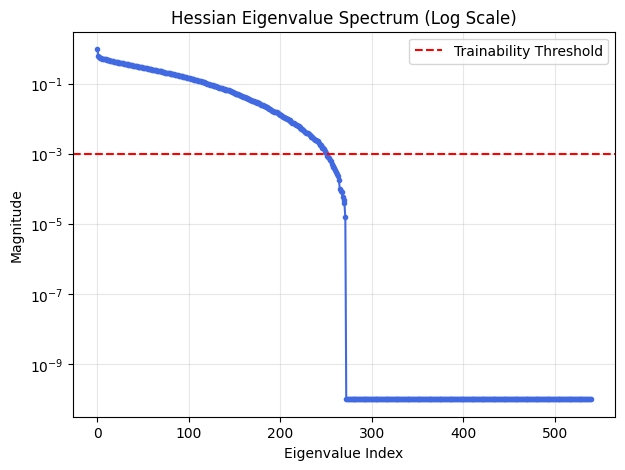

In [85]:
# plot_landscape(H, theta_star, loss_func)

# 1. Compute eigenvalues (H is symmetric, so we use eigvalsh)
eigenvalues = np.linalg.eigvalsh(H)
eigenvalues = np.sort(eigenvalues)[::-1]  # Sort descending

# 2. Plot
plt.figure(figsize=(7, 5))
plt.semilogy(np.maximum(eigenvalues, 1e-10), 'o-', markersize=3, color='royalblue')
plt.title("Hessian Eigenvalue Spectrum (Log Scale)")
plt.xlabel("Eigenvalue Index")
plt.ylabel("Magnitude")
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.axhline(y=1e-3, color='r', linestyle='--', label='Trainability Threshold')
plt.legend()
plt.show()

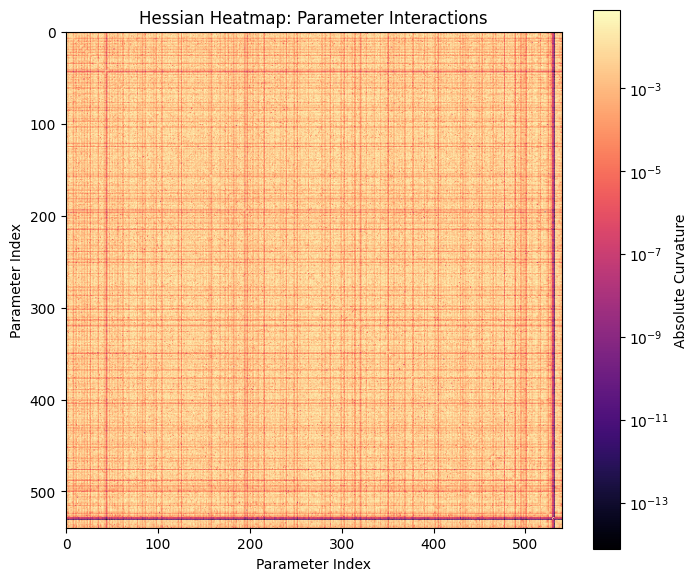

In [87]:
plt.figure(figsize=(8, 7))
# We use log scale for the colorbar to see subtle correlations
plt.imshow(np.abs(H), cmap='magma', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(label='Absolute Curvature')
plt.title("Hessian Heatmap: Parameter Interactions")
plt.xlabel("Parameter Index")
plt.ylabel("Parameter Index")
plt.show()

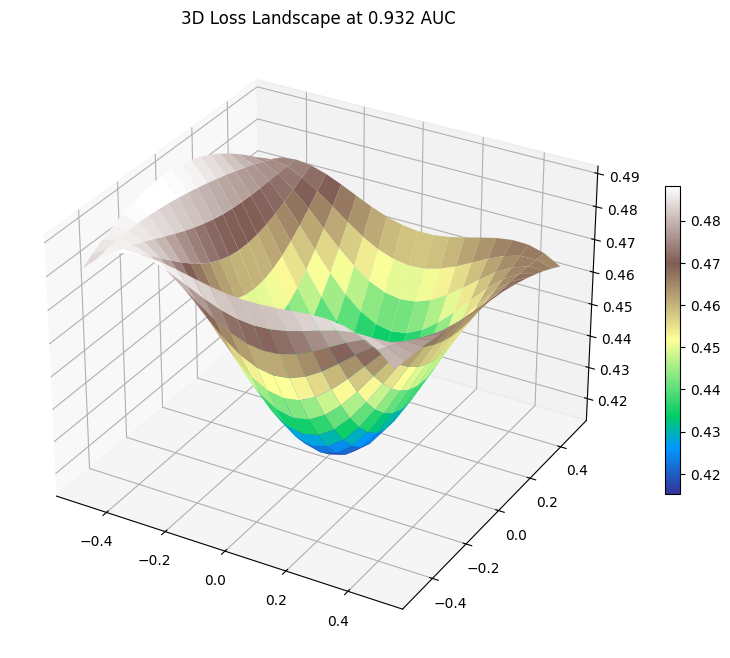

In [88]:
def plot_3d_bowl(H, theta_star, loss_fn):
    # Get top 2 eigenvectors
    vals, vecs = np.linalg.eigh(H)
    u, v = vecs[:, -1], vecs[:, -2] # Directions of maximum curvature

    # Create a grid of steps
    steps = np.linspace(-0.5, 0.5, 20)
    X, Y = np.meshgrid(steps, steps)
    Z = np.zeros_like(X)

    for i in range(20):
        for j in range(20):
            # Perturb weights: theta = theta_star + alpha*u + beta*v
            p_perturbed = theta_star + X[i,j]*u + Y[i,j]*v
            Z[i,j] = loss_fn(p_perturbed)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='terrain', antialiased=True)
    ax.set_title("3D Loss Landscape at 0.932 AUC")
    plt.colorbar(surf, ax=ax, shrink=0.5)
    plt.show()

In [90]:
len(eigenvalues), eigenvalues

(540,
 array([ 9.74147141e-01,  6.09234512e-01,  5.84898293e-01,  5.55245817e-01,
         5.44265747e-01,  5.27759433e-01,  5.19949615e-01,  5.14578044e-01,
         5.01598477e-01,  4.98145461e-01,  4.86237854e-01,  4.77656662e-01,
         4.74173427e-01,  4.66577560e-01,  4.60912317e-01,  4.57095176e-01,
         4.41060603e-01,  4.36087996e-01,  4.33162183e-01,  4.30121630e-01,
         4.23538148e-01,  4.13439274e-01,  4.09866989e-01,  4.02751029e-01,
         3.97658467e-01,  3.88861448e-01,  3.87925178e-01,  3.85729671e-01,
         3.82333547e-01,  3.78941774e-01,  3.77469808e-01,  3.67467850e-01,
         3.59496236e-01,  3.57316524e-01,  3.53335619e-01,  3.48800302e-01,
         3.44051868e-01,  3.42232645e-01,  3.35642487e-01,  3.32168698e-01,
         3.27831388e-01,  3.23193580e-01,  3.19220632e-01,  3.15592229e-01,
         3.10748369e-01,  3.07215750e-01,  3.05772215e-01,  2.98262358e-01,
         2.97074646e-01,  2.94356823e-01,  2.89625645e-01,  2.81042606e-01,
      

In [91]:
# 1. Get the eigenvector for the largest eigenvalue
vals, vecs = np.linalg.eigh(H)
# The last column corresponds to the largest eigenvalue
top_eigenvector = vecs[:, -1]

# 2. Calculate "Parameter Importance" 
# We use the square of the eigenvector components
importance = np.abs(top_eigenvector)**2

# 3. Find the indices of the top 10 most influential parameters
top_indices = np.argsort(importance)[-10:][::-1]

print("Top 10 Influential Parameter Indices:", top_indices)
print("Importance Values:", importance[top_indices])

Top 10 Influential Parameter Indices: [ 24  18   9  21  15  36   6  27  72 510]
Importance Values: [0.07714453 0.0445691  0.04063092 0.0342218  0.03315779 0.03125503
 0.03008801 0.02712998 0.01934294 0.01904381]


In [ ]:
# Run it using the loss function from your analyze_geometry
plot_3d_bowl(H, theta_star, loss_func)

In [60]:
print(type(model))
print(isinstance(model, BaseClassifier))

NameError: name 'model' is not defined

In [61]:
# for layer in model.moduleList:
#     layer.requires_grad = False
# model.siamese_128_rect.requires_grad = False
# # model.siamese_128_cone.requires_grad = False
# # model.direct_transfer__layer1.requires_grad = False
# # model.direct_transfer__layer2.requires_grad = False
# # model.direct_transfer__layer3.requires_grad = False
# # model.BioAct_Het__mlp.requires_grad = False

In [62]:
# model.frozen_inference(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='seen', device=torch.device('cuda')))

In [63]:
# Xam,Xat = [],[]
# dataStream = dataClass.mode_proteins__batch(batchSize=256, type='test', mode='seen', device=torch.device('cuda'))

In [64]:
# while True:
#     try:
#         X,Y = next(dataStream)
#     except:
#         break
#     Xam_,Xat_ = model.frozen_inference(X, mode=-1)
#     # print("shapes:", Xam_.shape, Xat_.shape)
#     Xam_ = Xam_.detach().cpu().numpy()
#     Xat_ = Xat_.detach().cpu().numpy()
#     Xam.append(Xam_)
#     Xat.append(Xat_)

In [65]:
# Xam,Xat = np.hstack(Xam[:-1]).astype('int32'),np.hstack(Xat[:-1]).astype('float32')

In [66]:
# Xam.shape, Xat.shape

In [67]:
# type(Xam), type(Xam[0]), type(Xam[0][0]), type(Xat), type(Xat[0]), type(Xat[0][0])

In [68]:
# Y_pre = self.calculate_y_logit(X, mode)['y_logit']

In [165]:
quantum__post_classical__model = Quantum__Amplitude(outSize=128, n_blocks=3, n_layers=6, n_wires=8, n_params=3, n_params__cswitch=0, frozen_model=model, classical_head=[8, 16], bn_on_q_output=False)


In [166]:
quantum__post_classical__model.train(dataClass, trainSize=256, batchSize=256, epoch=100, 
            lr1=0.01, stopRounds=-1, earlyStop=30,
            savePath='BridgeDTI__QuantumHybrid', metrics="AUC", report=["ACC", "AUC", "LOSS"], 
            preheat=0, weightDecay=1e-4)
# , weightDecay=1e-3

optimType: Adam
Start pre-heat training:
Start normal training: 
training started: 0 196
Direct Output-Label Correlation: -1.4237e-01
module name: QuantumMLP
Checking gradient connectivity:
  vqc_weights: Has Grad
module name: cHead_1
--- QuantumMLP Gradient Analysis ---
Mean Abs Grad: 2.2177e-03
Grad Variance: 4.7489e-05


XlaRuntimeError: INTERNAL: CUDA error: : CUDA_ERROR_ILLEGAL_INSTRUCTION: an illegal instruction was encountered

In [71]:
quantum__post_classical__model.qlayer.state_dict()['qlayer.vqc_weights'].requires_grad
# quantum_weights.requires_grad
# quantum__post_classical__model.moduleList[0]

NameError: name 'quantum__post_classical__model' is not defined

# Sanity Check

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [73]:
# model.fFcLinear.state_dict()

In [ ]:
def plot_loss_landscape(model, inputs, labels, criterion, steps=20):
    # Get current weights
    # cFcLinear, fFcLinear, pCNN, pFcLinear, amEmbedding, dCNN, dFcLinear
    weights = model.qlayer.state_dict()['qlayer.vqc_weights'].detach().clone()
    # weights = model.fFcLinear.state_dict()['hiddens.0.0.bias'].detach().clone()
    
    # Create two random direction vectors (normalized)
    dir1 = torch.randn_like(weights)
    dir2 = torch.randn_like(weights)
    dir1 /= torch.norm(dir1)
    dir2 /= torch.norm(dir2)
    
    x = np.linspace(-1, 1, steps)
    y = np.linspace(-1, 1, steps)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros((steps, steps))
    
    for i in range(steps):
        for j in range(steps):
            # Shift weights: W_new = W_orig + x*dir1 + y*dir2
            new_weights = weights + X[i,j]*dir1 + Y[i,j]*dir2
            
            # Temporarily inject weights into model
            with torch.no_grad():
                model.qlayer.state_dict()['qlayer.vqc_weights'].copy_(new_weights)
                # model.fFcLinear.state_dict()['hiddens.0.0.bias'].copy_(new_weights)
                outputs = model.calculate_y_logit(inputs, 'predict')['y_logit']
                loss = criterion(outputs, labels)
                Z[i,j] = loss.item()
                
    # Restore original weights
    model.qlayer.state_dict()['qlayer.vqc_weights'].copy_(weights)
    # model.fFcLinear.state_dict()['hiddens.0.0.bias'].copy_(weights)
    
    # 3D Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    ax.set_title("Quantum Loss Landscape")
    fig.colorbar(surf)
    plt.show()

In [ ]:
trainStream = dataClass.one_epoch_batch_data_stream(device=device)
X, Y = next(trainStream)

In [ ]:
plot_loss_landscape(model, X, Y, nn.BCEWithLogitsLoss())

In [ ]:
# plot_loss_landscape(quantum__post_classical__model, X, Y, QuantumContrastiveLoss(margin=0.5))
plot_loss_landscape(quantum__post_classical__model, X, Y, nn.BCEWithLogitsLoss())

In [ ]:
# quantum__post_classical__model.qlayer.qlayer.grad
# quantum__post_classical__model.qlayer.qnode_weights['vqc_weights'].grad
# .vqc_weights.grad.norm()

In [ ]:
# params = quantum__post_classical__model.qlayer.state_dict()['qlayer.vqc_weights']
# grad = qml.grad(circuit__1, argnum=0)
# gradient = grad(params, random_gate_sequence=gate_sequence)
# grad_vals.append(gradient[-1])

inputs__ = torch.randn(1, 256)
inputs__ = inputs__ / torch.norm(inputs__, dim=1, keepdim=True)
theta_RY_switch__ = quantum__post_classical__model.qlayer.state_dict()['qlayer.theta_RY_switch']
vqc_weights__ = quantum__post_classical__model.qlayer.state_dict()['qlayer.vqc_weights']

# theta_RY_switch__.requires_grad = True
# vqc_weights__.requires_grad = True

circuit__1(inputs__, theta_RY_switch__, vqc_weights__)
# quantum__post_classical__model.qlayer(Xam__, Xat__)

In [ ]:
# params = quantum__post_classical__model.qlayer.state_dict()['qlayer.vqc_weights']
# grad = qml.grad(circuit__1, argnum=0)
# gradient = grad(params, random_gate_sequence=gate_sequence)
# grad_vals.append(gradient[-1])

# inputs__ = torch.randn(1, 256)
# inputs__ = inputs__ / torch.norm(inputs__, dim=1, keepdim=True)
theta_RY_switch__d = theta_RY_switch__ / 100
vqc_weights__d = vqc_weights__ / 100

theta_RY_switch__ += theta_RY_switch__d
vqc_weights__ += vqc_weights__d

# theta_RY_switch__.requires_grad = True
# vqc_weights__.requires_grad = True

circuit__1(inputs__, theta_RY_switch__, vqc_weights__)
# quantum__post_classical__model.qlayer(Xam__, Xat__)

In [64]:
# for l in quantum__post_classical__model.classical_pre.moduleList:
#     for param in l.parameters():
#     # if True:
#         print(param)

## Normal classical eval

In [154]:
model.to_eval_mode()
# Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(batchSize=256, type='test', device=torch.device('cuda')))

print("Test")
print("seen")
Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='seen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("unseen")
Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='unseen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("Valid")
print("seen")
Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='valid', mode='seen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("unseen")
Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='valid', mode='unseen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

Test
seen
ACC: 0.9506831056314562
AUC: 0.9816232428049686
LOSS: 0.17322909635343794
unseen
ACC: 0.8556043079377742
AUC: 0.9256422626177253
LOSS: 0.37920860158974967
Valid
seen
ACC: 0.9552529182879378
AUC: 0.9870215773195703
LOSS: 0.14373337679534146
unseen
ACC: 0.8485929449068569
AUC: 0.914761043201977
LOSS: 0.41568320403886966


In [ ]:
quantum__post_classical__model.to_eval_mode()
# Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(batchSize=256, type='test', device=torch.device('cuda')))

print("Test")
print("seen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='seen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("unseen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='unseen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("Valid")
print("seen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='valid', mode='seen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("unseen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='valid', mode='unseen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

# From GTB-DTI

In [ ]:
trainer = Trainer(cfg, logger, model_path=perf_save_path, seed=42)

In [ ]:
if cfg.task['train'] == 'kfold':
    trainer.K_fold_train()
elif cfg.task['train'] == 'train_test':
    trainer.train_test()
elif cfg.task['train'] == 'memory_test':
    trainer.mem_speed_bench()

In [ ]:
print(1 + 1)

# BioPython case study

In [189]:
# !pip install biopython

In [6]:
from Bio import Entrez, SeqIO

Entrez.email = "soham.pawar127@iiitb.ac.in" 

In [13]:
# for seq_record in SeqIO.parse("YP_009725307.1.faa", "fasta"):
#     print(seq_record.id)
#     print(seq_record.seq)
#     print(len(seq_record))

In [192]:
accession = "NC_045512.2" 

In [193]:
def fetch_case_study_proteins(target_range=(25393, 29533)):
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    
    case_study_data = {}
    
    for feature in record.features:
        if feature.type == "CDS":
            # Check if the protein falls within the specified gene fragment range
            start = int(feature.location.start) + 1
            end = int(feature.location.end)
            
            # We target the cluster mentioned in the paper
            product_name = feature.qualifiers.get("product", [""])[0]
            if start >= target_range[0] and end <= target_range[1] + 100:
                translation = feature.qualifiers.get("translation", [None])[0]
                if translation:
                    case_study_data[product_name] = translation
                    
    return case_study_data

In [194]:
covid_proteins = fetch_case_study_proteins()
for name, seq in covid_proteins.items():
    print(f"Fetched {name}: {len(seq)} AA")

Fetched ORF3a protein: 275 AA
Fetched envelope protein: 75 AA
Fetched membrane glycoprotein: 222 AA
Fetched ORF6 protein: 61 AA
Fetched ORF7a protein: 121 AA
Fetched ORF7b: 43 AA
Fetched ORF8 protein: 121 AA
Fetched nucleocapsid phosphoprotein: 419 AA


# Proteins

ORF3a (25393..26220): MDLFMRIFTIGTVTLKQGEIKDATPSDFVRATATIPIQASLPFGWLIVGVALLAVFQSASKIITLKKRWQLALSKGVHFVCNLLLLFVTVYSHLLLVAAGLEAPFLYLYALVYFLQSINFVRIIMRLWLCWKCRSKNPLLYDANYFLCWHTNCYDYCIPYNSVTSSIVITSGDGTTSPISEHDYQIGGYTEKWESGVKDCVVLHSYFTSDYYQLYSTQLSTDTGVEHVTFFIYNKIVDEPEEHVQIHTIDGSSGVVNPVMEPIYDEPTTTTSVPL

envelope protein (26245..26472): MYSFVSEETGTLIVNSVLLFLAFVVFLLVTLAILTALRLCAYCCNIVNVSLVKPSFYVYSRVKNLNSSRVPDLLV

ORF6 (27202..27387): MFHLVDFQVTIAEILLIIMRTFKVSIWNLDYIINLIIKNLSKSLTENKYSQLDEEQPMEID

ORF7a (27394..27759): MKIILFLALITLATCELYHYQECVRGTTVLLKEPCSSGTYEGNSPFHPLADNKFALTCFSTQFAFACPDGVKHVYQLRARSVSPKLFIRQEEVQELYSPIFLIVAAIVFITLCFTLKRKTE

ORF7b (27756..27887): MIELSLIDFYLCFLAFLLFLVLIMLIIFWFSLELQDHNETCHA

ORF8 (27894..28259): MKFLVFLGIITTVAAFHQECSLQSCTQHQPYVVDDPCPIHFYSKWYIRVGARKSAPLIELCVDEAGSKSPIQYIDIGNYTVSCLPFTINCQEPKLGSLVVRCSFYEDFLEYHDVRVVLDFI

nucleocapsid phosphoprotein (28274..29533): MSDNGPQNQRNAPRITFGGPSDSTGSNQNGERSGARSKQRRPQGLPNNTASWFTALTQHGKEDLKFPRGQGVPINTNSSPDDQIGYYRRATRRIRGGDGKMKDLSPRWYFYYLGTGPEAGLPYGANKDGIIWVATEGALNTPKDHIGTRNPANNAAIVLQLPQGTTLPKGFYAEGSRGGSQASSRSSSRSRNSSRNSTPGSSRGTSPARMAGNGGDAALALLLLDRLNQLESKMSGKGQQQQGQTVTKKSAAEASKKPRQKRTATKAYNVTQAFGRRGPEQTQGNFGDQELIRQGTDYKHWPQIAQFAPSASAFFGMSRIGMEVTPSGTWLTYTGAIKLDDKDPNFKDQVILLNKHIDAYKTFPPTEPKKDKKKKADETQALPQRQKKQQTVTLLPAADLDDFSKQLQQSMSSADSTQA

# Drugs

Hydroxychloroquine: CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO

Chloroquine: CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl

Dexamethasone: C\[C@@H]1C\[C@H]2\[C@@H]3CCC4=CC(=O)C=C\[C@@]4(\[C@]3(\[C@H](C\[C@@]2(\[C@]1(C(=O)CO)O)C)O)F)C

Remdesivir: CCC(CC)COC(=O)\[C@H](C)N\[P@](=O)(OC\[C@@H]1\[C@H](\[C@H](\[C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4

Nafamostat: C1=CC(=CC=C1C(=O)OC2=CC3=C(C=C2)C=C(C=C3)C(=N)N)N=C(N)N

Camostat: CN(C)C(=O)COC(=O)CC1=CC=C(C=C1)OC(=O)C2=CC=C(C=C2)N=C(N)N

Pepcid: C1=C(N=C(S1)N=C(N)N)CSCC/C(=N/S(=O)(=O)N)/N

Arbidol: CCOC(=O)C1=C(N(C2=CC(=C(C(=C21)CN(C)C)O)Br)C)CSC3=CC=CC=C3.Cl

Nitazoxanide: CC(=O)OC1=CC=CC=C1C(=O)NC2=NC=C(S2)\[N+](=O)\[O-]

Ivermectin: CC\[C@H](C)\[C@@H]1\[C@H](CC\[C@@]2(O1)C\[C@@H]3C\[C@H](O2)C/C=C(/\[C@H](\[C@H](/C=C/C=C/4\\CO\[C@H]5\[C@@]4(\[C@@H](C=C(\[C@H]5O)C)C(=O)O3)O)C)O\[C@H]6C\[C@@H](\[C@H](\[C@@H](O6)C)O\[C@H]7C\[C@@H](\[C@H](\[C@@H](O7)C)O)OC)OC)\\C)C

Fluvoxamine: COCCCC/C(=N\\OCCN)/C1=CC=C(C=C1)C(F)(F)F

EIDD-2801: CC(C)C(=O)OC\[C@@H]1\[C@H](\[C@H](\[C@@H](O1)N2C=CC(=NC2=O)NO)O)O

In [155]:
model.to_eval_mode()

In [156]:
# proteins = ["MDLFMRIFTIGTVTLKQGEIKDATPSDFVRATATIPIQASLPFGWLIVGVALLAVFQSASKIITLKKRWQLALSKGVHFVCNLLLLFVTVYSHLLLVAAGLEAPFLYLYALVYFLQSINFVRIIMRLWLCWKCRSKNPLLYDANYFLCWHTNCYDYCIPYNSVTSSIVITSGDGTTSPISEHDYQIGGYTEKWESGVKDCVVLHSYFTSDYYQLYSTQLSTDTGVEHVTFFIYNKIVDEPEEHVQIHTIDGSSGVVNPVMEPIYDEPTTTTSVPL",
#             "MYSFVSEETGTLIVNSVLLFLAFVVFLLVTLAILTALRLCAYCCNIVNVSLVKPSFYVYSRVKNLNSSRVPDLLV",
#             "MFHLVDFQVTIAEILLIIMRTFKVSIWNLDYIINLIIKNLSKSLTENKYSQLDEEQPMEID",
#             "MKIILFLALITLATCELYHYQECVRGTTVLLKEPCSSGTYEGNSPFHPLADNKFALTCFSTQFAFACPDGVKHVYQLRARSVSPKLFIRQEEVQELYSPIFLIVAAIVFITLCFTLKRKTE",
#             "MIELSLIDFYLCFLAFLLFLVLIMLIIFWFSLELQDHNETCHA",
#             "MKFLVFLGIITTVAAFHQECSLQSCTQHQPYVVDDPCPIHFYSKWYIRVGARKSAPLIELCVDEAGSKSPIQYIDIGNYTVSCLPFTINCQEPKLGSLVVRCSFYEDFLEYHDVRVVLDFI",
#             "MSDNGPQNQRNAPRITFGGPSDSTGSNQNGERSGARSKQRRPQGLPNNTASWFTALTQHGKEDLKFPRGQGVPINTNSSPDDQIGYYRRATRRIRGGDGKMKDLSPRWYFYYLGTGPEAGLPYGANKDGIIWVATEGALNTPKDHIGTRNPANNAAIVLQLPQGTTLPKGFYAEGSRGGSQASSRSSSRSRNSSRNSTPGSSRGTSPARMAGNGGDAALALLLLDRLNQLESKMSGKGQQQQGQTVTKKSAAEASKKPRQKRTATKAYNVTQAFGRRGPEQTQGNFGDQELIRQGTDYKHWPQIAQFAPSASAFFGMSRIGMEVTPSGTWLTYTGAIKLDDKDPNFKDQVILLNKHIDAYKTFPPTEPKKDKKKKADETQALPQRQKKQQTVTLLPAADLDDFSKQLQQSMSSADSTQA"]
proteins = {"266..21555": "MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRKVLLRKNGNKGAGGHSYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGGAYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAWYTERSEKSYELQTPFEIKLAKKFDTFNGECPNFVFPLNSIIKTIQPRVEKKKLDGFMGRIRSVYPVASPNECNQMCLSTLMKCDHCGETSWQTGDFVKATCEFCGTENLTKEGATTCGYLPQNAVVKIYCPACHNSEVGPEHSLAEYHNESGLKTILRKGGRTIAFGGCVFSYVGCHNKCAYWVPRASANIGCNHTGVVGEGSEGLNDNLLEILQKEKVNINIVGDFKLNEEIAIILASFSASTSAFVETVKGLDYKAFKQIVESCGNFKVTKGKAKKGAWNIGEQKSILSPLYAFASEAARVVRSIFSRTLETAQNSVRVLQKAAITILDGISQYSLRLIDAMMFTSDLATNNLVVMAYITGGVVQLTSQWLTNIFGTVYEKLKPVLDWLEEKFKEGVEFLRDGWEIVKFISTCACEIVGGQIVTCAKEIKESVQTFFKLVNKFLALCADSIIIGGAKLKALNLGETFVTHSKGLYRKCVKSREETGLLMPLKAPKEIIFLEGETLPTEVLTEEVVLKTGDLQPLEQPTSEAVEAPLVGTPVCINGLMLLEIKDTEKYCALAPNMMVTNNTFTLKGGAPTKVTFGDDTVIEVQGYKSVNITFELDERIDKVLNEKCSAYTVELGTEVNEFACVVADAVIKTLQPVSELLTPLGIDLDEWSMATYYLFDESGEFKLASHMYCSFYPPDEDEEEGDCEEEEFEPSTQYEYGTEDDYQGKPLEFGATSAALQPEEEQEEDWLDDDSQQTVGQQDGSEDNQTTTIQTIVEVQPQLEMELTPVVQTIEVNSFSGYLKLTDNVYIKNADIVEEAKKVKPTVVVNAANVYLKHGGGVAGALNKATNNAMQVESDDYIATNGPLKVGGSCVLSGHNLAKHCLHVVGPNVNKGEDIQLLKSAYENFNQHEVLLAPLLSAGIFGADPIHSLRVCVDTVRTNVYLAVFDKNLYDKLVSSFLEMKSEKQVEQKIAEIPKEEVKPFITESKPSVEQRKQDDKKIKACVEEVTTTLEETKFLTENLLLYIDINGNLHPDSATLVSDIDITFLKKDAPYIVGDVVQEGVLTAVVIPTKKAGGTTEMLAKALRKVPTDNYITTYPGQGLNGYTVEEAKTVLKKCKSAFYILPSIISNEKQEILGTVSWNLREMLAHAEETRKLMPVCVETKAIVSTIQRKYKGIKIQEGVVDYGARFYFYTSKTTVASLINTLNDLNETLVTMPLGYVTHGLNLEEAARYMRSLKVPATVSVSSPDAVTAYNGYLTSSSKTPEEHFIETISLAGSYKDWSYSGQSTQLGIEFLKRGDKSVYYTSNPTTFHLDGEVITFDNLKTLLSLREVRTIKVFTTVDNINLHTQVVDMSMTYGQQFGPTYLDGADVTKIKPHNSHEGKTFYVLPNDDTLRVEAFEYYHTTDPSFLGRYMSALNHTKKWKYPQVNGLTSIKWADNNCYLATALLTLQQIELKFNPPALQDAYYRARAGEAANFCALILAYCNKTVGELGDVRETMSYLFQHANLDSCKRVLNVVCKTCGQQQTTLKGVEAVMYMGTLSYEQFKKGVQIPCTCGKQATKYLVQQESPFVMMSAPPAQYELKHGTFTCASEYTGNYQCGHYKHITSKETLYCIDGALLTKSSEYKGPITDVFYKENSYTTTIKPVTYKLDGVVCTEIDPKLDNYYKKDNSYFTEQPIDLVPNQPYPNASFDNFKFVCDNIKFADDLNQLTGYKKPASRELKVTFFPDLNGDVVAIDYKHYTPSFKKGAKLLHKPIVWHVNNATNKATYKPNTWCIRCLWSTKPVETSNSFDVLKSEDAQGMDNLACEDLKPVSEEVVENPTIQKDVLECNVKTTEVVGDIILKPANNSLKITEEVGHTDLMAAYVDNSSLTIKKPNELSRVLGLKTLATHGLAAVNSVPWDTIANYAKPFLNKVVSTTTNIVTRCLNRVCTNYMPYFFTLLLQLCTFTRSTNSRIKASMPTTIAKNTVKSVGKFCLEASFNYLKSPNFSKLINIIIWFLLLSVCLGSLIYSTAALGVLMSNLGMPSYCTGYREGYLNSTNVTIATYCTGSIPCSVCLSGLDSLDTYPSLETIQITISSFKWDLTAFGLVAEWFLAYILFTRFFYVLGLAAIMQLFFSYFAVHFISNSWLMWLIINLVQMAPISAMVRMYIFFASFYYVWKSYVHVVDGCNSSTCMMCYKRNRATRVECTTIVNGVRRSFYVYANGGKGFCKLHNWNCVNCDTFCAGSTFISDEVARDLSLQFKRPINPTDQSSYIVDSVTVKNGSIHLYFDKAGQKTYERHSLSHFVNLDNLRANNTKGSLPINVIVFDGKSKCEESSAKSASVYYSQLMCQPILLLDQALVSDVGDSAEVAVKMFDAYVNTFSSTFNVPMEKLKTLVATAEAELAKNVSLDNVLSTFISAARQGFVDSDVETKDVVECLKLSHQSDIEVTGDSCNNYMLTYNKVENMTPRDLGACIDCSARHINAQVAKSHNIALIWNVKDFMSLSEQLRKQIRSAAKKNNLPFKLTCATTRQVVNVVTTKIALKGGKIVNNWLKQLIKVTLVFLFVAAIFYLITPVHVMSKHTDFSSEIIGYKAIDGGVTRDIASTDTCFANKHADFDTWFSQRGGSYTNDKACPLIAAVITREVGFVVPGLPGTILRTTNGDFLHFLPRVFSAVGNICYTPSKLIEYTDFATSACVLAAECTIFKDASGKPVPYCYDTNVLEGSVAYESLRPDTRYVLMDGSIIQFPNTYLEGSVRVVTTFDSEYCRHGTCERSEAGVCVSTSGRWVLNNDYYRSLPGVFCGVDAVNLLTNMFTPLIQPIGALDISASIVAGGIVAIVVTCLAYYFMRFRRAFGEYSHVVAFNTLLFLMSFTVLCLTPVYSFLPGVYSVIYLYLTFYLTNDVSFLAHIQWMVMFTPLVPFWITIAYIICISTKHFYWFFSNYLKRRVVFNGVSFSTFEEAALCTFLLNKEMYLKLRSDVLLPLTQYNRYLALYNKYKYFSGAMDTTSYREAACCHLAKALNDFSNSGSDVLYQPPQTSITSAVLQSGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQSAVKRTIKGTHHWLLLTILTSLLVLVQSTQWSLFFFLYENAFLPFAMGIIAMSAFAMMFVKHKHAFLCLFLLPSLATVAYFNMVYMPASWVMRIMTWLDMVDTSLSGFKLKDCVMYASAVVLLILMTARTVYDDGARRVWTLMNVLTLVYKVYYGNALDQAISMWALIISVTSNYSGVVTTVMFLARGIVFMCVEYCPIFFITGNTLQCIMLVYCFLGYFCTCYFGLFCLLNRYFRLTLGVYDYLVSTQEFRYMNSQGLLPPKNSIDAFKLNIKLLGVGGKPCIKVATVQSKMSDVKCTSVVLLSVLQQLRVESSSKLWAQCVQLHNDILLAKDTTEAFEKMVSLLSVLLSMQGAVDINKLCEEMLDNRATLQAIASEFSSLPSYAAFATAQEAYEQAVANGDSEVVLKKLKKSLNVAKSEFDRDAAMQRKLEKMADQAMTQMYKQARSEDKRAKVTSAMQTMLFTMLRKLDNDALNNIINNARDGCVPLNIIPLTTAAKLMVVIPDYNTYKNTCDGTTFTYASALWEIQQVVDADSKIVQLSEISMDNSPNLAWPLIVTALRANSAVKLQNNELSPVALRQMSCAAGTTQTACTDDNALAYYNTTKGGRFVLALLSDLQDLKWARFPKSDGTGTIYTELEPPCRFVTDTPKGPKVKYLYFIKGLNNLNRGMVLGSLAATVRLQAGNATEVPANSTVLSFCAFAVDAAKAYKDYLASGGQPITNCVKMLCTHTGTGQAITVTPEANMDQESFGGASCCLYCRCHIDHPNPKGFCDLKGKYVQIPTTCANDPVGFTLKNTVCTVCGMWKGYGCSCDQLREPMLQSADAQSFLNRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKTNCCRFQEKDEDDNLIDSYFVVKRHTFSNYQHEETIYNLLKDCPAVAKHDFFKFRIDGDMVPHISRQRLTKYTMADLVYALRHFDEGNCDTLKEILVTYNCCDDDYFNKKDWYDFVENPDILRVYANLGERVRQALLKTVQFCDAMRNAGIVGVLTLDNQDLNGNWYDFGDFIQTTPGSGVPVVDSYYSLLMPILTLTRALTAESHVDTDLTKPYIKWDLLKYDFTEERLKLFDRYFKYWDQTYHPNCVNCLDDRCILHCANFNVLFSTVFPPTSFGPLVRKIFVDGVPFVVSTGYHFRELGVVHNQDVNLHSSRLSFKELLVYAADPAMHAASGNLLLDKRTTCFSVAALTNNVAFQTVKPGNFNKDFYDFAVSKGFFKEGSSVELKHFFFAQDGNAAISDYDYYRYNLPTMCDIRQLLFVVEVVDKYFDCYDGGCINANQVIVNNLDKSAGFPFNKWGKARLYYDSMSYEDQDALFAYTKRNVIPTITQMNLKYAISAKNRARTVAGVSICSTMTNRQFHQKLLKSIAATRGATVVIGTSKFYGGWHNMLKTVYSDVENPHLMGWDYPKCDRAMPNMLRIMASLVLARKHTTCCSLSHRFYRLANECAQVLSEMVMCGGSLYVKPGGTSSGDATTAYANSVFNICQAVTANVNALLSTDGNKIADKYVRNLQHRLYECLYRNRDVDTDFVNEFYAYLRKHFSMMILSDDAVVCFNSTYASQGLVASIKNFKSVLYYQNNVFMSEAKCWTETDLTKGPHEFCSQHTMLVKQGDDYVYLPYPDPSRILGAGCFVDDIVKTDGTLMIERFVSLAIDAYPLTKHPNQEYADVFHLYLQYIRKLHDELTGHMLDMYSVMLTNDNTSRYWEPEFYEAMYTPHTVLQAVGACVLCNSQTSLRCGACIRRPFLCCKCCYDHVISTSHKLVLSVNPYVCNAPGCDVTDVTQLYLGGMSYYCKSHKPPISFPLCANGQVFGLYKNTCVGSDNVTDFNAIATCDWTNAGDYILANTCTERLKLFAAETLKATEETFKLSYGIATVREVLSDRELHLSWEVGKPRPPLNRNYVFTGYRVTKNSKVQIGEYTFEKGDYGDAVVYRGTTTYKLNVGDYFVLTSHTVMPLSAPTLVPQEHYVRITGLYPTLNISDEFSSNVANYQKVGMQKYSTLQGPPGTGKSHFAIGLALYYPSARIVYTACSHAAVDALCEKALKYLPIDKCSRIIPARARVECFDKFKVNSTLEQYVFCTVNALPETTADIVVFDEISMATNYDLSVVNARLRAKHYVYIGDPAQLPAPRTLLTKGTLEPEYFNSVCRLMKTIGPDMFLGTCRRCPAEIVDTVSALVYDNKLKAHKDKSAQCFKMFYKGVITHDVSSAINRPQIGVVREFLTRNPAWRKAVFISPYNSQNAVASKILGLPTQTVDSSQGSEYDYVIFTQTTETAHSCNVNRFNVAITRAKVGILCIMSDRDLYDKLQFTSLEIPRRNVATLQAENVTGLFKDCSKVITGLHPTQAPTHLSVDTKFKTEGLCVDIPGIPKDMTYRRLISMMGFKMNYQVNGYPNMFITREEAIRHVRAWIGFDVEGCHATREAVGTNLPLQLGFSTGVNLVAVPTGYVDTPNNTDFSRVSAKPPPGDQFKHLIPLMYKGLPWNVVRIKIVQMLSDTLKNLSDRVVFVLWAHGFELTSMKYFVKIGPERTCCLCDRRATCFSTASDTYACWHHSIGFDYVYNPFMIDVQQWGFTGNLQSNHDLYCQVHGNAHVASCDAIMTRCLAVHECFVKRVDWTIEYPIIGDELKINAACRKVQHMVVKAALLADKFPVLHDIGNPKAIKCVPQADVEWKFYDAQPCSDKAYKIEELFYSYATHSDKFTDGVCLFWNCNVDRYPANSIVCRFDTRVLSNLNLPGCDGGSLYVNKHAFHTPAFDKSAFVNLKQLPFFYYSDSPCESHGKQVVSDIDYVPLKSATCITRCNLGGAVCRHHANEYRLYLDAYNMMISAGFSLWVYKQFDTYNLWNTFTRLQSLENVAFNVVNKGHFDGQQGEVPVSIINNTVYTKVDGVDVELFENKTTLPVNVAFELWAKRNIKPVPEVKILNNLGVDIAANTVIWDYKRDAPAHISTIGVCSMTDIAKKPTETICAPLTVFFDGRVDGQVDLFRNARNGVLITEGSVKGLQPSVGPKQASLNGVTLIGEAVKTQFNYYKKVDGVVQQLPETYFTQSRNLQEFKPRSQMEIDFLELAMDEFIERYKLEGYAFEHIVYGDFSHSQLGGLHLLIGLAKRFKESPFELEDFIPMDSTVKNYFITDAQTGSSKCVCSVIDLLLDDFVEIIKSQDLSVVSKVVKVTIDYTEISFMLWCKDGHVETFYPKLQSSQAWQPGVAMPNLYKMQRMLLEKCDLQNYGDSATLPKGIMMNVAKYTQLCQYLNTLTLAVPYNMRVIHFGAGSDKGVAPGTAVLRQWLPTGTLLVDSDLNDFVSDADSTLIGDCATVHTANKWDLIISDMYDPKTKNVTKENDSKEGFFTYICGFIQQKLALGGSVAIKITEHSWNADLYKLMGHFAWWTAFVTNVNASSSEAFLIGCNYLGKPREQIDGYVMHANYIFWRNTNPIQLSSYSLFDMSKFPLKLRGTAVMSLKEGQINDMILSLLSKGRLIIRENNRVVISSDVLVNN",
            "266..13483": "MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRKVLLRKNGNKGAGGHSYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGGAYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAWYTERSEKSYELQTPFEIKLAKKFDTFNGECPNFVFPLNSIIKTIQPRVEKKKLDGFMGRIRSVYPVASPNECNQMCLSTLMKCDHCGETSWQTGDFVKATCEFCGTENLTKEGATTCGYLPQNAVVKIYCPACHNSEVGPEHSLAEYHNESGLKTILRKGGRTIAFGGCVFSYVGCHNKCAYWVPRASANIGCNHTGVVGEGSEGLNDNLLEILQKEKVNINIVGDFKLNEEIAIILASFSASTSAFVETVKGLDYKAFKQIVESCGNFKVTKGKAKKGAWNIGEQKSILSPLYAFASEAARVVRSIFSRTLETAQNSVRVLQKAAITILDGISQYSLRLIDAMMFTSDLATNNLVVMAYITGGVVQLTSQWLTNIFGTVYEKLKPVLDWLEEKFKEGVEFLRDGWEIVKFISTCACEIVGGQIVTCAKEIKESVQTFFKLVNKFLALCADSIIIGGAKLKALNLGETFVTHSKGLYRKCVKSREETGLLMPLKAPKEIIFLEGETLPTEVLTEEVVLKTGDLQPLEQPTSEAVEAPLVGTPVCINGLMLLEIKDTEKYCALAPNMMVTNNTFTLKGGAPTKVTFGDDTVIEVQGYKSVNITFELDERIDKVLNEKCSAYTVELGTEVNEFACVVADAVIKTLQPVSELLTPLGIDLDEWSMATYYLFDESGEFKLASHMYCSFYPPDEDEEEGDCEEEEFEPSTQYEYGTEDDYQGKPLEFGATSAALQPEEEQEEDWLDDDSQQTVGQQDGSEDNQTTTIQTIVEVQPQLEMELTPVVQTIEVNSFSGYLKLTDNVYIKNADIVEEAKKVKPTVVVNAANVYLKHGGGVAGALNKATNNAMQVESDDYIATNGPLKVGGSCVLSGHNLAKHCLHVVGPNVNKGEDIQLLKSAYENFNQHEVLLAPLLSAGIFGADPIHSLRVCVDTVRTNVYLAVFDKNLYDKLVSSFLEMKSEKQVEQKIAEIPKEEVKPFITESKPSVEQRKQDDKKIKACVEEVTTTLEETKFLTENLLLYIDINGNLHPDSATLVSDIDITFLKKDAPYIVGDVVQEGVLTAVVIPTKKAGGTTEMLAKALRKVPTDNYITTYPGQGLNGYTVEEAKTVLKKCKSAFYILPSIISNEKQEILGTVSWNLREMLAHAEETRKLMPVCVETKAIVSTIQRKYKGIKIQEGVVDYGARFYFYTSKTTVASLINTLNDLNETLVTMPLGYVTHGLNLEEAARYMRSLKVPATVSVSSPDAVTAYNGYLTSSSKTPEEHFIETISLAGSYKDWSYSGQSTQLGIEFLKRGDKSVYYTSNPTTFHLDGEVITFDNLKTLLSLREVRTIKVFTTVDNINLHTQVVDMSMTYGQQFGPTYLDGADVTKIKPHNSHEGKTFYVLPNDDTLRVEAFEYYHTTDPSFLGRYMSALNHTKKWKYPQVNGLTSIKWADNNCYLATALLTLQQIELKFNPPALQDAYYRARAGEAANFCALILAYCNKTVGELGDVRETMSYLFQHANLDSCKRVLNVVCKTCGQQQTTLKGVEAVMYMGTLSYEQFKKGVQIPCTCGKQATKYLVQQESPFVMMSAPPAQYELKHGTFTCASEYTGNYQCGHYKHITSKETLYCIDGALLTKSSEYKGPITDVFYKENSYTTTIKPVTYKLDGVVCTEIDPKLDNYYKKDNSYFTEQPIDLVPNQPYPNASFDNFKFVCDNIKFADDLNQLTGYKKPASRELKVTFFPDLNGDVVAIDYKHYTPSFKKGAKLLHKPIVWHVNNATNKATYKPNTWCIRCLWSTKPVETSNSFDVLKSEDAQGMDNLACEDLKPVSEEVVENPTIQKDVLECNVKTTEVVGDIILKPANNSLKITEEVGHTDLMAAYVDNSSLTIKKPNELSRVLGLKTLATHGLAAVNSVPWDTIANYAKPFLNKVVSTTTNIVTRCLNRVCTNYMPYFFTLLLQLCTFTRSTNSRIKASMPTTIAKNTVKSVGKFCLEASFNYLKSPNFSKLINIIIWFLLLSVCLGSLIYSTAALGVLMSNLGMPSYCTGYREGYLNSTNVTIATYCTGSIPCSVCLSGLDSLDTYPSLETIQITISSFKWDLTAFGLVAEWFLAYILFTRFFYVLGLAAIMQLFFSYFAVHFISNSWLMWLIINLVQMAPISAMVRMYIFFASFYYVWKSYVHVVDGCNSSTCMMCYKRNRATRVECTTIVNGVRRSFYVYANGGKGFCKLHNWNCVNCDTFCAGSTFISDEVARDLSLQFKRPINPTDQSSYIVDSVTVKNGSIHLYFDKAGQKTYERHSLSHFVNLDNLRANNTKGSLPINVIVFDGKSKCEESSAKSASVYYSQLMCQPILLLDQALVSDVGDSAEVAVKMFDAYVNTFSSTFNVPMEKLKTLVATAEAELAKNVSLDNVLSTFISAARQGFVDSDVETKDVVECLKLSHQSDIEVTGDSCNNYMLTYNKVENMTPRDLGACIDCSARHINAQVAKSHNIALIWNVKDFMSLSEQLRKQIRSAAKKNNLPFKLTCATTRQVVNVVTTKIALKGGKIVNNWLKQLIKVTLVFLFVAAIFYLITPVHVMSKHTDFSSEIIGYKAIDGGVTRDIASTDTCFANKHADFDTWFSQRGGSYTNDKACPLIAAVITREVGFVVPGLPGTILRTTNGDFLHFLPRVFSAVGNICYTPSKLIEYTDFATSACVLAAECTIFKDASGKPVPYCYDTNVLEGSVAYESLRPDTRYVLMDGSIIQFPNTYLEGSVRVVTTFDSEYCRHGTCERSEAGVCVSTSGRWVLNNDYYRSLPGVFCGVDAVNLLTNMFTPLIQPIGALDISASIVAGGIVAIVVTCLAYYFMRFRRAFGEYSHVVAFNTLLFLMSFTVLCLTPVYSFLPGVYSVIYLYLTFYLTNDVSFLAHIQWMVMFTPLVPFWITIAYIICISTKHFYWFFSNYLKRRVVFNGVSFSTFEEAALCTFLLNKEMYLKLRSDVLLPLTQYNRYLALYNKYKYFSGAMDTTSYREAACCHLAKALNDFSNSGSDVLYQPPQTSITSAVLQSGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQSAVKRTIKGTHHWLLLTILTSLLVLVQSTQWSLFFFLYENAFLPFAMGIIAMSAFAMMFVKHKHAFLCLFLLPSLATVAYFNMVYMPASWVMRIMTWLDMVDTSLSGFKLKDCVMYASAVVLLILMTARTVYDDGARRVWTLMNVLTLVYKVYYGNALDQAISMWALIISVTSNYSGVVTTVMFLARGIVFMCVEYCPIFFITGNTLQCIMLVYCFLGYFCTCYFGLFCLLNRYFRLTLGVYDYLVSTQEFRYMNSQGLLPPKNSIDAFKLNIKLLGVGGKPCIKVATVQSKMSDVKCTSVVLLSVLQQLRVESSSKLWAQCVQLHNDILLAKDTTEAFEKMVSLLSVLLSMQGAVDINKLCEEMLDNRATLQAIASEFSSLPSYAAFATAQEAYEQAVANGDSEVVLKKLKKSLNVAKSEFDRDAAMQRKLEKMADQAMTQMYKQARSEDKRAKVTSAMQTMLFTMLRKLDNDALNNIINNARDGCVPLNIIPLTTAAKLMVVIPDYNTYKNTCDGTTFTYASALWEIQQVVDADSKIVQLSEISMDNSPNLAWPLIVTALRANSAVKLQNNELSPVALRQMSCAAGTTQTACTDDNALAYYNTTKGGRFVLALLSDLQDLKWARFPKSDGTGTIYTELEPPCRFVTDTPKGPKVKYLYFIKGLNNLNRGMVLGSLAATVRLQAGNATEVPANSTVLSFCAFAVDAAKAYKDYLASGGQPITNCVKMLCTHTGTGQAITVTPEANMDQESFGGASCCLYCRCHIDHPNPKGFCDLKGKYVQIPTTCANDPVGFTLKNTVCTVCGMWKGYGCSCDQLREPMLQSADAQSFLNGFAV",
            "21563..25384": "MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQIDRLITGRLQSLQTYVTQQLIRAAEIRASANLAATKMSECVLGQSKRVDFCGKGYHLMSFPQSAPHGVVFLHVTYVPAQEKNFTTAPAICHDGKAHFPREGVFVSNGTHWFVTQRNFYEPQIITTDNTFVSGNCDVVIGIVNNTVYDPLQPELDSFKEELDKYFKNHTSPDVDLGDISGINASVVNIQKEIDRLNEVAKNLNESLIDLQELGKYEQYIKWPWYIWLGFIAGLIAIVMVTIMLCCMTSCCSCLKGCCSCGSCCKFDEDDSEPVLKGVKLHYT",
            "25393..26220": "MDLFMRIFTIGTVTLKQGEIKDATPSDFVRATATIPIQASLPFGWLIVGVALLAVFQSASKIITLKKRWQLALSKGVHFVCNLLLLFVTVYSHLLLVAAGLEAPFLYLYALVYFLQSINFVRIIMRLWLCWKCRSKNPLLYDANYFLCWHTNCYDYCIPYNSVTSSIVITSGDGTTSPISEHDYQIGGYTEKWESGVKDCVVLHSYFTSDYYQLYSTQLSTDTGVEHVTFFIYNKIVDEPEEHVQIHTIDGSSGVVNPVMEPIYDEPTTTTSVPL",
            "26245..26472": "MYSFVSEETGTLIVNSVLLFLAFVVFLLVTLAILTALRLCAYCCNIVNVSLVKPSFYVYSRVKNLNSSRVPDLLV", 
            "26523..27191": "MADSNGTITVEELKKLLEQWNLVIGFLFLTWICLLQFAYANRNRFLYIIKLIFLWLLWPVTLACFVLAAVYRINWITGGIAIAMACLVGLMWLSYFIASFRLFARTRSMWSFNPETNILLNVPLHGTILTRPLLESELVIGAVILRGHLRIAGHHLGRCDIKDLPKEITVATSRTLSYYKLGASQRVAGDSGFAAYSRYRIGNYKLNTDHSSSSDNIALLVQ",
            "27202..27387": "MFHLVDFQVTIAEILLIIMRTFKVSIWNLDYIINLIIKNLSKSLTENKYSQLDEEQPMEID", 
            "27394..27759": "MKIILFLALITLATCELYHYQECVRGTTVLLKEPCSSGTYEGNSPFHPLADNKFALTCFSTQFAFACPDGVKHVYQLRARSVSPKLFIRQEEVQELYSPIFLIVAAIVFITLCFTLKRKTE", 
            "27756..27887": "MIELSLIDFYLCFLAFLLFLVLIMLIIFWFSLELQDHNETCHA", 
            "27894..28259": "MKFLVFLGIITTVAAFHQECSLQSCTQHQPYVVDDPCPIHFYSKWYIRVGARKSAPLIELCVDEAGSKSPIQYIDIGNYTVSCLPFTINCQEPKLGSLVVRCSFYEDFLEYHDVRVVLDFI", 
            "28274..29533": "MSDNGPQNQRNAPRITFGGPSDSTGSNQNGERSGARSKQRRPQGLPNNTASWFTALTQHGKEDLKFPRGQGVPINTNSSPDDQIGYYRRATRRIRGGDGKMKDLSPRWYFYYLGTGPEAGLPYGANKDGIIWVATEGALNTPKDHIGTRNPANNAAIVLQLPQGTTLPKGFYAEGSRGGSQASSRSSSRSRNSSRNSTPGSSRGTSPARMAGNGGDAALALLLLDRLNQLESKMSGKGQQQQGQTVTKKSAAEASKKPRQKRTATKAYNVTQAFGRRGPEQTQGNFGDQELIRQGTDYKHWPQIAQFAPSASAFFGMSRIGMEVTPSGTWLTYTGAIKLDDKDPNFKDQVILLNKHIDAYKTFPPTEPKKDKKKKADETQALPQRQKKQQTVTLLPAADLDDFSKQLQQSMSSADSTQA",
            "29558..29674": "MGYINVFAFPFTIYSLLLCRMNSRNYIAQVDVVNFNLT"}

proteins_2 = {"3CLpro (PDB ID 6WQF)": "SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ",
              "RdRp (YP_009725307.1)": "SADAQSFLNRVCGVSAARLTPCGTGTSTDVVYRAFDIYNDKVAGFAKFLKTNCCRFQEKDEDDNLIDSYFVVKRHTFSNYQHEETIYNLLKDCPAVAKHDFFKFRIDGDMVPHISRQRLTKYTMADLVYALRHFDEGNCDTLKEILVTYNCCDDDYFNKKDWYDFVENPDILRVYANLGERVRQALLKTVQFCDAMRNAGIVGVLTLDNQDLNGNWYDFGDFIQTTPGSGVPVVDSYYSLLMPILTLTRALTAESHVDTDLTKPYIKWDLLKYDFTEERLKLFDRYFKYWDQTYHPNCVNCLDDRCILHCANFNVLFSTVFPPTSFGPLVRKIFVDGVPFVVSTGYHFRELGVVHNQDVNLHSSRLSFKELLVYAADPAMHAASGNLLLDKRTTCFSVAALTNNVAFQTVKPGNFNKDFYDFAVSKGFFKEGSSVELKHFFFAQDGNAAISDYDYYRYNLPTMCDIRQLLFVVEVVDKYFDCYDGGCINANQVIVNNLDKSAGFPFNKWGKARLYYDSMSYEDQDALFAYTKRNVIPTITQMNLKYAISAKNRARTVAGVSICSTMTNRQFHQKLLKSIAATRGATVVIGTSKFYGGWHNMLKTVYSDVENPHLMGWDYPKCDRAMPNMLRIMASLVLARKHTTCCSLSHRFYRLANECAQVLSEMVMCGGSLYVKPGGTSSGDATTAYANSVFNICQAVTANVNALLSTDGNKIADKYVRNLQHRLYECLYRNRDVDTDFVNEFYAYLRKHFSMMILSDDAVVCFNSTYASQGLVASIKNFKSVLYYQNNVFMSEAKCWTETDLTKGPHEFCSQHTMLVKQGDDYVYLPYPDPSRILGAGCFVDDIVKTDGTLMIERFVSLAIDAYPLTKHPNQEYADVFHLYLQYIRKLHDELTGHMLDMYSVMLTNDNTSRYWEPEFYEAMYTPHTVLQ"}

drugs = {"Hydroxychloroquine": "CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO",
         "Chloroquine": "CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl",
         "Dexamethasone": "C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@@]4([C@]3([C@H](C[C@@]2([C@]1(C(=O)CO)O)C)O)F)C",
         "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@@H]1[C@H]([C@H]([C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4",
         "Nafamostat": "C1=CC(=CC=C1C(=O)OC2=CC3=C(C=C2)C=C(C=C3)C(=N)N)N=C(N)N",
         "Camostat": "CN(C)C(=O)COC(=O)CC1=CC=C(C=C1)OC(=O)C2=CC=C(C=C2)N=C(N)N",
         "Pepcid": "C1=C(N=C(S1)N=C(N)N)CSCC/C(=N/S(=O)(=O)N)/N",
         "Arbidol": "CCOC(=O)C1=C(N(C2=CC(=C(C(=C21)CN(C)C)O)Br)C)CSC3=CC=CC=C3.Cl",
         "Nitazoxanide": "CC(=O)OC1=CC=CC=C1C(=O)NC2=NC=C(S2)[N+](=O)[O-]",
         "Ivermectin": "CC[C@H](C)[C@@H]1[C@H](CC[C@@]2(O1)C[C@@H]3C[C@H](O2)C/C=C(/[C@H]([C@H](/C=C/C=C/4\CO[C@H]5[C@@]4([C@@H](C=C([C@H]5O)C)C(=O)O3)O)C)O[C@H]6C[C@@H]([C@H]([C@@H](O6)C)O[C@H]7C[C@@H]([C@H]([C@@H](O7)C)O)OC)OC)\C)C",
         "Fluvoxamine": "COCCCC/C(=N\OCCN)/C1=CC=C(C=C1)C(F)(F)F",
         "EIDD-2801": "CC(C)C(=O)OC[C@@H]1[C@H]([C@H]([C@@H](O1)N2C=CC(=NC2=O)NO)O)O"}

drugs_2 = {"Baricitinib": "CCS(=O)(=O)N1CC(C1)(CC#N)N2C=C(C=N2)C3=C4C=CNC4=NC=N3",
           "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@@H]1[C@H]([C@H]([C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4",
           "Lopinavir": "CC1=C(C(=CC=C1)C)OCC(=O)N[C@@H](CC2=CC=CC=C2)[C@H](C[C@H](CC3=CC=CC=C3)NC(=O)[C@H](C(C)C)N4CCCNC4=O)O",
           "Ritonavir": "CC(C)C1=NC(=CS1)CN(C)C(=O)N[C@@H](C(C)C)C(=O)N[C@@H](CC2=CC=CC=C2)C[C@@H]([C@H](CC3=CC=CC=C3)NC(=O)OCC4=CN=CS4)O",
           "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
           "Ivermectin": "CC[C@H](C)[C@@H]1[C@H](CC[C@@]2(O1)C[C@@H]3C[C@H](O2)C/C=C(/[C@H]([C@H](/C=C/C=C/4\CO[C@H]5[C@@]4([C@@H](C=C([C@H]5O)C)C(=O)O3)O)C)O[C@H]6C[C@@H]([C@H]([C@@H](O6)C)O[C@H]7C[C@@H]([C@H]([C@@H](O7)C)O)OC)OC)\C)C",
           "Sofosbuvir": "C[C@@H](C(=O)OC(C)C)N[P@](=O)(OC[C@@H]1[C@H]([C@@]([C@@H](O1)N2C=CC(=O)NC2=O)(C)F)O)OC3=CC=CC=C3",
           "Daclatasvir": "CC(C)[C@@H](C(=O)N1CCC[C@H]1C2=NC=C(N2)C3=CC=C(C=C3)C4=CC=C(C=C4)C5=CN=C(N5)[C@@H]6CCCN6C(=O)[C@H](C(C)C)NC(=O)OC)NC(=O)OC",}

In [157]:
# temp = "tccggtat tgtgaaaatg gtaaatccta cttctaaggt agaaccatgtgttgtcagtg ttacctatgg taatatgaca ttgaatggtt tatggttgga tgacaaggtc      tactgtccca gacatgtaat atgttctgct tcagatatga ctaatccaga ttatacaaat      ttgttgtgta gagtaacatc aagtgatttt actgtattgt ttgatcgtct aagccttaca     gtgatgtctt atcaaatgcg gggttgtatg cttgttctta cagtgaccct gcaaaattct     cgtacgccaa aatatacatt tggtgtggtt aaacctggtg agacttttac tgttttagct     gcttataacg gcaaaccaca aggagccttt catgtaacta tgcgtagtag ttataccatt     aagggttcct ttttatgcgg atcttgtgga tctgttggtt atgtaataat gggtgattgt     gttaaatttg tttatatgca tcaattggag cttagtactg gttgtcatac tggtactgac     ttcaatgggg atttttatgg tccttataag gatgctcaag ttgttcagtt gcccattcag     gattatatac aatctgttaa ttttttagca tggctttatg ctgctatact taacaattgt     aattggttta tacaaagtga taagtgttct gtagaagatt ttaatgtgtg ggctctgtcc     aatggattta gccaagttaa atctgacctt gttatagatg ctttagcttc tatgactggt     gtgtctttgg aaacactgtt ggctgctatt aagcgtctta agaatggttt ccaaggacgt     cagattatgg gtagttgctc ttttgaggat gaattgacac ctagcgatgt ttatcaacaa ctcgctggta tcaagttaca a"
# temp = temp.replace(" ", "")

In [158]:
len(proteins_2["RdRp (YP_009725307.1)"])

932

In [159]:
# if mode=='train':
#             edges = self.edgeLab[type]
#             nameData = self.pNameData[type]+self.dNameData[type]
#             for i in range((len(nameData)+batchSize-1)//batchSize):
#                 sampleNames = nameData[i*batchSize:(i+1)*batchSize]
#                 pTokenizedNames,dTokenizedNames = [self.p2id[i] for i in sampleNames if i.startswith('p_')],[self.d2id[i] for i in sampleNames if i.startswith('d_')]
                
#                 if len(pTokenizedNames)==0 or len(dTokenizedNames)==0: 
#                     yield {"res":False}, None
#                 else:
#                     yield {
#                             "res":True, \
#                             "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
#                             "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
#                             # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
#                             "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
#                             "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
#                             "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
#                             "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
#                             "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
#                             "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
#                             "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
#                             "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
#                             "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
#                             "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
#                           }, torch.tensor(edges[pTokenizedNames,:][:,dTokenizedNames], dtype=torch.long).to(device)

#         elif mode=='predict':
#             edges = self.eSeqData[type]
#             # random.shuffle(edges)
#             for i in range((len(edges)+batchSize-1)//batchSize):
#                 samples = edges[i*batchSize:(i+1)*batchSize]
#                 pTokenizedNames,dTokenizedNames = [i[0] for i in samples],[i[1] for i in samples]

#                 yield {
#                         "res":True, \
#                         "aminoSeq":torch.tensor(self.pSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
#                         "kaminoSeq":torch.tensor(self.pSeqTokenized_k[pTokenizedNames], dtype=torch.long).to(device), \
#                         # "aminoPSSM":torch.tensor(self.pPSSMFeat[pTokenizedNames], dtype=torch.float32).to(device), \
#                         "aminoCtr":torch.tensor(self.pContFeat[pTokenizedNames], dtype=torch.float32).to(device), \
#                         "goSeq":torch.tensor(self.gSeqTokenized[pTokenizedNames], dtype=torch.long).to(device), \
#                         "pSeqLen":torch.tensor(self.pSeqLen[pTokenizedNames], dtype=torch.int32).to(device), \
#                         "atomFea":torch.tensor(self.dGraphFeat[dTokenizedNames], dtype=torch.float32).to(device), \
#                         "atomFin":torch.tensor(self.dFinprFeat[dTokenizedNames], dtype=torch.float32).to(device), \
#                         "atomCtr":torch.tensor(self.dContFeat[dTokenizedNames], dtype=torch.float32).to(device), \
#                         "atomGra":torch.tensor(self.dAdjMat[dTokenizedNames], dtype=torch.float32).to(device), \
#                         "atomSeq":torch.tensor(self.dSeqTokenized[dTokenizedNames], dtype=torch.long).to(device), \
#                         "katomSeq":torch.tensor(self.dSeqTokenized_k[dTokenizedNames], dtype=torch.long).to(device), \
#                         "dSeqLen":torch.tensor(self.dSeqLen[dTokenizedNames], dtype=torch.int32).to(device), \
#                       }, torch.tensor([i[2] for i in samples], dtype=torch.float32).to(device)

# dataClass.pNameData
# dataClass.p2id
# dataClass.pSeqTokenized
# dataClass.am2id
# dataClass.at2id

# dataClass.pContFeat
# dataClass.dFinprFeat
# dataClass.dSeqTokenized

# dataClass.dSeqTokenized

# ctr = dataClass.ctr_p
# pContFeat = ctr.transform([proteins_2["3CLpro (PDB ID 6WQF)"]]).toarray().astype('float32')
# feature_names = ctr.get_feature_names_out()

# print(list(dataClass.pSeqTokenized[0]))

# inv_map = {v: k for k, v in dataClass.am2id.items()}

# temp = []
# for p_idx in dataClass.pSeqTokenized[0]:
#     if p_idx > 1:
#         temp.append(inv_map[p_idx])
# print(''.join(temp))


In [78]:
# for i in pContFeat[0]:
#     print(i)
len(pContFeat[0])

NameError: name 'pContFeat' is not defined

In [204]:
len(feature_names)

506

In [205]:
k1 = [len(i) == 1 for i in feature_names]
k2 = [len(i) == 2 for i in feature_names]
k3 = [len(i) == 3 for i in feature_names]

In [206]:
# k1,k2,k3 = [len(i)==1 for i in ctr.get_feature_names()],[len(i)==2 for i in ctr.get_feature_names()],[len(i)==3 for i in ctr.get_feature_names()]

pContFeat[:,k1] = (pContFeat[:,k1] - pContFeat[:,k1].mean(axis=1).reshape(-1,1))/(pContFeat[:,k1].std(axis=1).reshape(-1,1)+1e-8)
pContFeat[:,k2] = (pContFeat[:,k2] - pContFeat[:,k2].mean(axis=1).reshape(-1,1))/(pContFeat[:,k2].std(axis=1).reshape(-1,1)+1e-8)
pContFeat[:,k3] = (pContFeat[:,k3] - pContFeat[:,k3].mean(axis=1).reshape(-1,1))/(pContFeat[:,k3].std(axis=1).reshape(-1,1)+1e-8)
pContFeat = (pContFeat-pContFeat.mean(axis=0)) / (pContFeat.std(axis=0)+1e-8)

In [128]:
# stream = dataClass.single_data_stream(
#     drug=drugs["Remdesivir"], # Paracetamol example
#     protein=proteins["26245..26472"], 
#     device=torch.device('cuda')
# )

In [129]:
# Y_prob, _ = model.calculate_y_prob_by_iterator(stream)
# print(f"Binding Probability: {Y_prob[0]}")

In [130]:
# proteins["266..21555"][6710:6720]
# len(proteins["266..21555"])

In [131]:
# len(proteins[-1])

In [132]:
test_case__class = DataClass_normal("results/test case/test case.txt", pSeqMaxLen=1024, dSeqMaxLen=128, kmers=-1, validSize=0.2, sep=' ', v=dataClass.ctr_p.vocabulary_)
# test_case__class = DataClass__from_txt("results/test case/test case.txt", pSeqMaxLen=1024, dSeqMaxLen=128, kmers=-1)

# # Assuming 'train_dataset' is the class you used for training the 10-qubit model
# test_case_class = DataClass__from_txt("results/test case/test case.txt", trained_container=dataClass)

Loading the raw data...
Getting the mapping variables......


100%|█████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 107240.73it/s]


Tokenizing the data...


100%|██████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 57763.94it/s]

Finished...


In [82]:
Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(batchSize=128, mode="predict", type='train', device=torch.device('cuda')))

In [282]:
next(iter(dataClass.one_epoch_batch_data_stream(batchSize=128, mode="predict", type='train', device=torch.device('cuda'))))

({'res': True,
  'aminoSeq': tensor([[ 2, 17, 15,  ...,  1,  1,  1],
          [ 2, 17, 15,  ...,  1,  1,  1],
          [ 2,  5,  5,  ...,  1,  1,  1],
          ...,
          [ 2,  9, 19,  ...,  1,  1,  1],
          [ 2, 15,  7,  ...,  1,  1,  1],
          [ 2, 15,  7,  ...,  1,  1,  1]], device='cuda:0'),
  'kaminoSeq': tensor([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1], device='cuda:0'),
  'aminoCtr': tensor([[ 0.2878,  1.4372,  2.2962,  ..., -0.0622

In [86]:
Ypre

array([0.99489474, 0.99619967, 0.9978878 , ..., 0.0055655 , 0.00458772,
       0.00656869], dtype=float32)

In [143]:
next(iter(dataClass.single_data_stream(drugs_2["Remdesivir"], proteins_2["3CLpro (PDB ID 6WQF)"], pSeqMaxLen=1024, dSeqMaxLen=128, device=torch.device('cuda'))))

({'res': True,
  'aminoSeq': tensor([[14,  9,  8,  ...,  1,  1,  1]], device='cuda:0'),
  'aminoCtr': tensor([[0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
  'pSeqLen': tensor([306], device='cuda:0', dtype=torch.int32),
  'atomFea': tensor([[[1., 0., 0.,  ..., 0., 1., 0.],
           [1., 0., 0.,  ..., 1., 0., 0.],
           [1., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
  'atomFin': tensor([[0., 2., 0.,  ..., 0., 0., 1.]], device='cuda:0'),
  'atomCtr': tensor([[0.8817, 0.0000, 0.0000,  ..., 0.0000, 0.8817, 0.0000],
          [0.8817, 0.0000, 0.0000,  ..., 0.0000, 0.8817, 0.0000],
          [0.8817, 0.0000, 0.0000,  ..., 0.0000, 0.8817, 0.0000],
          ...,
          [0.8817, 0.0000, 0.0000,  ..., 0.0000, 0.8817, 0.0000],
          [0.8817, 0.0000, 0.0000,  ..., 0.0000, 0.8817, 0.0000],
          [0.8817, 0.0000, 0.0000,  ..., 0

In [144]:
model.calculate_y_prob_by_iterator(dataClass.single_data_stream(drugs_2["Remdesivir"], proteins_2["3CLpro (PDB ID 6WQF)"], pSeqMaxLen=1024, dSeqMaxLen=128, device=torch.device('cuda')))

(array([0.10173099], dtype=float32), array([[1]], dtype=int32))

In [166]:
proteins_ = proteins_2
drugs_ = drugs_2

In [167]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Organize the data from your logs
# We map the genomic ranges to their corresponding protein names for clarity
data = {
    'Protein': list(proteins_.keys()),
    # 'Hydroxychloroquine': [0.145, 0.995, 0.139, 0.151, 0.157, 0.236, 0.158, 0.337, 0.994],
    # 'Chloroquine': [0.091, 0.991, 0.088, 0.094, 0.097, 0.131, 0.097, 0.251, 0.988],
    # 'Dexamethasone': [0.003, 0.023, 0.003, 0.003, 0.003, 0.003, 0.003, 0.005, 0.023],
    # 'Remdesivir': [0.026, 0.753, 0.025, 0.027, 0.025, 0.033, 0.027, 0.040, 0.729],
    # 'Nafamostat': [0.003, 0.022, 0.003, 0.003, 0.003, 0.003, 0.003, 0.006, 0.022],
    # 'Camostat': [0.003, 0.021, 0.003, 0.003, 0.003, 0.003, 0.003, 0.005, 0.020],
    # 'Pepcid': [0.004, 0.021, 0.004, 0.004, 0.003, 0.003, 0.003, 0.006, 0.021],
    # 'Arbidol': [0.005, 0.092, 0.005, 0.005, 0.005, 0.004, 0.005, 0.011, 0.081],
    # 'Nitazoxanide': [0.003, 0.021, 0.003, 0.003, 0.003, 0.003, 0.003, 0.005, 0.021],
    # 'Ivermectin': [0.295, 0.998, 0.282, 0.307, 0.317, 0.474, 0.322, 0.542, 0.998],
    # 'Fluvoxamine': [0.003, 0.021, 0.003, 0.003, 0.003, 0.003, 0.003, 0.006, 0.021],
    # 'EIDD-2801': [0.003, 0.023, 0.003, 0.004, 0.003, 0.003, 0.003, 0.006, 0.022]
}

In [168]:
for dk, d in drugs_.items():
    t = []
    for pk, p in proteins_.items():
        res = model.calculate_y_prob_by_iterator(dataClass.single_data_stream(d, p, pSeqMaxLen=1024, dSeqMaxLen=128, device=torch.device('cuda')))
        print(str(dk), str(pk))
        print(res[0][0])
        t.append(res[0][0])
        print("==============================")
    data[dk] = t

Baricitinib 3CLpro (PDB ID 6WQF)
0.95651305
Baricitinib RdRp (YP_009725307.1)
0.9922626
Remdesivir 3CLpro (PDB ID 6WQF)
0.88028526
Remdesivir RdRp (YP_009725307.1)
0.9780572
Lopinavir 3CLpro (PDB ID 6WQF)
0.9786381
Lopinavir RdRp (YP_009725307.1)
0.9961588
Ritonavir 3CLpro (PDB ID 6WQF)
0.089077026
Ritonavir RdRp (YP_009725307.1)
0.4060401
Aspirin 3CLpro (PDB ID 6WQF)
0.014703476
Aspirin RdRp (YP_009725307.1)
0.036392514
Ivermectin 3CLpro (PDB ID 6WQF)
0.42002186
Ivermectin RdRp (YP_009725307.1)
0.79159975
Sofosbuvir 3CLpro (PDB ID 6WQF)
0.061284035
Sofosbuvir RdRp (YP_009725307.1)
0.14069122
Daclatasvir 3CLpro (PDB ID 6WQF)
0.96680975
Daclatasvir RdRp (YP_009725307.1)
0.99397236


In [169]:
data["Protein"] = proteins_.keys()

In [170]:
# for r in data.values():
#     print(r)

plot_vals = []
for r in data.values():
    plot_vals.append(r)
plot_vals = plot_vals[1:]

# for i in range(len(plot_vals[0])):
#     plot_vals[-3][i] = 0.0
#     plot_vals[-1][i] = 0.0
# plot_vals = plot_vals[::-1]

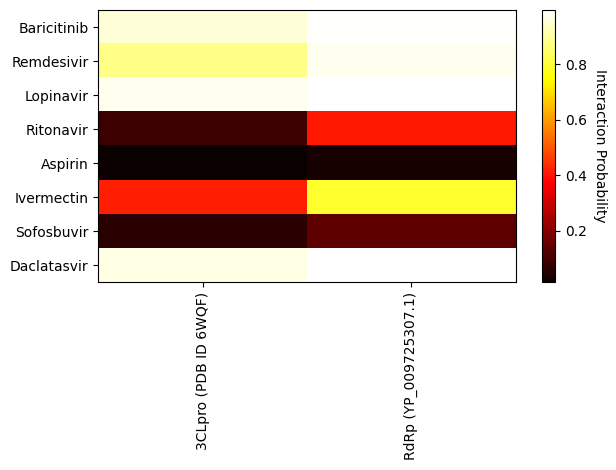

In [171]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
import matplotlib as mpl


vegetables = list(drugs_.keys())
farmers = list(proteins_.keys())

harvest = np.array(plot_vals)


fig, ax = plt.subplots()
im = ax.imshow(harvest, cmap='hot', aspect='auto')

# Add the legend (color bar)
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Interaction Probability", rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(farmers)), labels=farmers,
              rotation=90, ha="center")
ax.set_yticks(range(len(vegetables)), labels=vegetables)

fig.tight_layout()
plt.show()

In [98]:
# next(iter(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='unseen', device=torch.device('cuda'))))

In [200]:
# next(iter(test_case__class.random_batch_data_stream(batchSize=256, type='train', sampleType='CEL', device=torch.device('cuda'))))

In [204]:
model.calculate_y_prob_by_iterator(test_case__class.single_data_stream("CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@@H]1[C@H]([C@H]([C@](O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4", "MYSFVSEETGTLIVNSVLLFLAFVVFLLVTLAILTALRLCAYCCNIVNVSLVKPSFYVYSRVKNLNSSRVPDLLV", pSeqMaxLen=1024, dSeqMaxLen=128, device=torch.device('cuda')))

Presolving the data...
Tokenizing the data...


100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 9157.87it/s]

Other solving...


Predicting...


(array([0.02156755], dtype=float32), array([-1], dtype=int32))

In [202]:
# next(iter(test_case__class.single_data_stream("CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO", "MIELSLIDFYLCFLAFLLFLVLIMLIIFWFSLELQDHNETCHA", pSeqMaxLen=1024, dSeqMaxLen=128, device=torch.device('cuda'))))

Presolving the data...
Tokenizing the data...


100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 7913.78it/s]

Other solving...


Predicting...


({'res': True,
  'aminoSeq': tensor([[ 2,  7, 13,  ...,  1,  1,  1]], device='cuda:0'),
  'aminoCtr': tensor([[-0.3066, -0.9230,  1.1172,  ...,  1.1172,  1.1172,  1.1172]],
         device='cuda:0'),
  'pSeqLen': tensor([43], device='cuda:0', dtype=torch.int32),
  'atomFea': tensor([[[1., 0., 0.,  ..., 0., 1., 0.],
           [1., 0., 0.,  ..., 1., 0., 0.],
           [0., 1., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
  'atomFin': tensor([[0., 1., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
  'atomSeq': tensor([[2, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 4, 2, 2, 5, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
           1, 1, 

In [188]:
# # dataClass.pContFeat.shape[1]
# next(iter(test_case__class.random_batch_data_stream(batchSize=32, type='valid', sampleType='CEL', device=torch.device('cuda'))))

In [404]:
next(iter(test_case__class.mode_proteins__batch(batchSize=256, type='train', mode='unseen', device=torch.device('cuda'))))

({'res': True,
  'aminoSeq': tensor([[ 2,  5, 18,  ...,  1,  1,  1],
          [ 2,  5, 18,  ...,  1,  1,  1],
          [ 2, 16,  3,  ...,  1,  1,  1],
          ...,
          [ 2, 16,  3,  ...,  1,  1,  1],
          [ 2,  5, 18,  ...,  1,  1,  1],
          [ 2, 16,  3,  ...,  1,  1,  1]], device='cuda:0'),
  'aminoCtr': tensor([[-1.4333, -0.9941, -0.2053,  ..., -0.2053, -0.2101, -0.2053],
          [-1.4333, -0.9941, -0.2053,  ..., -0.2053, -0.2101, -0.2053],
          [ 1.7372,  1.7438,  2.3805,  ...,  2.3805, -0.9856,  2.3805],
          ...,
          [ 1.7372,  1.7438,  2.3805,  ...,  2.3805, -0.9856,  2.3805],
          [-1.4333, -0.9941, -0.2053,  ..., -0.2053, -0.2101, -0.2053],
          [ 1.7372,  1.7438,  2.3805,  ...,  2.3805, -0.9856,  2.3805]],
         device='cuda:0'),
  'pSeqLen': tensor([ 61,  61, 419,  61, 121, 275, 275,  61,  61, 121,  75, 121,  61, 121,
           61, 121, 419, 121, 121,  61,  75,  75,  61,  75, 121, 121, 121,  75,
           43, 121, 275,  75,

In [189]:
Ypre,Y = model.calculate_y_prob_by_iterator(test_case__class.mode_proteins__batch(batchSize=256, type='train', mode='unseen', device=torch.device('cuda')))

aminoSeq: [5, 5, 3, 5, 6, 3, 5, 1, 6, 5, 5, 5, 3, 3, 3, 5, 3, 5, 1, 3, 3, 6, 0, 3, 0, 0, 2, 4, 6, 6, 5, 3, 6, 6, 0, 2, 1, 1, 1, 3, 3, 5, 4, 0, 5, 0, 5, 2, 4, 3, 3, 4, 0, 2, 2, 5, 5, 3, 3, 5, 2, 3, 3, 6, 5, 0, 3]
atomSeq: [11, 7, 7, 7, 11, 0, 3, 1, 11, 3, 11, 3, 0, 0, 0, 9, 0, 9, 10, 1, 1, 11, 7, 1, 1, 3, 7, 10, 10, 1, 9, 6, 1, 10, 7, 1, 10, 10, 10, 5, 11, 5, 2, 7, 1, 3, 10, 10, 7, 9, 11, 2, 9, 0, 10, 7, 6, 7, 9, 4, 4, 6, 8, 1, 11, 11, 7]


In [190]:
Ypre

array([0.00332006, 0.00383519, 0.00183134, 0.00383519, 0.11413022,
       0.00240836, 0.03897641, 0.00198847, 0.11413022, 0.03897641,
       0.00332006, 0.03897641, 0.00240836, 0.00240836, 0.00240836,
       0.04994581, 0.00240836, 0.04994581, 0.00181939, 0.0019229 ,
       0.0019229 , 0.11413022, 0.12681916, 0.0019229 , 0.06140993,
       0.9220687 , 0.00248299, 0.00191573, 0.04032464, 0.08308882,
       0.04994581, 0.00161146, 0.08308882, 0.04032464, 0.12681916,
       0.0019575 , 0.00181939, 0.00181939, 0.00181939, 0.00122182,
       0.00190259, 0.0017727 , 0.02174421, 0.12681916, 0.00248709,
       0.9220687 , 0.0021973 , 0.00177025, 0.00287458, 0.03163063,
       0.00190259, 0.02174421, 0.92315614, 0.00349219, 0.00177025,
       0.00383519, 0.00262539, 0.00183134, 0.03163063, 0.00301669,
       0.0021711 , 0.00161146, 0.00138675, 0.08308882, 0.00332006,
       0.10710413, 0.00183134], dtype=float32)

In [ ]:
model.to_eval_mode()
# Ypre,Y = model.calculate_y_prob_by_iterator(dataClass.one_epoch_batch_data_stream(batchSize=256, type='test', device=torch.device('cuda')))

print("Test")
print("seen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='seen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("unseen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='test', mode='unseen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("Valid")
print("seen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='valid', mode='seen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

print("unseen")
Ypre,Y = quantum__post_classical__model.calculate_y_prob_by_iterator(dataClass.mode_proteins__batch(batchSize=256, type='valid', mode='unseen', device=torch.device('cuda')))
print("ACC:", ACC(Ypre>0.5, Y))
print("AUC:", AUC(Ypre, Y))
print("LOSS:", LOSS(Ypre, Y))

In [90]:
# len(dataClass.d2id.keys())
# dataClass.pSeqData[0]
len(dataClass.pContFeat[0]), len(dataClass.pContFeat)

(8422, 842)

In [91]:
# test_case__class.pSeqData[0]
len(test_case__class.pContFeat[0]), len(test_case__class.pContFeat)

(1317, 7)

In [456]:
len(test_case__class.feature_names)

1317

In [459]:
len(dataClass.pSeqData[0]), len(dataClass.pSeqData)

(577, 842)

In [460]:
len(test_case__class.pSeqData[0]), len(test_case__class.pSeqData)

(275, 7)

In [95]:
dataClass_t = dataClass.ctr_p.fit_transform([''.join(i) for i in dataClass.pSeqData]).toarray().astype('float32')

In [96]:
test_case__class_t = test_case__class.ctr_p.fit_transform([''.join(i) for i in test_case__class.pSeqData]).toarray().astype('float32')

In [97]:
len(dataClass_t[0]), len(dataClass_t)

(8422, 842)

In [98]:
len(test_case__class_t[0]), len(test_case__class_t)

(1317, 7)

In [170]:
# print(f"Training Features: {dataClass.pContFeat.shape[1]}")
# print(f"Case Study Features: {test_case__class.pContFeat.shape[1]}")

# if dataClass.pContFeat.shape[1] == test_case__class.pContFeat.shape[1]:
#     print("✅ Dimensions aligned! Matrix multiplication will work.")
# else:
#     print("❌ DANGER: Dimensions are still different.")

dataClass.ctr_p.vocabulary_

{'m': 4212,
 'a': 0,
 'l': 3791,
 'r': 5895,
 'v': 7160,
 'd': 843,
 'f': 1685,
 'g': 2106,
 'k': 3370,
 'p': 5053,
 'w': 7581,
 'q': 5474,
 's': 6316,
 'e': 1264,
 'n': 4632,
 'y': 8002,
 'h': 2528,
 'i': 2949,
 't': 6737,
 'c': 421,
 'ma': 4213,
 'al': 190,
 'lr': 4086,
 'rl': 6085,
 'lv': 4149,
 'va': 7161,
 'ad': 43,
 'df': 928,
 'fd': 1728,
 'dl': 1033,
 'lg': 3897,
 'gk': 2276,
 'kd': 3413,
 'dv': 1201,
 'vl': 7350,
 'lp': 4044,
 'pw': 5432,
 'wl': 7771,
 'ra': 5896,
 'aq': 274,
 'qr': 5769,
 'av': 358,
 'vs': 7476,
 'se': 6380,
 'ea': 1265,
 'as': 316,
 'sg': 6422,
 'ga': 2107,
 'ag': 106,
 'gs': 2423,
 'gg': 2213,
 'le': 3855,
 'en': 1496,
 'nd': 4675,
 'dy': 1243,
 'ye': 8066,
 'es': 1580,
 'sl': 6506,
 'lh': 3918,
 'hv': 2886,
 'ln': 4023,
 'nv': 4990,
 've': 7224,
 'er': 1559,
 'rn': 6127,
 'ng': 4738,
 'gn': 2339,
 'ni': 4780,
 'ii': 3097,
 'iy': 3349,
 'yt': 8338,
 'ty': 7137,
 'yk': 8171,
 'dd': 886,
 'dk': 1012,
 'kg': 3476,
 'vv': 7518,
 'vf': 7245,
 'fg': 1791,
 'gl': 

# ZX diagrams

In [233]:
from fractions import Fraction
import pyzx as zx

vqc_weights = np.random.randn(3, 6, 12, 3)
inputs = np.random.randn(24)
n_qubits = 12
switch = n_qubits - 1
mixing_weights = None

In [242]:
def tensocircuit_to_zx(n_qubits, switch, inputs, vqc_weights, mixing_weights=None):
    """
    Convert TensoCircuit quantum circuit to ZX diagram.
    
    Parameters:
    - n_qubits: Total number of qubits
    - switch: Index of control/switch qubit
    - inputs: Input angles array
    - vqc_weights: VQC layer weights [blocks, layers, qubits, 3]
    - mixing_weights: Optional mixing weights [blocks-1, 3]
    
    Returns:
    - PyZX Circuit object
    """
    
    # Create PyZX circuit
    circuit = zx.Circuit(n_qubits)
    
    num_vqc_blocks = vqc_weights.shape[0]
    num_layers = vqc_weights.shape[1]
    
    # 1. Hadamard on switch qubit
    circuit.add_gate("HAD", switch)
    
    # 2. Angular Embedding with Control Logic
    for i in range(switch):
        # Controlled-RY when switch is |1⟩ (Drug-Protein Context)
        angle = inputs[i]
        circuit.add_gate("CRY", switch, i, phase=Fraction(angle).limit_denominator(1000))
        
        # Controlled-RY when switch is |0⟩ (flip control)
        # X - CRY - X pattern
        circuit.add_gate("NOT", switch)
        angle = inputs[i + switch]
        circuit.add_gate("CRY", switch, i, phase=Fraction(angle).limit_denominator(1000))
        circuit.add_gate("NOT", switch)
    
    # 3. VQC Blocks (Strongly Entangling Layers)
    for b in range(num_vqc_blocks):
        # Apply mixing rotation on switch qubit (if b > 0)
        if b > 0 and mixing_weights is not None:
            theta = mixing_weights[b-1, 0]
            alpha = mixing_weights[b-1, 1]
            phi = mixing_weights[b-1, 2]
            
            # R gate decomposition: ZPhase(alpha) - YPhase(theta) - ZPhase(phi)
            circuit.add_gate("ZPhase", switch, phase=Fraction(alpha).limit_denominator(1000))
            circuit.add_gate("YPhase", switch, phase=Fraction(theta).limit_denominator(1000))
            circuit.add_gate("ZPhase", switch, phase=Fraction(phi).limit_denominator(1000))
        
        # Strongly Entangling Layers
        for l in range(num_layers):
            # Rotation gates on each qubit
            for i in range(switch):
                theta = vqc_weights[b, l, i, 0]
                alpha = vqc_weights[b, l, i, 1]
                phi = vqc_weights[b, l, i, 2]
                
                # R gate: ZPhase(alpha) - YPhase(theta) - ZPhase(phi)
                circuit.add_gate("ZPhase", i, phase=Fraction(alpha).limit_denominator(1000))
                circuit.add_gate("YPhase", i, phase=Fraction(theta).limit_denominator(1000))
                circuit.add_gate("ZPhase", i, phase=Fraction(phi).limit_denominator(1000))
            
            # Circular CNOT entanglement
            for i in range(switch):
                target = (i + 1) % switch
                circuit.add_gate("CNOT", i, target)
    
    return circuit

In [243]:
def visualize_zx_diagram(circuit, simplify=False):
    """
    Visualize the ZX diagram from PyZX circuit.
    
    Parameters:
    - circuit: PyZX Circuit object
    - simplify: Whether to apply ZX calculus simplification
    
    Returns:
    - ZX graph
    """
    # Convert circuit to ZX graph
    graph = circuit.to_graph()
    
    if simplify:
        # Apply ZX calculus simplification rules
        zx.simplify.full_reduce(graph)
    
    return graph

In [276]:
zx_circuit = tensocircuit_to_zx(n_qubits, switch, inputs, vqc_weights, mixing_weights)

# Get ZX graph
zx_graph = visualize_zx_diagram(zx_circuit, simplify=False)

In [277]:
# Draw the diagram (requires matplotlib)
print("Circuit converted to ZX diagram successfully!")
print(f"Number of qubits: {zx_graph.qubit_count()}")
print(f"Number of vertices: {zx_graph.num_vertices()}")
print(f"Number of edges: {zx_graph.num_edges()}")

# To visualize (uncomment if you have display):
# zx.draw(zx_graph)

# Export to various formats
print("\nYou can visualize/export using:")
print("- zx.draw(zx_graph)  # Interactive plot")
print("- zx.draw_matplotlib(zx_graph)  # Matplotlib figure")
print("- circuit.to_qasm()  # Export to QASM")
print("- zx_graph.to_json()  # Export to JSON")

Circuit converted to ZX diagram successfully!
Number of qubits: 12
Number of vertices: 1653
Number of edges: 1883

You can visualize/export using:
- zx.draw(zx_graph)  # Interactive plot
- zx.draw_matplotlib(zx_graph)  # Matplotlib figure
- circuit.to_qasm()  # Export to QASM
- zx_graph.to_json()  # Export to JSON


In [288]:
import pyzx as zx

# zx.draw_matplotlib(zx_graph)
zx.draw(zx_circuit)

# # # plt.ion()  # Enable interactive mode
# # # plt.figure(figsize=(14, 10))
# # # zx.draw_matplotlib(zx_graph, labels=True)
# # # plt.title("ZX Diagram of TensoCircuit", fontsize=14, fontweight='bold', pad=20)
# # # plt.tight_layout()
# # # plt.show(block=True)

# # zx_graph.to_json()

# plt.figure(figsize=(16, 12), dpi=150)
# zx.draw_matplotlib(zx_graph, labels=True)
# plt.title("ZX Diagram of TensoCircuit", fontsize=16, fontweight='bold', pad=20)
# plt.tight_layout()

# # Save to file
# output_file = "zx_diagram.png"
# plt.savefig(output_file, bbox_inches='tight', dpi=300)
# print(f"\n✓ ZX diagram saved to: {output_file}")
# plt.close()

In [274]:
# plt.figure(figsize=(30, 20))  # Very large figure
# zx.draw_matplotlib(zx_graph)

# # Save to file
# output_file = "zx_diagram_large.png"
# plt.savefig(output_file, bbox_inches='tight', dpi=300, facecolor='white')
# print(f"\n✓ ZX diagram saved to: {output_file}")
# plt.close()

In [296]:
print(zx_circuit)

Circuit(12 qubits, 0 bits, 837 gates)


In [299]:
# zx_circuit.to_qasm()

In [298]:
# Source - https://stackoverflow.com/a
# Posted by John La Rooy, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-24, License - CC BY-SA 4.0

with open("circ1.qasm", "w") as text_file:
    text_file.write(zx_circuit.to_qasm())